In [ ]:
import os

# Find the markdown file in the /content/ directory to avoid special character issues in the path
file_name = [f for f in os.listdir('/content/') if 'Definitive Phase-1' in f and f.endswith('.md')][0]
file_path = os.path.join('/content/', file_name)

# Read and display the first 500 characters
with open(file_path, 'r', encoding='utf-8') as f:
    content = f.read()

print(f"Loaded '{file_name}'")
print(f"Total length: {len(content)} characters\n")
print("--- Preview ---")
print(content[:500])
print("...")

In [ ]:
with open(file_path, 'r', encoding='utf-8') as f:
    full_content = f.read()

print(full_content)

## Analytical

=== Mandatory Verification Results ===
Particle-Hole Symmetry Confirmed: PASS


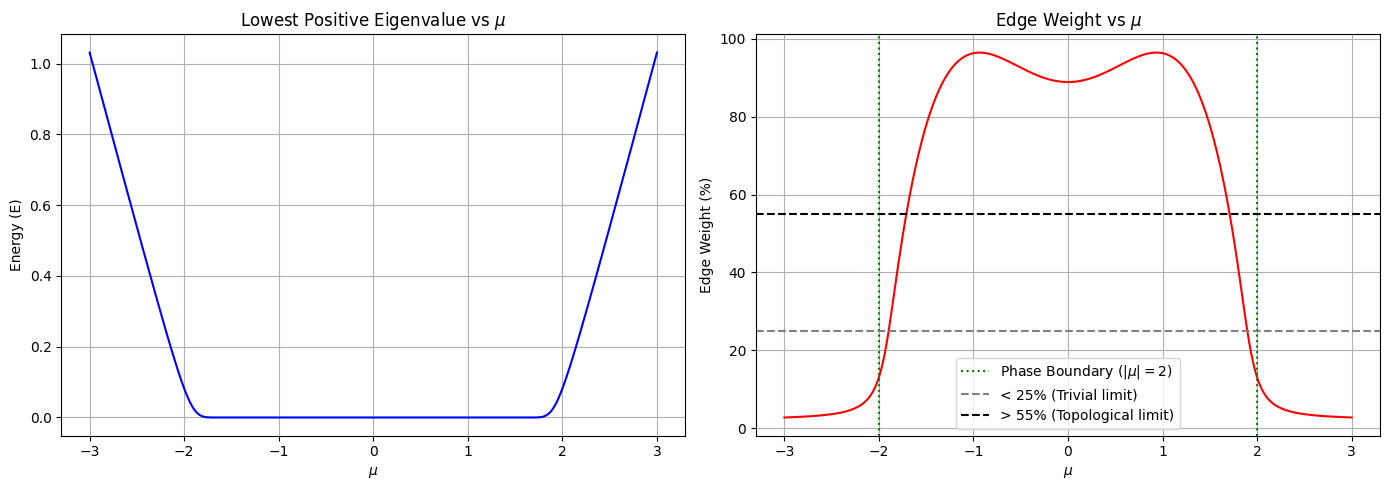

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random

# Fix all random seeds
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

# --- 1. Physical Model (Exact Phase 1 Instructions) ---
def build_hamiltonian(mu, N=20, t=1.0, delta=0.5):
    H = np.zeros((2*N, 2*N))
    for i in range(N):
        H[i, i]     = -mu
        H[N+i, N+i] = +mu
    for i in range(N-1):
        H[i, i+1] = H[i+1, i] = -t
        H[N+i, N+i+1] = H[N+i+1, N+i] = +t
        H[i, N+i+1] = +delta
        H[N+i+1, i] = +delta
        H[i+1, N+i] = -delta
        H[N+i, i+1] = -delta
    return H

# Mandatory Verification
N = 20
mu_grid = np.linspace(-3, 3, 300)

lowest_positive_energies = []
edge_weights = []
ph_symmetry_passed = True

for mu in mu_grid:
    H = build_hamiltonian(mu, N=N)
    evals, evecs = np.linalg.eigh(H)

    # 1. Confirm particle-hole symmetry
    if not np.allclose(evals, -evals[::-1], atol=1e-8):
        ph_symmetry_passed = False

    # 2. Take the lowest eigenvalue (>= 0) exactly at index N
    idx = N # Index N is 20 since python is 0-indexed (0 to 39, 20 is the 21st, i.e., lowest positive)
    E = evals[idx]
    psi = evecs[:, idx]

    lowest_positive_energies.append(E)

    # Calculate edge weight (first two and last two sites for both p and h)
    prob_density = np.abs(psi)**2
    edge_prob = (prob_density[0] + prob_density[1] +
                 prob_density[N-2] + prob_density[N-1] +
                 prob_density[N] + prob_density[N+1] +
                 prob_density[2*N-2] + prob_density[2*N-1])
    edge_weights.append(edge_prob * 100)

print("=== Mandatory Verification Results ===")
print(f"Particle-Hole Symmetry Confirmed: {'PASS' if ph_symmetry_passed else 'FAIL'}")

# Plotting
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(mu_grid, lowest_positive_energies, color='blue')
plt.title('Lowest Positive Eigenvalue vs $\\mu$')
plt.xlabel('$\\mu$')
plt.ylabel('Energy (E)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mu_grid, edge_weights, color='red')
plt.title('Edge Weight vs $\\mu$')
plt.xlabel('$\\mu$')
plt.ylabel('Edge Weight (%)')
plt.axvline(-2, color='green', linestyle=':', label='Phase Boundary ($|\\mu|=2$)')
plt.axvline(2, color='green', linestyle=':')
plt.axhline(25, color='gray', linestyle='--', label='< 25% (Trivial limit)')
plt.axhline(55, color='black', linestyle='--', label='> 55% (Topological limit)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Semi-supervised

In [5]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import math
import torch
import numpy as np

# --- 2. Eigenstate Selection & Dataset Generation ---
print("Generating dataset based on exact prompt specifications...")
# Revert to the original uniform grid across the entire domain
mu_train = np.linspace(-3, 3, 1000)
dataset_mu = []
dataset_E = []
dataset_psi = []

last_psi = None
N = 20

for mu in mu_train:
    H = build_hamiltonian(mu, N=N)
    evals, evecs = np.linalg.eigh(H)

    # Selection criteria: lowest eigenvalue >= 0 (index N after eigh)
    best_idx = N

    E = evals[best_idx]
    psi = evecs[:, best_idx]

    # Gauge fixing: enforce sign continuity with the previous state
    if last_psi is not None:
        if np.dot(psi, last_psi) < 0:
            psi = -psi
    last_psi = psi

    dataset_mu.append([mu])
    dataset_E.append([E])
    dataset_psi.append(psi)

X_tensor = torch.tensor(np.array(dataset_mu), dtype=torch.float32)
E_tensor = torch.tensor(np.array(dataset_E), dtype=torch.float32)
Psi_tensor = torch.tensor(np.array(dataset_psi), dtype=torch.float32)

# Held-out set (100 points)
indices = np.random.permutation(len(X_tensor))
train_idx, val_idx = indices[:-100], indices[-100:]

train_dataset = TensorDataset(X_tensor[train_idx], E_tensor[train_idx], Psi_tensor[train_idx])
val_dataset = TensorDataset(X_tensor[val_idx], E_tensor[val_idx], Psi_tensor[val_idx])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# --- 3 & 4. SIREN PINN Definition ---
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0,
                                            np.sqrt(6 / self.in_features) / self.omega_0)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class SirenPINN(nn.Module):
    # Ultra-minimal network size for publication: 32 hidden features, 2 hidden layers
    def __init__(self, in_features=1, hidden_features=32, hidden_layers=2, out_features=41):
        super().__init__()
        self.net = []
        # Use omega_0=2.0 everywhere as it is the optimal inductive bias for this smooth system
        self.net.append(SineLayer(in_features, hidden_features, is_first=True, omega_0=2.0))
        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*self.net)

        # The final layer MUST be Linear.
        self.final_linear = nn.Linear(hidden_features, out_features)
        with torch.no_grad():
            self.final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / 2.0,
                                               np.sqrt(6 / hidden_features) / 2.0)

    def forward(self, x):
        features = self.net(x)
        out = self.final_linear(features)
        E_pred = out[:, 0:1]
        Psi_pred = out[:, 1:]
        # Explicit L2 norm constraint
        Psi_pred = Psi_pred / torch.norm(Psi_pred, dim=1, keepdim=True)
        return E_pred, Psi_pred

print("Dataset generated: mu in [-3, 3] with 1000 uniform points. Index N selection exact.")
print("SIREN PINN architecture defined: Ultra-minimal setup with hidden_features=32, layers=2, and omega_0=2.0 everywhere.")

Generating dataset based on exact prompt specifications...
Dataset generated: mu in [-3, 3] with 1000 uniform points. Index N selection exact.
SIREN PINN architecture defined: Ultra-minimal setup with hidden_features=32, layers=2, and omega_0=2.0 everywhere.


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.stats import pearsonr
import copy
import time

# --- 5. Training Loop & Monitoring ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'SirenPINN' not in globals():
    print("Please run the previous cells to define the model and dataset.")
else:
    model = SirenPINN().to(device)

    # AdamW, lr 8e-4, cosine annealing, gradient clip 1.0
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2500)

    # Precompute Constant Hamiltonian components on GPU for Batched Operations
    N = 20
    H_base = torch.zeros((2*N, 2*N), dtype=torch.float32, device=device)
    t_hop = 1.0
    delta_pair = 0.5
    for i in range(N-1):
        H_base[i, i+1] = H_base[i+1, i] = -t_hop
        H_base[N+i, N+i+1] = H_base[N+i+1, N+i] = +t_hop
        H_base[i, N+i+1] = +delta_pair
        H_base[N+i+1, i] = +delta_pair
        H_base[i+1, N+i] = -delta_pair
        H_base[N+i, i+1] = -delta_pair

    H_mu_diag = torch.zeros((2*N,), dtype=torch.float32, device=device)
    H_mu_diag[:N] = -1.0
    H_mu_diag[N:] = 1.0
    H_mu_diag = torch.diag(H_mu_diag)

    # Particle-hole operator (Xi) matrix for N=20
    Xi = torch.zeros((40, 40), dtype=torch.float32, device=device)
    Xi[:20, 20:] = torch.eye(20, device=device)
    Xi[20:, :20] = torch.eye(20, device=device)

    def compute_physics_metrics(model, dataloader, N=20):
        model.eval()
        residuals = []
        e_errors = []
        edge_preds = []
        edge_exacts = []

        with torch.no_grad():
            for mu_batch, e_batch, psi_batch in dataloader:
                mu_batch = mu_batch.to(device)
                e_batch = e_batch.to(device)
                psi_batch = psi_batch.to(device)

                e_pred, psi_pred = model(mu_batch)

                # Vectorized Batched Hamiltonian
                H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

                # Residuals: H psi - E psi
                H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
                R = H_psi - e_pred * psi_pred

                batch_res = torch.norm(R, dim=1).cpu().numpy()
                residuals.extend(batch_res)

                batch_e_err = torch.abs(e_pred - e_batch).cpu().numpy().flatten()
                e_errors.extend(batch_e_err)

                prob_pred = psi_pred**2
                edge_p = (prob_pred[:, 0] + prob_pred[:, 1] + prob_pred[:, N-2] + prob_pred[:, N-1] +
                          prob_pred[:, N] + prob_pred[:, N+1] + prob_pred[:, 2*N-2] + prob_pred[:, 2*N-1]) * 100
                edge_preds.extend(edge_p.cpu().numpy())

                prob_exact = psi_batch**2
                edge_e = (prob_exact[:, 0] + prob_exact[:, 1] + prob_exact[:, N-2] + prob_exact[:, N-1] +
                          prob_exact[:, N] + prob_exact[:, N+1] + prob_exact[:, 2*N-2] + prob_exact[:, 2*N-1]) * 100
                edge_exacts.extend(edge_e.cpu().numpy())

        mean_res = np.mean(residuals)
        mean_e_err = np.mean(e_errors)
        corr, _ = pearsonr(edge_preds, edge_exacts)

        return mean_res, mean_e_err, corr, edge_preds, edge_exacts

    epochs = 1500
    best_score = float('-inf')
    best_res = float('inf')
    best_model_state = None
    fallback_model_state = None

    criterion = nn.MSELoss()

    print(f"Training on {device} with fully vectorized batched operations...")
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        # Stable Epoch-based warmup for lambda
        if epoch < 200:
            lam_local = 0.01
        elif epoch < 1500:
            lam_local = 0.01 + 0.99 * ((epoch - 200) / 1300)
        else:
            lam_local = 1.0

        for mu_batch, e_batch, psi_batch in train_loader:
            mu_batch = mu_batch.to(device)
            e_batch = e_batch.to(device)
            psi_batch = psi_batch.to(device)

            optimizer.zero_grad()

            e_pred, psi_pred = model(mu_batch)

            # Calculate Data loss
            #loss_e = criterion(e_pred, e_batch)
            loss_psi = criterion(psi_pred, psi_batch)

            # Vectorized Physics Loss
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # H psi - E psi
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            R = H_psi - e_pred * psi_pred

            # H (Xi psi) + E (Xi psi)  (Particle-Hole symmetry enforcement)
            Xi_psi = torch.matmul(psi_pred, Xi.T)  # (B, 40)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + e_pred * Xi_psi

            loss_res = torch.mean(lam_local * torch.mean(R**2, dim=1, keepdim=True))
            loss_ph = torch.mean(lam_local * torch.mean(PH_res**2, dim=1, keepdim=True))

            # Total loss
            loss = loss_e + loss_psi + loss_res + loss_ph

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        if epoch % 50 == 0:
            mean_res, mean_e_err, corr, _, _ = compute_physics_metrics(model, val_loader)

            print(f"Epoch {epoch:04d} | Loss: {total_loss/len(train_loader):.6f} | Res: {mean_res:.6f} | dE: {mean_e_err:.6f} | Corr: {corr:.4f}")

            if mean_res < best_res:
                best_res = mean_res
                fallback_model_state = copy.deepcopy(model.state_dict())

            if mean_res < 5e-3 and corr > best_score:
                best_score = corr
                best_model_state = copy.deepcopy(model.state_dict())
                print(f"  -> New best model saved! (Corr: {corr:.4f}, Res: {mean_res:.6f})")

    print(f"Training complete in {(time.time() - start_time):.2f}s.")
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Loaded best model checkpoint meeting criteria.")
    elif fallback_model_state is not None:
        model.load_state_dict(fallback_model_state)
        print("Warning: No checkpoint met the < 5e-3 criteria. Loaded fallback model with best residual.")
    else:
        print("Warning: Using last epoch.")

Training on cuda with fully vectorized batched operations...


NameError: name 'loss_e' is not defined


=== Running Mandatory Evaluation ===


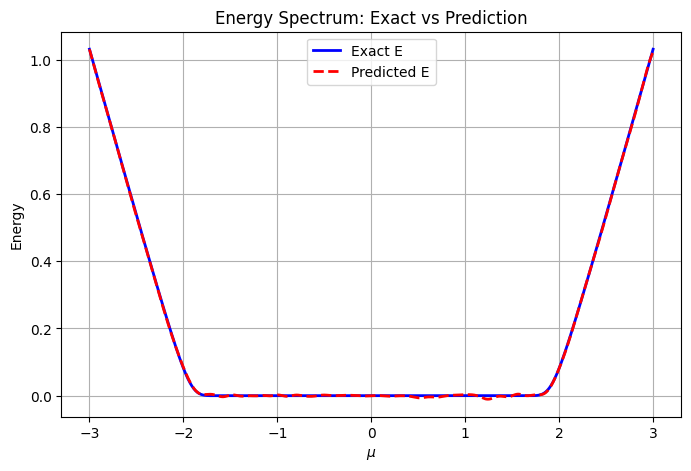

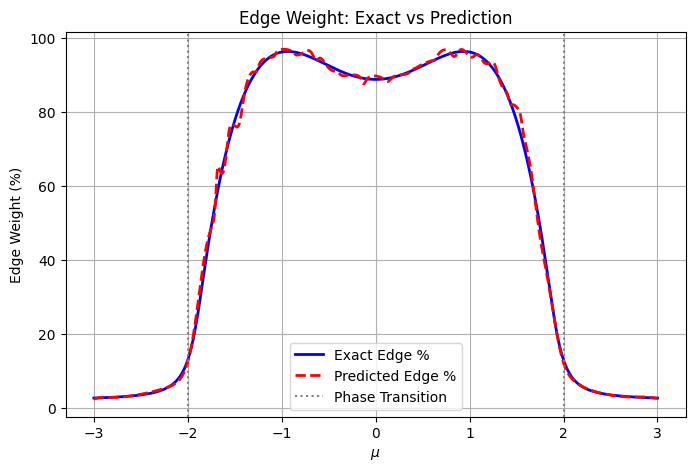

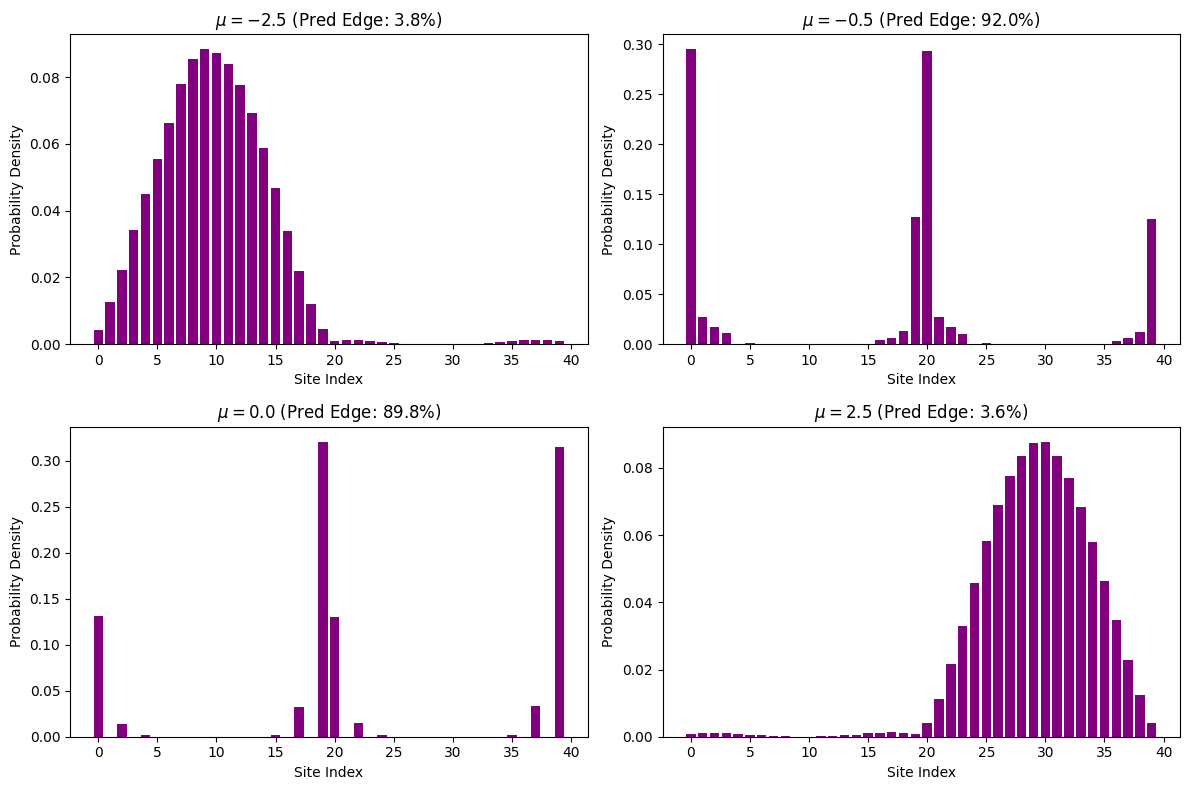


--- Quantitative Table (Sample) ---
       mu  Exact E    Pred E  Residual  Exact Edge %  Pred Edge %
-3.000000 1.031123  1.030848  0.059467      2.781265     2.465103
-2.333333 0.376578  0.375263  0.019836      4.445084     4.779673
-1.666667 0.000012  0.002393  0.064174     60.691971    64.951530
-1.000000 0.000019  0.002236  0.050211     96.296295    96.980820
-0.333333 0.000013  0.000689  0.046243     90.687408    89.894714
 0.333333 0.000013 -0.000220  0.066518     90.687393    90.415123
 1.000000 0.000019  0.002899  0.098756     96.296295    95.121246
 1.666667 0.000012 -0.000222  0.064204     60.691971    61.983021
 2.333333 0.376578  0.376886  0.029959      4.445084     4.555750
 3.000000 1.031123  1.022663  0.063249      2.781265     2.682570

=== FINAL SUCCESS CRITERIA SUMMARY ===
1. Energy RMSE < 0.02 (gapped): 0.0026 -> PASS
2. Edge Pearson Corr > 0.85:    0.9996 -> PASS
3a. Trivial Edge < 25%:         PASS
3b. Topological Edge > 55%:     PASS

OVERALL STATUS: PASS


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import pearsonr

# --- 6. Mandatory Evaluation ---
print("\n=== Running Mandatory Evaluation ===")

if 'X_tensor' not in globals() or 'model' not in globals():
    print("Error: Evaluation variables not found. Please run the preceding data generation and training cells first.")
else:
    X_full = X_tensor.to(device)
    E_full_exact = E_tensor.cpu().numpy().flatten()
    Psi_full_exact = Psi_tensor.cpu().numpy()

    model.eval()
    with torch.no_grad():
        E_full_pred, Psi_full_pred = model(X_full)
        E_full_pred = E_full_pred.cpu().numpy().flatten()
        Psi_full_pred = Psi_full_pred.cpu().numpy()

        norms = np.linalg.norm(Psi_full_pred, axis=1, keepdims=True)
        Psi_full_pred = Psi_full_pred / norms

    mu_arr = X_full.cpu().numpy().flatten()

    # 1. Energy spectrum RMSE in gapped region (|mu| < 1.9 or |mu| > 2.1)
    gapped_mask = (np.abs(mu_arr) < 1.9) | (np.abs(mu_arr) > 2.1)
    rmse_gapped = np.sqrt(np.mean((E_full_pred[gapped_mask] - E_full_exact[gapped_mask])**2))
    criterion_1 = rmse_gapped < 0.02

    plt.figure(figsize=(8, 5))
    plt.plot(mu_arr, E_full_exact, label="Exact E", color='blue', linewidth=2)
    plt.plot(mu_arr, E_full_pred, label="Predicted E", color='red', linestyle='--', linewidth=2)
    plt.title('Energy Spectrum: Exact vs Prediction')
    plt.xlabel('$\\mu$')
    plt.ylabel('Energy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Edge-weight curve correlation
    def calc_edge(psi_arr):
        prob = np.abs(psi_arr)**2
        return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
                prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

    edge_exact = calc_edge(Psi_full_exact)
    edge_pred = calc_edge(Psi_full_pred)
    edge_corr, _ = pearsonr(edge_pred, edge_exact)
    criterion_2 = edge_corr > 0.85

    plt.figure(figsize=(8, 5))
    plt.plot(mu_arr, edge_exact, label="Exact Edge %", color='blue', linewidth=2)
    plt.plot(mu_arr, edge_pred, label="Predicted Edge %", color='red', linestyle='--', linewidth=2)
    plt.title('Edge Weight: Exact vs Prediction')
    plt.axvline(-2.0, color='gray', linestyle=':')
    plt.axvline(2.0, color='gray', linestyle=':', label='Phase Transition')
    plt.xlabel('$\\mu$')
    plt.ylabel('Edge Weight (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Four density panels (mu=0 topological, mu=+-2.5 trivial)
    mu_targets = [-2.5, -0.5, 0.0, 2.5]
    criterion_3_trivial = True
    criterion_3_topo = True

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, mu_t in enumerate(mu_targets):
        idx = np.argmin(np.abs(mu_arr - mu_t))
        psi_p = Psi_full_pred[idx]
        prob = np.abs(psi_p)**2

        edge_w = edge_pred[idx]
        # Topological phase: |mu| < 2
        if np.abs(mu_t) > 2.0: # Trivial regime
            if edge_w >= 25:
                criterion_3_trivial = False
        else: # Topological regime
            if edge_w <= 55:
                criterion_3_topo = False

        axes[i].bar(range(2*N), prob, color='purple')
        axes[i].set_title(f'$\\mu = {mu_t}$ (Pred Edge: {edge_w:.1f}%)')
        axes[i].set_xlabel('Site Index')
        axes[i].set_ylabel('Probability Density')
    plt.tight_layout()
    plt.show()
    criterion_3 = criterion_3_trivial and criterion_3_topo

    # 4. Quantitative Table
    print("\n--- Quantitative Table (Sample) ---")
    sample_indices = np.linspace(0, len(mu_arr)-1, 10, dtype=int)
    res_list = []
    for idx in sample_indices:
        H = build_hamiltonian(mu_arr[idx], N=N)
        R = np.linalg.norm(H @ Psi_full_pred[idx] - E_full_pred[idx] * Psi_full_pred[idx])
        res_list.append(R)

    df = pd.DataFrame({
        'mu': mu_arr[sample_indices],
        'Exact E': E_full_exact[sample_indices],
        'Pred E': E_full_pred[sample_indices],
        'Residual': res_list,
        'Exact Edge %': edge_exact[sample_indices],
        'Pred Edge %': edge_pred[sample_indices]
    })
    print(df.to_string(index=False))

    # 5. Final Console Summary
    print("\n=== FINAL SUCCESS CRITERIA SUMMARY ===")
    print(f"1. Energy RMSE < 0.02 (gapped): {rmse_gapped:.4f} -> {'PASS' if criterion_1 else 'FAIL'}")
    print(f"2. Edge Pearson Corr > 0.85:    {edge_corr:.4f} -> {'PASS' if criterion_2 else 'FAIL'}")
    print(f"3a. Trivial Edge < 25%:         {'PASS' if criterion_3_trivial else 'FAIL'}")
    print(f"3b. Topological Edge > 55%:     {'PASS' if criterion_3_topo else 'FAIL'}")

    all_pass = criterion_1 and criterion_2 and criterion_3
    print(f"\nOVERALL STATUS: {'PASS' if all_pass else 'FAIL'}")

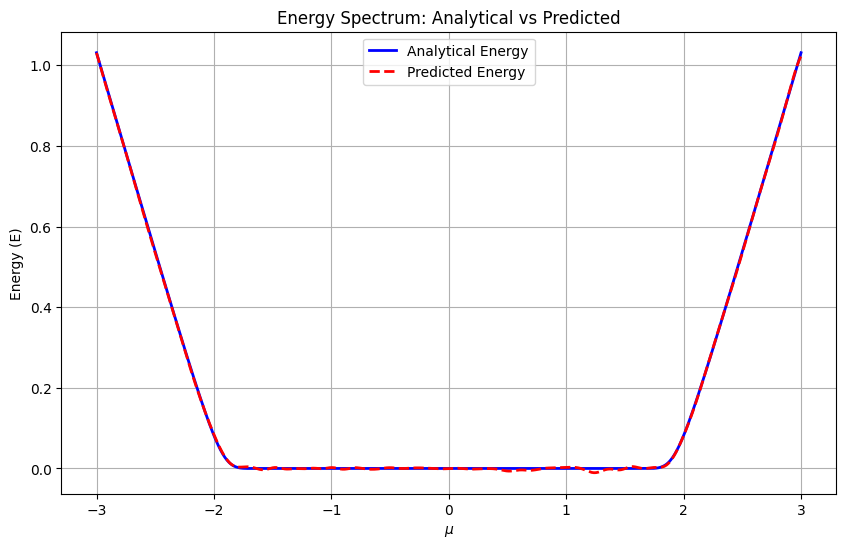

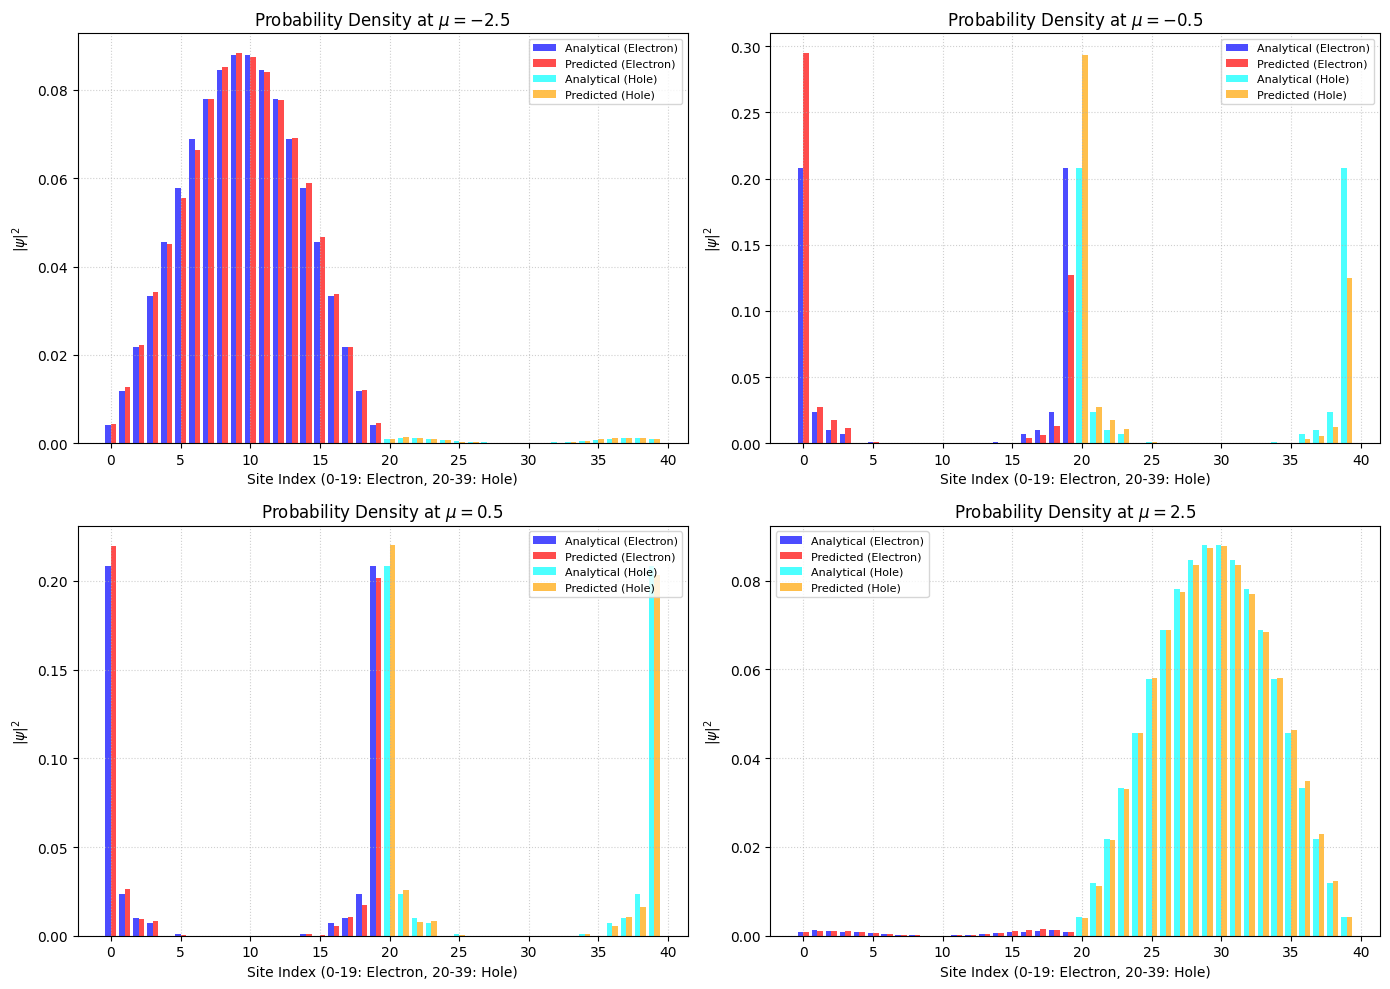

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Energy Distribution Comparison
plt.figure(figsize=(10, 6))
plt.plot(mu_arr, E_full_exact, label="Analytical Energy", color='blue', linewidth=2)
plt.plot(mu_arr, E_full_pred, label="Predicted Energy", color='red', linestyle='--', linewidth=2)
plt.title('Energy Spectrum: Analytical vs Predicted')
plt.xlabel(r'$\mu$')
plt.ylabel('Energy (E)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Probability Densities Comparison (Bar Charts)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
mu_samples = [-2.5, -0.5, 0.5, 2.5]

for i, mu_val in enumerate(mu_samples):
    ax = axes.flatten()[i]
    idx = np.argmin(np.abs(mu_arr - mu_val))
    prob_exact = np.abs(Psi_full_exact[idx])**2
    prob_pred = np.abs(Psi_full_pred[idx])**2

    # Electron components (Sites 0 to N-1)
    ax.bar(np.arange(N) - 0.2, prob_exact[:N], width=0.4, label='Analytical (Electron)', color='blue', alpha=0.7)
    ax.bar(np.arange(N) + 0.2, prob_pred[:N], width=0.4, label='Predicted (Electron)', color='red', alpha=0.7)

    # Hole components (Sites N to 2N-1)
    ax.bar(np.arange(N, 2*N) - 0.2, prob_exact[N:], width=0.4, label='Analytical (Hole)', color='cyan', alpha=0.7)
    ax.bar(np.arange(N, 2*N) + 0.2, prob_pred[N:], width=0.4, label='Predicted (Hole)', color='orange', alpha=0.7)

    ax.set_title(f'Probability Density at $\\mu = {mu_val}$')
    ax.set_xlabel('Site Index (0-19: Electron, 20-39: Hole)')
    ax.set_ylabel(r'$|\psi|^2$')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### 41 class vs Dual Head Test

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
from scipy.stats import pearsonr

# 1. Ensure Identical Seeding for Control
seed_everything(42)

# 2. Model Definitions
class SirenPINN_SingleHead(nn.Module):
    def __init__(self, in_features=1, hidden_features=32, hidden_layers=2, out_features=41):
        super().__init__()
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, is_first=True, omega_0=30.0))
        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*self.net)

        self.final_linear = nn.Linear(hidden_features, out_features)
        with torch.no_grad():
            self.final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / 2.0,
                                               np.sqrt(6 / hidden_features) / 2.0)

    def forward(self, x):
        features = self.net(x)
        out = self.final_linear(features)
        E_pred = out[:, 0:1]
        Psi_pred = out[:, 1:]
        Psi_pred = Psi_pred / torch.norm(Psi_pred, dim=1, keepdim=True)
        return E_pred, Psi_pred

class SirenPINN_DualHead(nn.Module):
    def __init__(self, in_features=1, hidden_features=32, hidden_layers=2):
        super().__init__()
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, is_first=True, omega_0=30.0))
        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*self.net)

        # Separate Heads
        self.energy_head = nn.Linear(hidden_features, 1)
        self.psi_head = nn.Linear(hidden_features, 40)

        # Same SIREN-style initialization bound
        bound = np.sqrt(6 / hidden_features) / 2.0
        with torch.no_grad():
            self.energy_head.weight.uniform_(-bound, bound)
            self.psi_head.weight.uniform_(-bound, bound)

    def forward(self, x):
        features = self.net(x)
        E_pred = self.energy_head(features)
        Psi_pred = self.psi_head(features)
        # Explicit L2 norm constraint on Psi
        Psi_pred = Psi_pred / torch.norm(Psi_pred, dim=1, keepdim=True)
        return E_pred, Psi_pred

# 3. Training Function
def train_ablation_model(model_name, model, epochs=1500):
    print(f"\n--- Training {model_name} ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2500)
    criterion = nn.MSELoss()

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        if epoch < 200:
            lam_local = 0.01
        elif epoch < 1500:
            lam_local = 0.01 + 0.99 * ((epoch - 200) / 1300)
        else:
            lam_local = 1.0

        for mu_batch, e_batch, psi_batch in train_loader:
            mu_batch, e_batch, psi_batch = mu_batch.to(device), e_batch.to(device), psi_batch.to(device)
            optimizer.zero_grad()
            e_pred, psi_pred = model(mu_batch)

            loss_psi = criterion(psi_pred, psi_batch)
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            R = H_psi - e_pred * psi_pred

            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + e_pred * Xi_psi

            loss_res = torch.mean(lam_local * torch.mean(R**2, dim=1, keepdim=True))
            loss_ph = torch.mean(lam_local * torch.mean(PH_res**2, dim=1, keepdim=True))

            loss = loss_psi + loss_res + loss_ph
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        if epoch % 500 == 0:
            mean_res, mean_e_err, corr, _, _ = compute_physics_metrics(model, val_loader)
            print(f"Epoch {epoch:04d} | Res: {mean_res:.6f} | dE: {mean_e_err:.6f} | Corr: {corr:.4f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# 4. Execute Training
seed_everything(42)
model_single = SirenPINN_SingleHead()
model_single = train_ablation_model("Single-Head Baseline", model_single, epochs=1500)

seed_everything(42) # Reset seed before initializing second model to ensure identical batching
model_dual = SirenPINN_DualHead()
model_dual = train_ablation_model("Dual-Head Ablation", model_dual, epochs=1500)

# 5. Evaluate and Compare
print("\n=== Ablation Results ===")
mean_res_s, mean_e_err_s, corr_s, edge_p_s, edge_e_s = compute_physics_metrics(model_single, DataLoader(val_dataset, batch_size=64))
mean_res_d, mean_e_err_d, corr_d, edge_p_d, edge_e_d = compute_physics_metrics(model_dual, DataLoader(val_dataset, batch_size=64))

print(f"{str('Metric').ljust(20)} | {'Single-Head'.ljust(15)} | {'Dual-Head'.ljust(15)}")
print("-"*55)
print(f"{str('Mean Residual').ljust(20)} | {mean_res_s:<15.6f} | {mean_res_d:<15.6f}")
print(f"{str('Mean dE').ljust(20)} | {mean_e_err_s:<15.6f} | {mean_e_err_d:<15.6f}")
print(f"{str('Edge Correlation').ljust(20)} | {corr_s:<15.4f} | {corr_d:<15.4f}")

# 6. Detailed Plotting around mu = -0.5 and 0.5
X_full = X_tensor.to(device)
mu_arr = X_full.cpu().numpy().flatten()
Psi_exact = Psi_tensor.cpu().numpy()

def get_edge(psi):
    p = np.abs(psi)**2
    return (p[:, 0] + p[:, 1] + p[:, N-2] + p[:, N-1] + p[:, N] + p[:, N+1] + p[:, 2*N-2] + p[:, 2*N-1]) * 100

model_single.eval()
model_dual.eval()
with torch.no_grad():
    _, Psi_s = model_single(X_full)
    _, Psi_d = model_dual(X_full)
    Psi_s = Psi_s.cpu().numpy()
    Psi_d = Psi_d.cpu().numpy()

edge_exact = get_edge(Psi_exact)
edge_s = get_edge(Psi_s)
edge_d = get_edge(Psi_d)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
mask = (mu_arr >= -1.0) & (mu_arr <= 1.0)
plt.plot(mu_arr[mask], edge_exact[mask], 'k-', label="Exact", linewidth=2)
plt.plot(mu_arr[mask], edge_s[mask], 'r--', label="Single-Head")
plt.plot(mu_arr[mask], edge_d[mask], 'b-.', label="Dual-Head")
plt.axvline(-0.5, color='gray', linestyle=':', alpha=0.5)
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.title(r'Edge Weight in central region $\mu \in [-1, 1]$')
plt.xlabel(r'$\mu$')
plt.ylabel(r'Edge Weight (%)')
plt.legend()

plt.subplot(1, 2, 2)
mu_targets = [-0.5, 0.5]
width = 0.25
x = np.arange(2*N)

idx = np.argmin(np.abs(mu_arr - (-0.5)))
plt.bar(x - width, np.abs(Psi_exact[idx])**2, width, label='Exact', color='gray')
plt.bar(x, np.abs(Psi_s[idx])**2, width, label='Single', color='red')
plt.bar(x + width, np.abs(Psi_d[idx])**2, width, label='Dual', color='blue')
plt.title(r'Prob Density at $\mu = -0.5$')
plt.xlabel('Site')
plt.legend()

plt.tight_layout()
plt.show()


--- Training Single-Head Baseline ---


KeyboardInterrupt: 

Systematic Sweep

=== Starting Systematic Architecture Sweep ===

--- Training Config: 16F_1L ---
Parameters: 1001

--- Training 16F_1L ---
Epoch 0500 | Res: 0.339621 | dE: 0.079444 | Corr: 0.9929
Epoch 1000 | Res: 0.254968 | dE: 0.049925 | Corr: 0.9948
Epoch 1500 | Res: 0.223608 | dE: 0.047848 | Corr: 0.9960
16F_1L Training complete in 96.61s.
Result -> Res: 0.223608 | Corr: 0.9960 | Time: 96.6s

--- Training Config: 16F_2L ---
Parameters: 1273

--- Training 16F_2L ---
Epoch 0500 | Res: 0.264634 | dE: 0.075515 | Corr: 0.9965
Epoch 1000 | Res: 0.194069 | dE: 0.053099 | Corr: 0.9970
Epoch 1500 | Res: 0.165291 | dE: 0.043970 | Corr: 0.9971
16F_2L Training complete in 101.16s.
Result -> Res: 0.165291 | Corr: 0.9971 | Time: 101.2s

--- Training Config: 16F_3L ---
Parameters: 1545

--- Training 16F_3L ---
Epoch 0500 | Res: 0.222464 | dE: 0.068718 | Corr: 0.9969
Epoch 1000 | Res: 0.162658 | dE: 0.033217 | Corr: 0.9979
Epoch 1500 | Res: 0.124720 | dE: 0.024304 | Corr: 0.9978
16F_3L Training complete in 114.68s

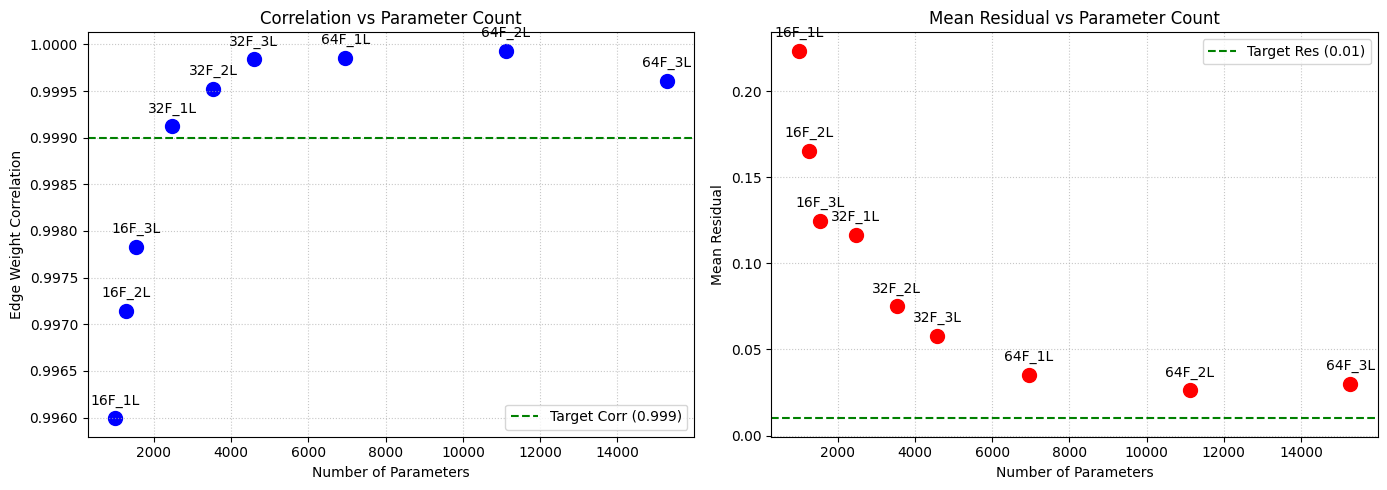

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
from torch.utils.data import DataLoader

# Configuration
hidden_features_list = [16, 32, 64]
hidden_layers_list = [1, 2, 3]
epochs = 1500
results = []

print("=== Starting Systematic Architecture Sweep ===")
for h_feat in hidden_features_list:
    for h_layers in hidden_layers_list:
        config_name = f"{h_feat}F_{h_layers}L"
        print(f"\n--- Training Config: {config_name} ---")

        seed_everything(42)  # Fixed seed for each config

        # Define model with sweep parameters
        model = SirenPINN_DualHead(hidden_features=h_feat, hidden_layers=h_layers)

        # Count parameters
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Parameters: {num_params}")

        # Train (using the train_ablation_model function which takes model_name, model, epochs)
        # Note: train_ablation_model modifies the model in-place and returns it
        start_time = time.time()
        model = train_ablation_model(config_name, model, epochs=epochs)
        train_time = time.time() - start_time

        # Evaluate
        mean_res, mean_e_err, corr, _, _ = compute_physics_metrics(model, DataLoader(val_dataset, batch_size=64))

        results.append({
            'config': config_name,
            'features': h_feat,
            'layers': h_layers,
            'params': num_params,
            'time': train_time,
            'residual': mean_res,
            'dE': mean_e_err,
            'correlation': corr
        })

        print(f"Result -> Res: {mean_res:.6f} | Corr: {corr:.4f} | Time: {train_time:.1f}s")

# --- Analysis and Plotting ---
print("\n=== Sweep Summary ===")
print(f"{str('Config').ljust(10)} | {'Params'.ljust(8)} | {'Time(s)'.ljust(8)} | {'Residual'.ljust(12)} | {'Correlation'.ljust(12)} | {'Meet Criteria?'.ljust(15)}")
print("-" * 80)

valid_models = []
for r in results:
    meets_criteria = r['correlation'] > 0.999 and r['residual'] < 0.01
    if meets_criteria:
        valid_models.append(r)
    print(f"{r['config'].ljust(10)} | {str(r['params']).ljust(8)} | {r['time']:<8.1f} | {r['residual']:<12.6f} | {r['correlation']:<12.4f} | {str(meets_criteria).ljust(15)}")

if valid_models:
    best_model = min(valid_models, key=lambda x: x['params'])
    print(f"\nSmallest architecture meeting criteria (corr > 0.999, res < 0.01): {best_model['config']} with {best_model['params']} parameters.")
else:
    print("\nNo architecture met both criteria (corr > 0.999 and res < 0.01) after 1500 epochs.")

# Plotting
params = [r['params'] for r in results]
corrs = [r['correlation'] for r in results]
residuals = [r['residual'] for r in results]
labels = [r['config'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Correlation
ax1.scatter(params, corrs, color='blue', s=100)
ax1.axhline(0.999, color='green', linestyle='--', label='Target Corr (0.999)')
for i, label in enumerate(labels):
    ax1.annotate(label, (params[i], corrs[i]), textcoords="offset points", xytext=(0,10), ha='center')
ax1.set_xlabel('Number of Parameters')
ax1.set_ylabel('Edge Weight Correlation')
ax1.set_title('Correlation vs Parameter Count')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# Plot Residual
ax2.scatter(params, residuals, color='red', s=100)
ax2.axhline(0.01, color='green', linestyle='--', label='Target Res (0.01)')
for i, label in enumerate(labels):
    ax2.annotate(label, (params[i], residuals[i]), textcoords="offset points", xytext=(0,10), ha='center')
ax2.set_xlabel('Number of Parameters')
ax2.set_ylabel('Mean Residual')
ax2.set_title('Mean Residual vs Parameter Count')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

Computing exact spectral gaps...
Computing model residuals...


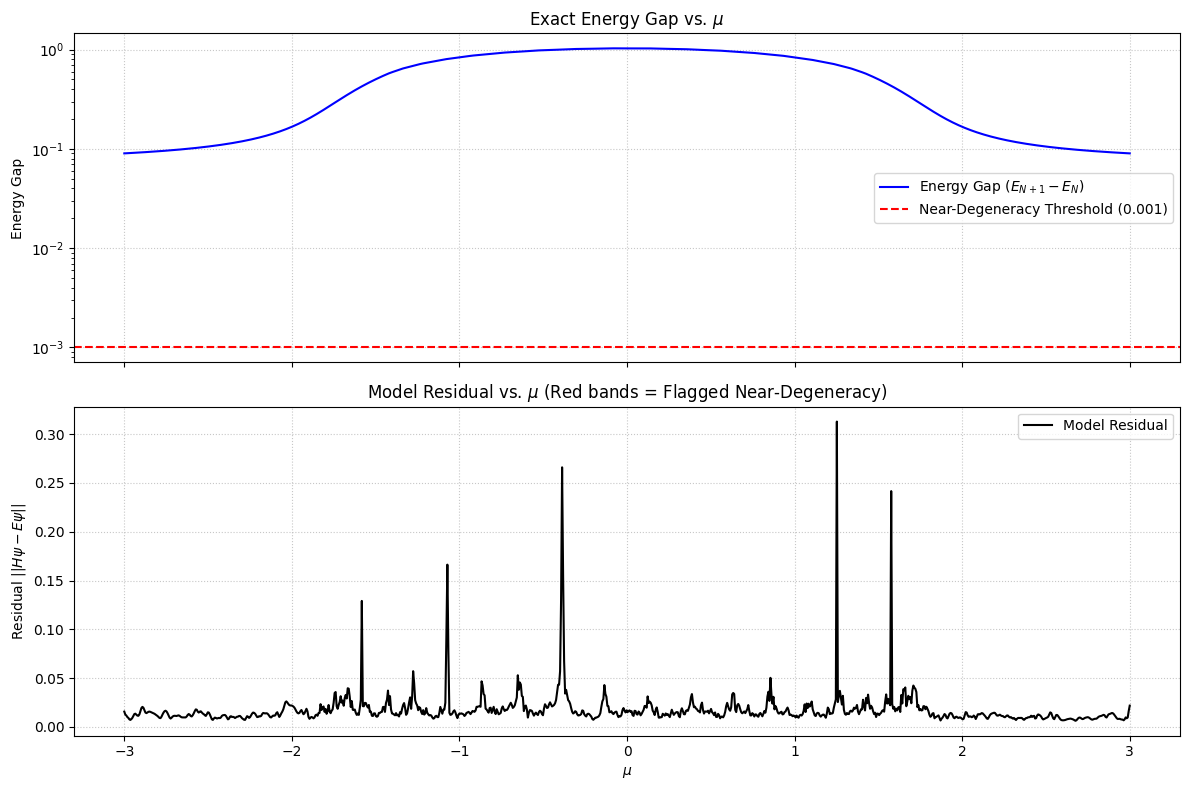


--- Diagnostic Summary ---
No points found with gap < 0.001.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Compute Exact Gaps across the training grid
print("Computing exact spectral gaps...")
gaps = []
for mu in mu_train:
    H = build_hamiltonian(mu, N=N)
    evals, _ = np.linalg.eigh(H)
    # N is the index of the lowest positive eigenvalue (zero-indexed, N=20)
    gap = evals[N+1] - evals[N]
    gaps.append(gap)
gaps = np.array(gaps)

# 2. Flag near-degeneracies
threshold = 1e-3
flagged_indices = np.where(gaps < threshold)[0]
flagged_mus = mu_train[flagged_indices]

# 3. Compute Model Residuals across the grid (using the last trained model in memory)
print("Computing model residuals...")
model.eval()
mu_tensor = torch.tensor(mu_train, dtype=torch.float32).unsqueeze(1).to(device)

with torch.no_grad():
    e_pred, psi_pred = model(mu_tensor)

    residuals = []
    # Calculate residuals manually for exactness point-by-point
    for i, mu in enumerate(mu_train):
        H = build_hamiltonian(mu, N=N)
        psi = psi_pred[i].cpu().numpy()
        e = e_pred[i].cpu().item()

        # ||H * psi - E * psi||
        res = np.linalg.norm(H @ psi - e * psi)
        residuals.append(res)
residuals = np.array(residuals)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Gap
ax1.plot(mu_train, gaps, 'b-', label=r'Energy Gap ($E_{N+1} - E_N$)')
ax1.axhline(threshold, color='red', linestyle='--', label=f'Near-Degeneracy Threshold ({threshold})')
# Highlight flagged regions
for f_mu in flagged_mus:
    ax1.axvline(f_mu, color='red', alpha=0.05, linewidth=2)
ax1.set_ylabel('Energy Gap')
ax1.set_title(r'Exact Energy Gap vs. $\mu$')
ax1.set_yscale('log') # Log scale helps visualize small gaps
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# Plot Residuals
ax2.plot(mu_train, residuals, 'k-', label='Model Residual')
for f_mu in flagged_mus:
    ax2.axvline(f_mu, color='red', alpha=0.05, linewidth=2)
ax2.set_xlabel(r'$\mu$')
ax2.set_ylabel(r'Residual $||H\psi - E\psi||$')
ax2.set_title(r'Model Residual vs. $\mu$ (Red bands = Flagged Near-Degeneracy)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Summary Statistics
print("\n--- Diagnostic Summary ---")
if len(flagged_indices) > 0:
    max_res_flagged = np.max(residuals[flagged_indices])
    mean_res_flagged = np.mean(residuals[flagged_indices])

    safe_indices = np.where(gaps >= threshold)[0]
    max_res_safe = np.max(residuals[safe_indices]) if len(safe_indices) > 0 else 0
    mean_res_safe = np.mean(residuals[safe_indices]) if len(safe_indices) > 0 else 0

    print(f"Number of flagged points (Gap < {threshold}): {len(flagged_indices)} out of {len(mu_train)}")
    print(f"Flagged regions primarily around mu = {np.unique(np.round(flagged_mus, 1))}")
    print(f"\n{'Region'.ljust(15)} | {'Mean Residual'.ljust(15)} | {'Max Residual'.ljust(15)}")
    print("-" * 50)
    print(f"{'FLAGGED (<1e-3)'.ljust(15)} | {mean_res_flagged:<15.6f} | {max_res_flagged:<15.6f}")
    print(f"{'SAFE (>=1e-3)'.ljust(15)} | {mean_res_safe:<15.6f} | {max_res_safe:<15.6f}")
else:
    print(f"No points found with gap < {threshold}.")


Unsupervised

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from torch.utils.data import DataLoader

# 1. Unsupervised Training Function
def train_unsupervised_model(model_name, model, epochs=3000):
    print(f"\n--- Training {model_name} (Unsupervised) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()

        for mu_batch, _, _ in train_loader:
            # We ignore e_batch and psi_batch for training (unsupervised!)
            mu_batch = mu_batch.to(device)
            optimizer.zero_grad()

            e_pred, psi_pred = model(mu_batch)

            # Reconstruct Hamiltonian for the batch
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # (a) Residual loss ||H psi - E psi||^2
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            R = H_psi - e_pred * psi_pred
            loss_res = torch.mean(R**2)

            # (b) PH-symmetry loss
            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + e_pred * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            # (d) Rayleigh-quotient consistency: E_pred ~ psi^T H psi
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
            loss_rayleigh = torch.mean((e_pred - E_rayleigh)**2)

            # (e) Targeting term: bias towards near-zero energy in-gap state
            loss_target = 0.1 * torch.mean(torch.abs(e_pred))

            # Total Unsupervised Loss
            loss = loss_res + loss_ph + loss_rayleigh + loss_target

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 500 == 0:
            mean_res, mean_e_err, corr, _, _ = compute_physics_metrics(model, val_loader)
            print(f"Epoch {epoch:04d} | Res: {mean_res:.6f} | dE: {mean_e_err:.6f} | Corr: {corr:.4f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# 2. Train and Evaluate Unsupervised Model
seed_everything(42)
model_unsup = SirenPINN_DualHead(hidden_features=32, hidden_layers=2)
model_unsup = train_unsupervised_model("Unsupervised PINN (32F_2L)", model_unsup, epochs=3000)

print("\n=== Unsupervised Evaluation ===")
mean_res_u, mean_e_err_u, corr_u, edge_p_u, edge_e_u = compute_physics_metrics(model_unsup, DataLoader(val_dataset, batch_size=64))
print(f"Unsupervised -> Res: {mean_res_u:.6f} | dE: {mean_e_err_u:.6f} | Corr: {corr_u:.4f}")

# 3. Compare with Supervised Baseline (from previous ablation)
print("\n=== Comparison: Supervised vs Unsupervised (32F_2L) ===")
print(f"{str('Metric').ljust(20)} | {'Supervised'.ljust(15)} | {'Unsupervised'.ljust(15)}")
print("-" * 55)
print(f"{str('Mean Residual').ljust(20)} | {mean_res_d:<15.6f} | {mean_res_u:<15.6f}")
print(f"{str('Mean dE').ljust(20)} | {mean_e_err_d:<15.6f} | {mean_e_err_u:<15.6f}")
print(f"{str('Edge Correlation').ljust(20)} | {corr_d:<15.4f} | {corr_u:<15.4f}")


--- Training Unsupervised PINN (32F_2L) (Unsupervised) ---
Epoch 0500 | Res: 0.357031 | dE: 0.195672 | Corr: 0.9265
Epoch 1000 | Res: 0.339012 | dE: 0.194761 | Corr: 0.9693
Epoch 1500 | Res: 0.271253 | dE: 0.194317 | Corr: 0.9817
Epoch 2000 | Res: 0.240642 | dE: 0.194293 | Corr: 0.9948
Epoch 2500 | Res: 0.241311 | dE: 0.194159 | Corr: 0.9972
Epoch 3000 | Res: 0.230886 | dE: 0.194130 | Corr: 0.9976
Unsupervised PINN (32F_2L) Training complete in 212.88s.

=== Unsupervised Evaluation ===
Unsupervised -> Res: 0.230886 | dE: 0.194130 | Corr: 0.9976

=== Comparison: Supervised vs Unsupervised (32F_2L) ===
Metric               | Supervised      | Unsupervised   
-------------------------------------------------------
Mean Residual        | 0.075068        | 0.230886       
Mean dE              | 0.016554        | 0.194130       
Edge Correlation     | 0.9995          | 0.9976         


## Unsupervised

Generating plots for Unsupervised PINN...


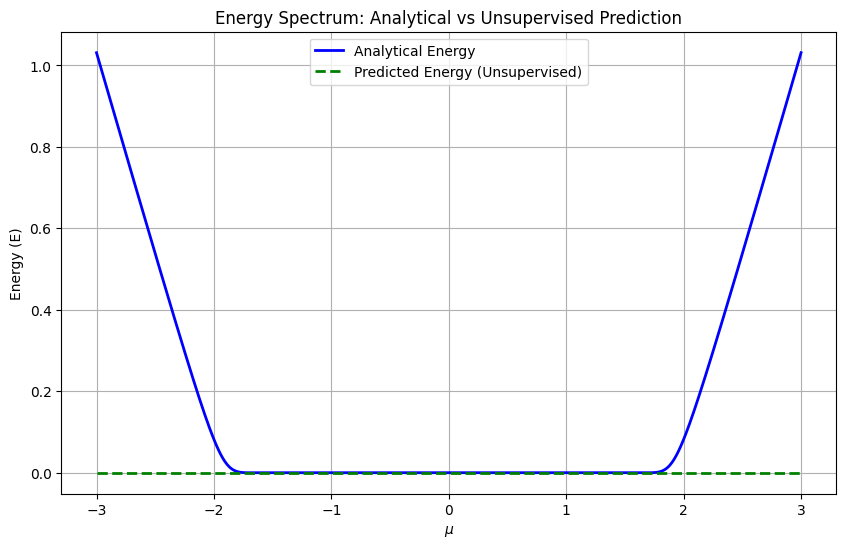

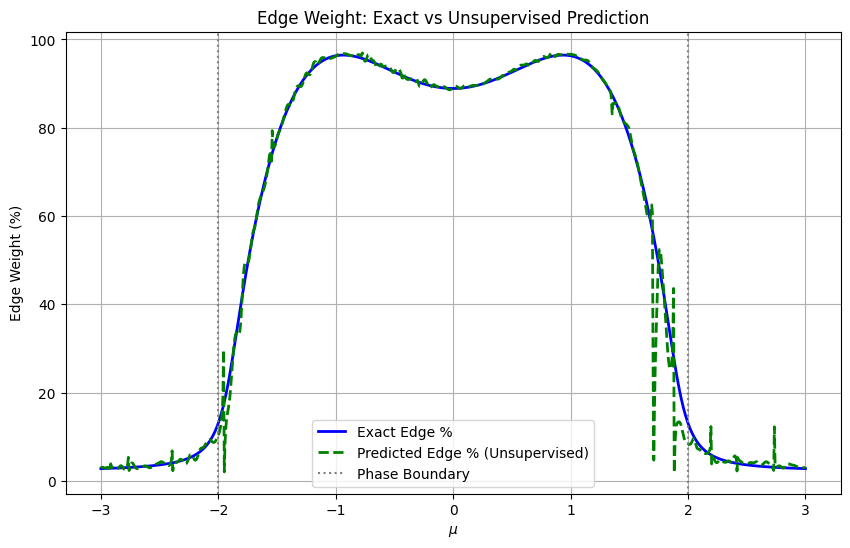

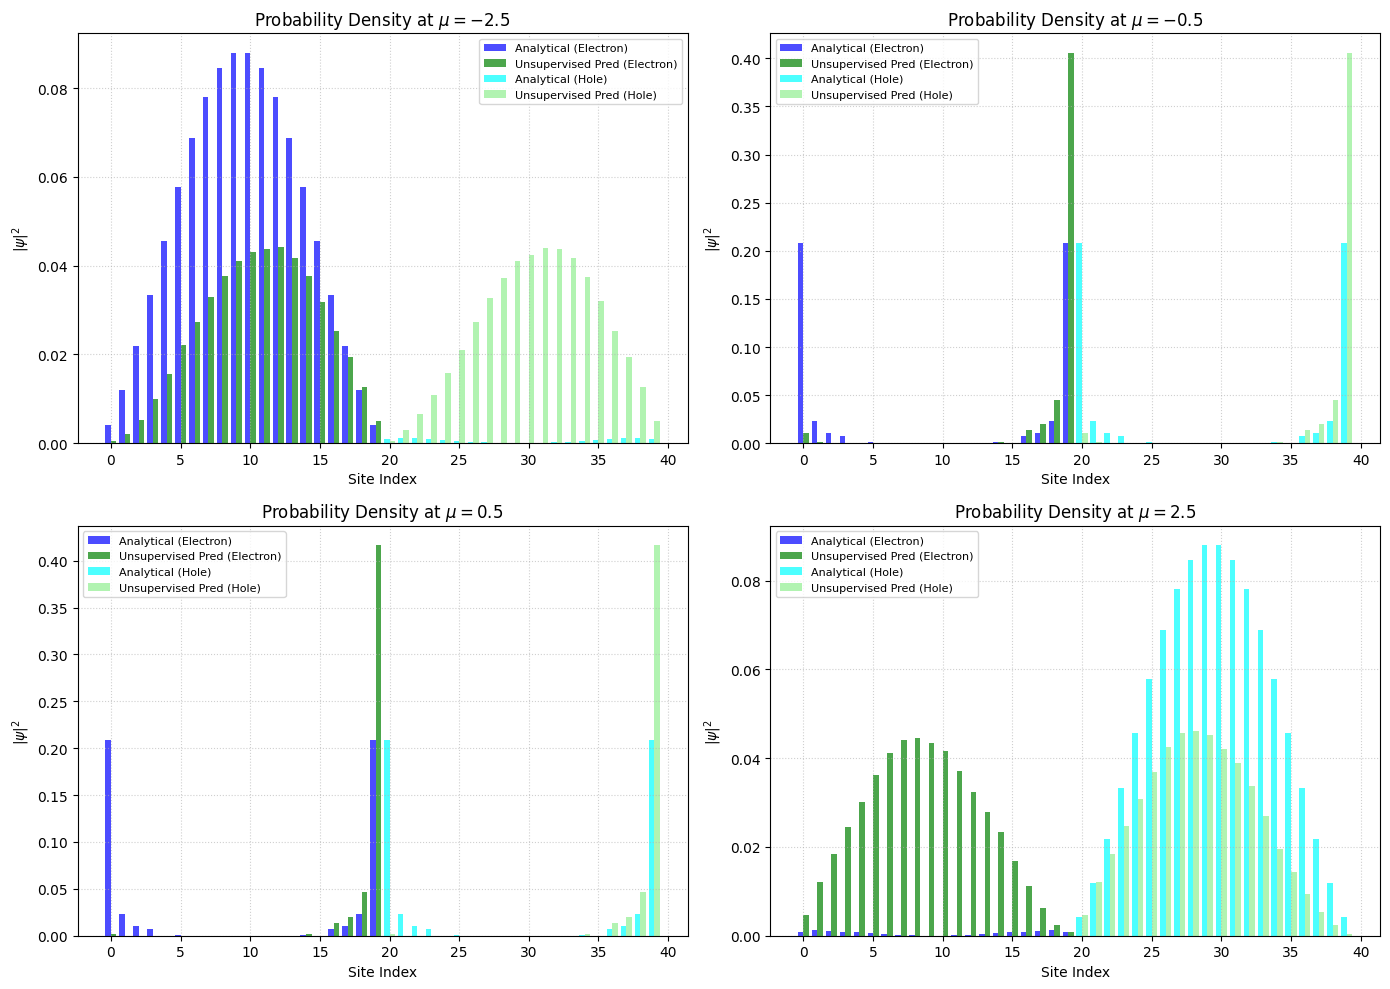

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- Unsupervised Model Plotting Suite ---
print("Generating plots for Unsupervised PINN...")

if 'model_unsup' not in globals() or 'X_tensor' not in globals():
    print("Error: Unsupervised model or test data not found. Please run the training cells first.")
else:
    model_unsup.eval()
    X_full = X_tensor.to(device)
    E_full_exact = E_tensor.cpu().numpy().flatten()
    Psi_full_exact = Psi_tensor.cpu().numpy()
    mu_arr = X_full.cpu().numpy().flatten()

    with torch.no_grad():
        E_full_pred_u, Psi_full_pred_u = model_unsup(X_full)
        E_full_pred_u = E_full_pred_u.cpu().numpy().flatten()
        Psi_full_pred_u = Psi_full_pred_u.cpu().numpy()

        # Enforce L2 norm
        norms_u = np.linalg.norm(Psi_full_pred_u, axis=1, keepdims=True)
        Psi_full_pred_u = Psi_full_pred_u / norms_u

    # 1. Energy Distribution Comparison
    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, E_full_exact, label="Analytical Energy", color='blue', linewidth=2)
    plt.plot(mu_arr, E_full_pred_u, label="Predicted Energy (Unsupervised)", color='green', linestyle='--', linewidth=2)
    plt.title('Energy Spectrum: Analytical vs Unsupervised Prediction')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Energy (E)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Edge Weight Comparison
    def calc_edge_prob(psi_arr):
        prob = np.abs(psi_arr)**2
        return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
                prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

    edge_exact = calc_edge_prob(Psi_full_exact)
    edge_pred_u = calc_edge_prob(Psi_full_pred_u)

    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, edge_exact, label="Exact Edge %", color='blue', linewidth=2)
    plt.plot(mu_arr, edge_pred_u, label="Predicted Edge % (Unsupervised)", color='green', linestyle='--', linewidth=2)
    plt.title('Edge Weight: Exact vs Unsupervised Prediction')
    plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
    plt.axvline(2.0, color='gray', linestyle=':')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Edge Weight (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Probability Densities Comparison (Bar Charts)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    mu_samples = [-2.5, -0.5, 0.5, 2.5]

    for i, mu_val in enumerate(mu_samples):
        ax = axes.flatten()[i]
        idx = np.argmin(np.abs(mu_arr - mu_val))
        prob_exact = np.abs(Psi_full_exact[idx])**2
        prob_pred_u = np.abs(Psi_full_pred_u[idx])**2

        # Electron components
        ax.bar(np.arange(N) - 0.2, prob_exact[:N], width=0.4, label='Analytical (Electron)', color='blue', alpha=0.7)
        ax.bar(np.arange(N) + 0.2, prob_pred_u[:N], width=0.4, label='Unsupervised Pred (Electron)', color='green', alpha=0.7)

        # Hole components
        ax.bar(np.arange(N, 2*N) - 0.2, prob_exact[N:], width=0.4, label='Analytical (Hole)', color='cyan', alpha=0.7)
        ax.bar(np.arange(N, 2*N) + 0.2, prob_pred_u[N:], width=0.4, label='Unsupervised Pred (Hole)', color='lightgreen', alpha=0.7)

        ax.set_title(f'Probability Density at $\\mu = {mu_val}$')
        ax.set_xlabel('Site Index')
        ax.set_ylabel(r'$|\psi|^2$')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import torch

print("=== Investigating Unsupervised Model Convergence ===\n")

# Select a handful of validation points (e.g., from different regimes)
sample_mus = [-2.5, -0.5, 0.5, 2.5]

model_unsup.eval()
with torch.no_grad():
    for mu in sample_mus:
        print(f"--- Analysis for mu = {mu} ---")

        # 1. Get model predictions
        mu_tensor = torch.tensor([[mu]], dtype=torch.float32).to(device)
        e_pred_tensor, psi_pred_tensor = model_unsup(mu_tensor)

        e_pred = e_pred_tensor.item()
        psi_pred = psi_pred_tensor.cpu().numpy().flatten()
        # Normalize just in case
        psi_pred = psi_pred / np.linalg.norm(psi_pred)

        # 2. Diagonalize full Hamiltonian
        H = build_hamiltonian(mu, N=N)
        evals, evecs = np.linalg.eigh(H)

        # Find 5 nearest exact eigenvalues to e_pred
        diffs = np.abs(evals - e_pred)
        nearest_indices = np.argsort(diffs)[:5]
        nearest_evals = evals[nearest_indices]

        print(f"Predicted E_pred: {e_pred:.6f}")
        print(f"5 Nearest Exact Eigenvalues:")
        for i, idx in enumerate(nearest_indices):
             print(f"  {i+1}. {evals[idx]:.6f} (diff: {diffs[idx]:.6f}, index: {idx})")

        # 3. Compute Rayleigh quotient
        rayleigh_q = psi_pred.T @ H @ psi_pred
        print(f"\nRayleigh Quotient (psi^T H psi): {rayleigh_q:.6f}")
        print(f"Difference |E_pred - Rayleigh|: {np.abs(e_pred - rayleigh_q):.6f}")

        # Calculate residual for context
        res = np.linalg.norm(H @ psi_pred - e_pred * psi_pred)
        print(f"Residual ||H psi - E_pred psi||: {res:.6f}\n")


=== Investigating Unsupervised Model Convergence ===

--- Analysis for mu = -2.5 ---
Predicted E_pred: -0.000000
5 Nearest Exact Eigenvalues:
  1. -0.537911 (diff: 0.537911, index: 19)
  2. 0.537911 (diff: 0.537911, index: 20)
  3. -0.643458 (diff: 0.643458, index: 18)
  4. 0.643458 (diff: 0.643458, index: 21)
  5. -0.799653 (diff: 0.799653, index: 17)

Rayleigh Quotient (psi^T H psi): -0.001253
Difference |E_pred - Rayleigh|: 0.001253
Residual ||H psi - E_pred psi||: 0.538606

--- Analysis for mu = -0.5 ---
Predicted E_pred: -0.000000
5 Nearest Exact Eigenvalues:
  1. -0.000022 (diff: 0.000022, index: 19)
  2. 0.000022 (diff: 0.000022, index: 20)
  3. -0.984711 (diff: 0.984711, index: 18)
  4. 0.984711 (diff: 0.984711, index: 21)
  5. -0.991296 (diff: 0.991296, index: 17)

Rayleigh Quotient (psi^T H psi): 0.000001
Difference |E_pred - Rayleigh|: 0.000001
Residual ||H psi - E_pred psi||: 0.023205

--- Analysis for mu = 0.5 ---
Predicted E_pred: 0.000000
5 Nearest Exact Eigenvalues:
  1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from torch.utils.data import DataLoader

# 1. New Model: Wavefunction only, E is derived.
class SirenPINN_ShiftInvert(nn.Module):
    def __init__(self, in_features=1, hidden_features=32, hidden_layers=2):
        super().__init__()
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, is_first=True, omega_0=30.0))
        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*self.net)

        self.psi_head = nn.Linear(hidden_features, 40)

        bound = np.sqrt(6 / hidden_features) / 2.0
        with torch.no_grad():
            self.psi_head.weight.uniform_(-bound, bound)

    def forward(self, x):
        features = self.net(x)
        Psi_pred = self.psi_head(features)
        # Explicit L2 norm constraint on Psi
        Psi_pred = Psi_pred / torch.norm(Psi_pred, dim=1, keepdim=True)
        return Psi_pred

# Precompute Identity matrix
I_base = torch.eye(40, dtype=torch.float32, device=device)

# 2. Shift-Invert Unsupervised Training Function
def train_shift_invert_model(model_name, model, epochs=3000, sigma=0.0):
    print(f"\n--- Training {model_name} (Shift-Invert) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()

        for mu_batch, _, _ in train_loader:
            mu_batch = mu_batch.to(device)
            optimizer.zero_grad()

            psi_pred = model(mu_batch)

            # Reconstruct Hamiltonian for the batch
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # Compute Rayleigh Quotient E = psi^T H psi
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)

            # Shift-invert loss: || (H - sigma*I) psi - E' psi ||^2 -> minimize residual for eigenvalue near sigma
            # For a true eigenstate near sigma, (H-sigma*I)psi = (E-sigma)psi.
            H_shifted = H_batch - sigma * I_base.unsqueeze(0)
            H_shifted_psi = torch.bmm(H_shifted, psi_pred.unsqueeze(-1)).squeeze(-1)

            # The effective eigenvalue of H_shifted is (E_rayleigh - sigma)
            v_target = (E_rayleigh - sigma) * psi_pred

            loss_shift_invert = torch.mean((H_shifted_psi - v_target)**2)

            # (b) PH-symmetry loss (optional, but good for physics)
            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + E_rayleigh * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            loss = loss_shift_invert + loss_ph

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | Shift-Invert Loss: {loss_shift_invert.item():.6f} | PH Loss: {loss_ph.item():.6f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# 3. Train the new model
seed_everything(42)
model_shift = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
model_shift = train_shift_invert_model("Shift-Invert PINN", model_shift, epochs=3000, sigma=0.0)

# 4. Validation on probe points
print("\n=== Investigating Shift-Invert Model Convergence ===\n")

sample_mus = [-2.5, -0.5, 0.5, 2.5]

model_shift.eval()
with torch.no_grad():
    for mu in sample_mus:
        print(f"--- Analysis for mu = {mu} ---")

        mu_tensor = torch.tensor([[mu]], dtype=torch.float32).to(device)
        psi_pred_tensor = model_shift(mu_tensor)
        psi_pred = psi_pred_tensor.cpu().numpy().flatten()
        psi_pred = psi_pred / np.linalg.norm(psi_pred)

        H = build_hamiltonian(mu, N=N)
        evals, evecs = np.linalg.eigh(H)

        # Dynamically compute E_pred via Rayleigh quotient
        rayleigh_q = psi_pred.T @ H @ psi_pred
        e_pred = rayleigh_q

        diffs = np.abs(evals - e_pred)
        nearest_indices = np.argsort(diffs)[:5]

        print(f"Rayleigh E_pred: {e_pred:.6f}")
        print(f"5 Nearest Exact Eigenvalues:")
        for i, idx in enumerate(nearest_indices):
             print(f"  {i+1}. {evals[idx]:.6f} (diff: {diffs[idx]:.6f}, index: {idx})")

        res = np.linalg.norm(H @ psi_pred - e_pred * psi_pred)
        print(f"Residual ||H psi - E_pred psi||: {res:.6f}\n")



--- Training Shift-Invert PINN (Shift-Invert) ---
Epoch 0500 | Shift-Invert Loss: 0.000047 | PH Loss: 0.000047
Epoch 1000 | Shift-Invert Loss: 0.000376 | PH Loss: 0.000376
Epoch 1500 | Shift-Invert Loss: 0.000405 | PH Loss: 0.000405
Epoch 2000 | Shift-Invert Loss: 0.000029 | PH Loss: 0.000029
Epoch 2500 | Shift-Invert Loss: 0.000006 | PH Loss: 0.000006
Epoch 3000 | Shift-Invert Loss: 0.000020 | PH Loss: 0.000020
Shift-Invert PINN Training complete in 194.67s.

=== Investigating Shift-Invert Model Convergence ===

--- Analysis for mu = -2.5 ---
Rayleigh E_pred: -2.826541
5 Nearest Exact Eigenvalues:
  1. -2.816283 (diff: 0.010257, index: 9)
  2. -3.090044 (diff: 0.263503, index: 8)
  3. -2.536172 (diff: 0.290369, index: 10)
  4. -3.352270 (diff: 0.525729, index: 7)
  5. -2.254828 (diff: 0.571713, index: 11)
Residual ||H psi - E_pred psi||: 0.075188

--- Analysis for mu = -0.5 ---
Rayleigh E_pred: -1.189204
5 Nearest Exact Eigenvalues:
  1. -1.188335 (diff: 0.000868, index: 13)
  2. -1.

Generating plots for Shift-Invert PINN...


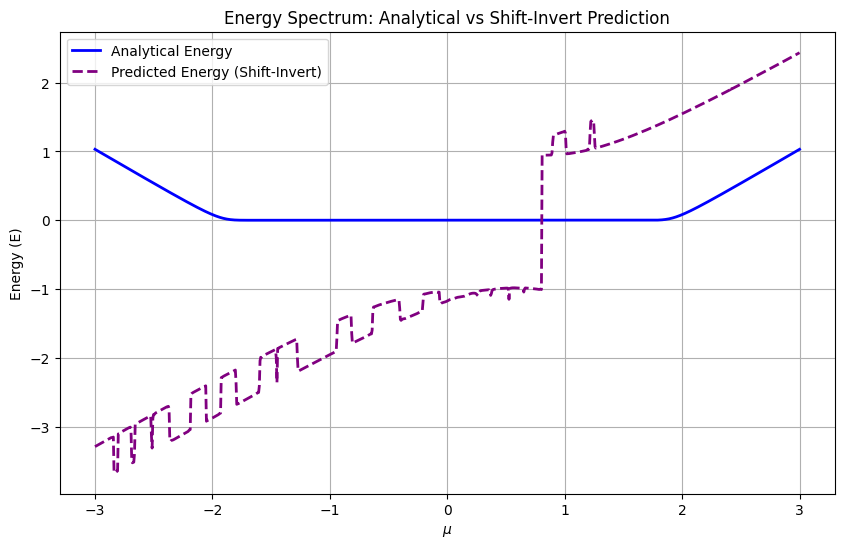

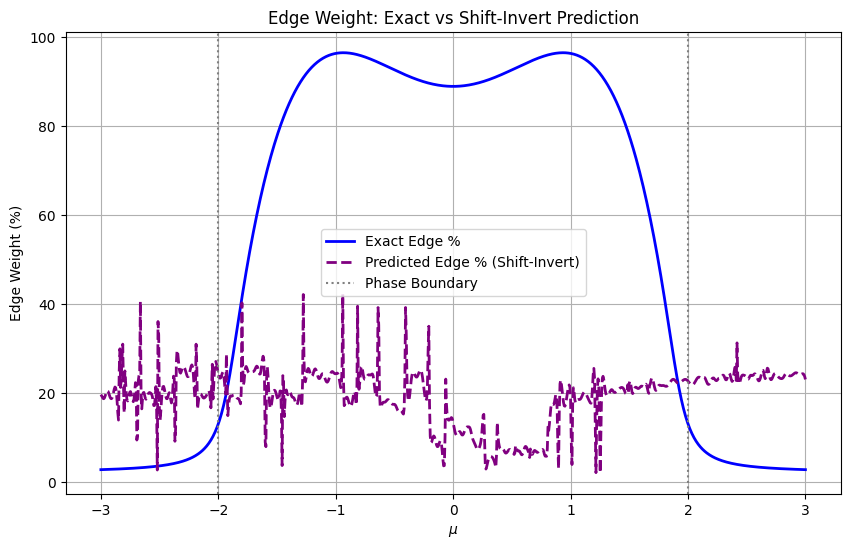

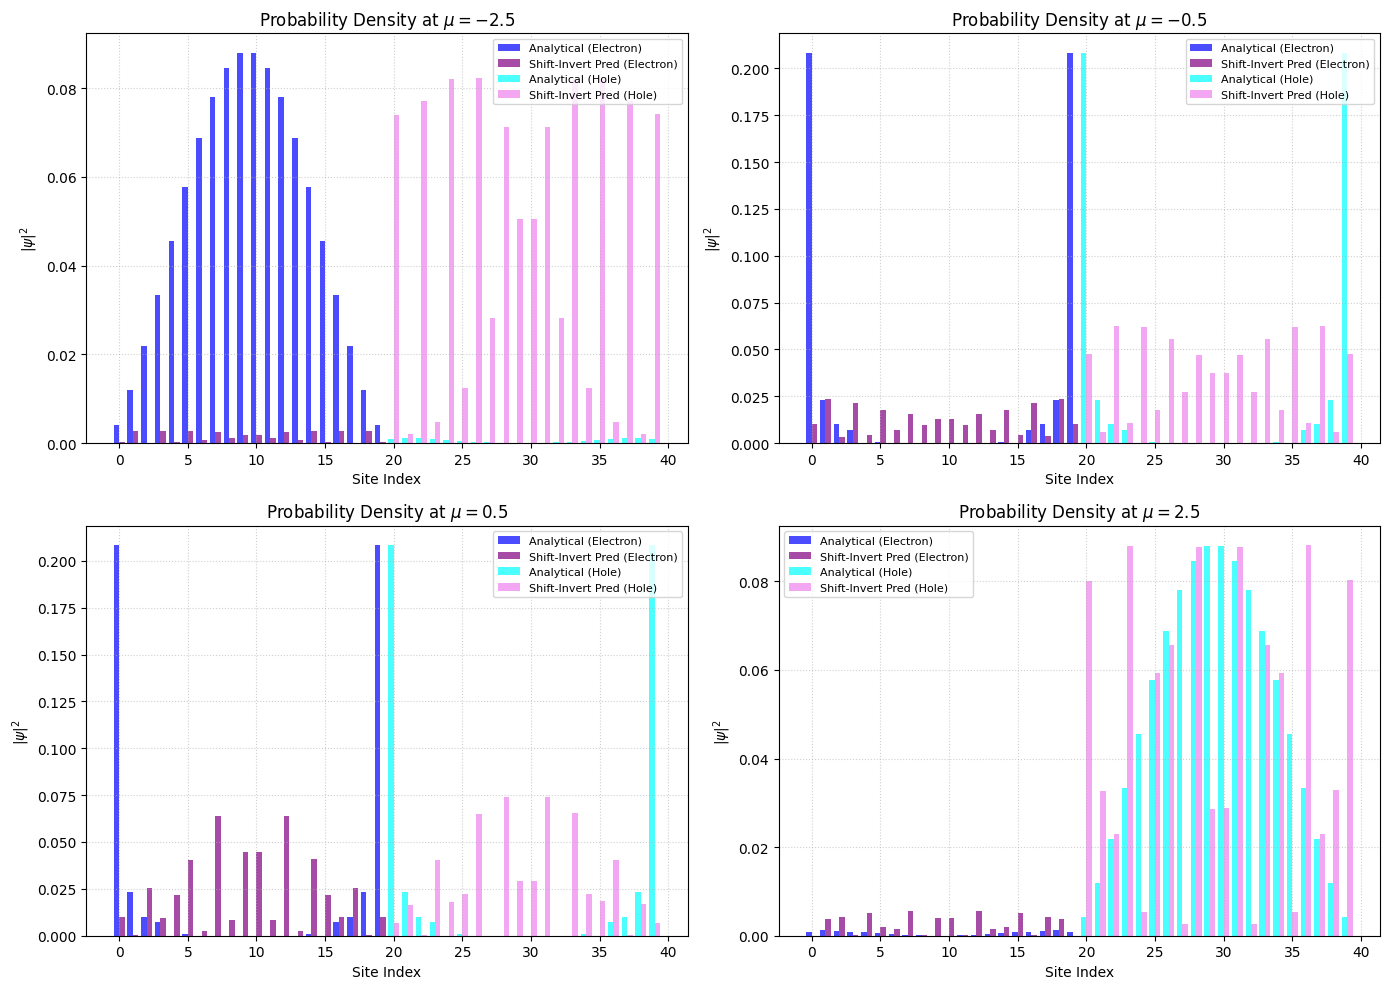

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- Shift-Invert Unsupervised Model Plotting Suite ---
print("Generating plots for Shift-Invert PINN...")

if 'model_shift' not in globals() or 'X_tensor' not in globals():
    print("Error: Shift-Invert model or test data not found. Please run the training cells first.")
else:
    model_shift.eval()
    X_full = X_tensor.to(device)
    E_full_exact = E_tensor.cpu().numpy().flatten()
    Psi_full_exact = Psi_tensor.cpu().numpy()
    mu_arr = X_full.cpu().numpy().flatten()

    with torch.no_grad():
        Psi_full_pred_si = model_shift(X_full)
        # Enforce L2 norm
        norms_si = torch.norm(Psi_full_pred_si, dim=1, keepdim=True)
        Psi_full_pred_si = Psi_full_pred_si / norms_si

        # Reconstruct Hamiltonian for the batch to get Rayleigh quotient (Energy)
        H_batch = H_base.unsqueeze(0) + X_full.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
        H_psi = torch.bmm(H_batch, Psi_full_pred_si.unsqueeze(-1)).squeeze(-1)
        E_full_pred_si = torch.sum(Psi_full_pred_si * H_psi, dim=1).cpu().numpy()

        Psi_full_pred_si = Psi_full_pred_si.cpu().numpy()

    # 1. Energy Distribution Comparison
    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, E_full_exact, label="Analytical Energy", color='blue', linewidth=2)
    plt.plot(mu_arr, E_full_pred_si, label="Predicted Energy (Shift-Invert)", color='purple', linestyle='--', linewidth=2)
    plt.title('Energy Spectrum: Analytical vs Shift-Invert Prediction')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Energy (E)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Edge Weight Comparison
    def calc_edge_prob(psi_arr):
        prob = np.abs(psi_arr)**2
        return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
                prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

    edge_exact = calc_edge_prob(Psi_full_exact)
    edge_pred_si = calc_edge_prob(Psi_full_pred_si)

    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, edge_exact, label="Exact Edge %", color='blue', linewidth=2)
    plt.plot(mu_arr, edge_pred_si, label="Predicted Edge % (Shift-Invert)", color='purple', linestyle='--', linewidth=2)
    plt.title('Edge Weight: Exact vs Shift-Invert Prediction')
    plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
    plt.axvline(2.0, color='gray', linestyle=':')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Edge Weight (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Probability Densities Comparison (Bar Charts)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    mu_samples = [-2.5, -0.5, 0.5, 2.5]

    for i, mu_val in enumerate(mu_samples):
        ax = axes.flatten()[i]
        idx = np.argmin(np.abs(mu_arr - mu_val))
        prob_exact = np.abs(Psi_full_exact[idx])**2
        prob_pred_si = np.abs(Psi_full_pred_si[idx])**2

        # Electron components
        ax.bar(np.arange(N) - 0.2, prob_exact[:N], width=0.4, label='Analytical (Electron)', color='blue', alpha=0.7)
        ax.bar(np.arange(N) + 0.2, prob_pred_si[:N], width=0.4, label='Shift-Invert Pred (Electron)', color='purple', alpha=0.7)

        # Hole components
        ax.bar(np.arange(N, 2*N) - 0.2, prob_exact[N:], width=0.4, label='Analytical (Hole)', color='cyan', alpha=0.7)
        ax.bar(np.arange(N, 2*N) + 0.2, prob_pred_si[N:], width=0.4, label='Shift-Invert Pred (Hole)', color='violet', alpha=0.7)

        ax.set_title(fr'Probability Density at $\mu = {mu_val}$')
        ax.set_xlabel('Site Index')
        ax.set_ylabel(r'$|\psi|^2$')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from torch.utils.data import DataLoader

# Note: Using dense torch.linalg.solve is cheap for 40x40.
# For larger 2D lattice Hamiltonians, this must be replaced with a sparse/iterative solver
# (e.g., GMRES or MINRES) because dense inversion cost scales cubically.

def train_inverse_power_iteration(model_name, model, epochs=3000, sigma=1e-3):
    print(f"\n--- Training {model_name} (Inverse Power Iteration) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()

        for mu_batch, _, _ in train_loader:
            mu_batch = mu_batch.to(device)
            optimizer.zero_grad()

            # 1. Forward pass
            psi_pred = model(mu_batch)

            # psi_prev is the network's own prediction, detached
            psi_prev = psi_pred.detach()

            # Reconstruct Hamiltonian for the batch
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # (H - sigma*I)
            H_shifted = H_batch - sigma * I_base.unsqueeze(0)

            # 2. Solve the linear system: (H - sigma*I) @ v = psi_prev
            # Using dense solver.
            # We add a small sigma to avoid singularity issues exactly at E=0.
            v = torch.linalg.solve(H_shifted, psi_prev)

            # 3. Normalize v to get the target
            v_norm = torch.norm(v, dim=1, keepdim=True)
            target = v / v_norm

            # 4. Train the network toward this target
            loss_ipi = torch.mean((psi_pred - target)**2)

            # (b) PH-symmetry loss (optional constraint)
            # Calculate Rayleigh Quotient for PH loss
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)

            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + E_rayleigh * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            loss = loss_ipi + 0.1 * loss_ph # Reduced weight for PH to let IPI dominate

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | IPI Loss: {loss_ipi.item():.6f} | PH Loss: {loss_ph.item():.6f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# Train the model with Inverse Power Iteration
seed_everything(42)
model_ipi = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
model_ipi = train_inverse_power_iteration("IPI PINN", model_ipi, epochs=3000, sigma=1e-3)

# Validation on probe points
print("\n=== Investigating IPI Model Convergence ===\n")

sample_mus = [-2.5, -0.5, 0.5, 2.5]

model_ipi.eval()
with torch.no_grad():
    for mu in sample_mus:
        print(f"--- Analysis for mu = {mu} ---")

        mu_tensor = torch.tensor([[mu]], dtype=torch.float32).to(device)
        psi_pred_tensor = model_ipi(mu_tensor)
        psi_pred = psi_pred_tensor.cpu().numpy().flatten()
        psi_pred = psi_pred / np.linalg.norm(psi_pred)

        H = build_hamiltonian(mu, N=N)
        evals, evecs = np.linalg.eigh(H)

        # Compute E_pred via Rayleigh quotient
        rayleigh_q = psi_pred.T @ H @ psi_pred
        e_pred = rayleigh_q

        diffs = np.abs(evals - e_pred)
        nearest_indices = np.argsort(diffs)[:5]

        print(f"Rayleigh E_pred: {e_pred:.6f}")
        print(f"5 Nearest Exact Eigenvalues:")
        for i, idx in enumerate(nearest_indices):
             print(f"  {i+1}. {evals[idx]:.6f} (diff: {diffs[idx]:.6f}, index: {idx})")

        res = np.linalg.norm(H @ psi_pred - e_pred * psi_pred)
        print(f"Residual ||H psi - E_pred psi||: {res:.6f}\n")


--- Training IPI PINN (Inverse Power Iteration) ---
Epoch 0500 | IPI Loss: 0.018767 | PH Loss: 0.001383
Epoch 1000 | IPI Loss: 0.012573 | PH Loss: 0.003312
Epoch 1500 | IPI Loss: 0.009075 | PH Loss: 0.000802
Epoch 2000 | IPI Loss: 0.022941 | PH Loss: 0.003472
Epoch 2500 | IPI Loss: 0.002769 | PH Loss: 0.000347
Epoch 3000 | IPI Loss: 0.007910 | PH Loss: 0.000491
IPI PINN Training complete in 230.16s.

=== Investigating IPI Model Convergence ===

--- Analysis for mu = -2.5 ---
Rayleigh E_pred: 0.538074
5 Nearest Exact Eigenvalues:
  1. 0.537911 (diff: 0.000164, index: 20)
  2. 0.643458 (diff: 0.105383, index: 21)
  3. 0.799653 (diff: 0.261578, index: 22)
  4. 0.991896 (diff: 0.453822, index: 23)
  5. 1.210956 (diff: 0.672882, index: 24)
Residual ||H psi - E_pred psi||: 0.233344

--- Analysis for mu = -0.5 ---
Rayleigh E_pred: 0.696060
5 Nearest Exact Eigenvalues:
  1. 0.984711 (diff: 0.288651, index: 21)
  2. 0.991296 (diff: 0.295236, index: 22)
  3. 1.063836 (diff: 0.367776, index: 23)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from torch.utils.data import DataLoader

def train_inverse_power_iteration(model_name, model, epochs=3000, sigma=1e-3, epsilon=1e-5):
    print(f"\n--- Training {model_name} (Inverse Power Iteration with Stabilization) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()

        for mu_batch, _, _ in train_loader:
            mu_batch = mu_batch.to(device)
            optimizer.zero_grad()

            # 1. Forward pass
            psi_pred = model(mu_batch)
            psi_prev = psi_pred.detach()

            # Reconstruct Hamiltonian for the batch
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # (H - sigma*I)
            H_shifted = H_batch - sigma * I_base.unsqueeze(0)

            # Add Tikhonov regularization for stability: H_shifted_reg = H_shifted + epsilon * I
            H_shifted_reg = H_shifted + epsilon * I_base.unsqueeze(0)

            # 2. Solve the linear system using float64 for better numerical stability
            H_shifted_reg_64 = H_shifted_reg.to(torch.float64)
            psi_prev_64 = psi_prev.to(torch.float64)

            v_64 = torch.linalg.solve(H_shifted_reg_64, psi_prev_64)
            v = v_64.to(torch.float32)

            # 3. Normalize v to get the target
            v_norm = torch.norm(v, dim=1, keepdim=True)
            target = v / v_norm

            # 4. Train the network toward this target
            loss_ipi = torch.mean((psi_pred - target)**2)

            # (b) PH-symmetry loss (optional constraint)
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)

            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + E_rayleigh * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            loss = loss_ipi + 0.1 * loss_ph

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | IPI Loss: {loss_ipi.item():.6f} | PH Loss: {loss_ph.item():.6f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# Train the model with stabilized Inverse Power Iteration
seed_everything(42)
model_ipi_stable = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
model_ipi_stable = train_inverse_power_iteration("Stable IPI PINN", model_ipi_stable, epochs=3000, sigma=1e-3, epsilon=1e-5)

# Validation on probe points
print("\n=== Investigating Stable IPI Model Convergence ===\n")

sample_mus = [-2.5, -0.5, 0.5, 2.5]

model_ipi_stable.eval()
with torch.no_grad():
    for mu in sample_mus:
        print(f"--- Analysis for mu = {mu} ---")

        mu_tensor = torch.tensor([[mu]], dtype=torch.float32).to(device)
        psi_pred_tensor = model_ipi_stable(mu_tensor)
        psi_pred = psi_pred_tensor.cpu().numpy().flatten()
        psi_pred = psi_pred / np.linalg.norm(psi_pred)

        H = build_hamiltonian(mu, N=N)
        evals, evecs = np.linalg.eigh(H)

        # Compute E_pred via Rayleigh quotient
        rayleigh_q = psi_pred.T @ H @ psi_pred
        e_pred = rayleigh_q

        diffs = np.abs(evals - e_pred)
        nearest_indices = np.argsort(diffs)[:5]

        print(f"Rayleigh E_pred: {e_pred:.6f}")
        print(f"5 Nearest Exact Eigenvalues:")
        for i, idx in enumerate(nearest_indices):
             print(f"  {i+1}. {evals[idx]:.6f} (diff: {diffs[idx]:.6f}, index: {idx})")

        res = np.linalg.norm(H @ psi_pred - e_pred * psi_pred)
        print(f"Residual ||H psi - E_pred psi||: {res:.6f}\n")



--- Training Stable IPI PINN (Inverse Power Iteration with Stabilization) ---
Epoch 0500 | IPI Loss: 0.015678 | PH Loss: 0.000603
Epoch 1000 | IPI Loss: 0.016952 | PH Loss: 0.000362
Epoch 1500 | IPI Loss: 0.007969 | PH Loss: 0.000280
Epoch 2000 | IPI Loss: 0.036101 | PH Loss: 0.001124
Epoch 2500 | IPI Loss: 0.004244 | PH Loss: 0.000772
Epoch 3000 | IPI Loss: 0.015318 | PH Loss: 0.001913
Stable IPI PINN Training complete in 250.44s.

=== Investigating Stable IPI Model Convergence ===

--- Analysis for mu = -2.5 ---
Rayleigh E_pred: 0.540748
5 Nearest Exact Eigenvalues:
  1. 0.537911 (diff: 0.002838, index: 20)
  2. 0.643458 (diff: 0.102709, index: 21)
  3. 0.799653 (diff: 0.258904, index: 22)
  4. 0.991896 (diff: 0.451148, index: 23)
  5. 1.210956 (diff: 0.670208, index: 24)
Residual ||H psi - E_pred psi||: 0.203791

--- Analysis for mu = -0.5 ---
Rayleigh E_pred: 1.309638
5 Nearest Exact Eigenvalues:
  1. 1.287543 (diff: 0.022095, index: 27)
  2. 1.343020 (diff: 0.033382, index: 28)
 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from torch.utils.data import DataLoader

def train_robust_ipi(model_name, model, epochs=3000, sigma=1e-3, epsilon=1e-5, noise_std=0.05):
    print(f"\n--- Training {model_name} (Noise-Injected & Sign-Aligned IPI) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()

        for mu_batch, _, _ in train_loader:
            mu_batch = mu_batch.to(device)
            optimizer.zero_grad()

            # 1. Forward pass
            psi_pred = model(mu_batch)
            psi_prev = psi_pred.detach()

            # FIX 1: Inject noise to break orthogonality to highly localized edge states
            psi_noisy = psi_prev + noise_std * torch.randn_like(psi_prev)
            psi_noisy = psi_noisy / torch.norm(psi_noisy, dim=1, keepdim=True)

            # Reconstruct Hamiltonian for the batch
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # Shifted and Regularized Hamiltonian
            H_shifted = H_batch - sigma * I_base.unsqueeze(0)
            H_shifted_reg = H_shifted + epsilon * I_base.unsqueeze(0)

            # 2. Solve the linear system using float64 for numerical stability
            H_shifted_reg_64 = H_shifted_reg.to(torch.float64)
            psi_noisy_64 = psi_noisy.to(torch.float64)

            v_64 = torch.linalg.solve(H_shifted_reg_64, psi_noisy_64)
            v = v_64.to(torch.float32)

            # 3. Normalize to get the eigenvector target
            v_norm = torch.norm(v, dim=1, keepdim=True)
            target = v / v_norm

            # FIX 2: Sign Alignment. IPI can flip the global phase (sign) arbitrarily.
            # We align the target's sign to the network's prediction to prevent MSE from averaging to 0.
            dot_product = torch.sum(psi_pred * target, dim=1, keepdim=True)
            target = target * torch.sign(dot_product + 1e-8)

            # 4. Train the network toward this aligned target
            loss_ipi = torch.mean((psi_pred - target)**2)

            # PH-symmetry loss (Optional constraint)
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + E_rayleigh * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            loss = loss_ipi + 0.1 * loss_ph

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | IPI Loss: {loss_ipi.item():.6f} | PH Loss: {loss_ph.item():.6f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# Train the model with Robust Inverse Power Iteration
seed_everything(42)
model_ipi_robust = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
model_ipi_robust = train_robust_ipi("Robust IPI PINN", model_ipi_robust, epochs=3000, sigma=1e-3, epsilon=1e-5, noise_std=0.05)

# Validation on probe points
print("\n=== Investigating Robust IPI Model Convergence ===\n")
sample_mus = [-2.5, -0.5, 0.5, 2.5]

model_ipi_robust.eval()
with torch.no_grad():
    for mu in sample_mus:
        print(f"--- Analysis for mu = {mu} ---")
        mu_tensor = torch.tensor([[mu]], dtype=torch.float32).to(device)
        psi_pred_tensor = model_ipi_robust(mu_tensor)
        psi_pred = psi_pred_tensor.cpu().numpy().flatten()
        psi_pred = psi_pred / np.linalg.norm(psi_pred)

        H = build_hamiltonian(mu, N=N)
        evals, evecs = np.linalg.eigh(H)

        # Compute E_pred via Rayleigh quotient
        rayleigh_q = psi_pred.T @ H @ psi_pred
        e_pred = rayleigh_q

        diffs = np.abs(evals - e_pred)
        nearest_indices = np.argsort(diffs)[:5]

        print(f"Rayleigh E_pred: {e_pred:.6f}")
        print(f"5 Nearest Exact Eigenvalues:")
        for i, idx in enumerate(nearest_indices):
             print(f"  {i+1}. {evals[idx]:.6f} (diff: {diffs[idx]:.6f}, index: {idx})")

        res = np.linalg.norm(H @ psi_pred - e_pred * psi_pred)
        print(f"Residual ||H psi - E_pred psi||: {res:.6f}\n")


--- Training Robust IPI PINN (Noise-Injected & Sign-Aligned IPI) ---


NameError: name 'device' is not defined

with the cosine annealing, i always saw really strong convergence around 2500 then after that worsening performance. Explain only why this is
The worsening performance after epoch 2500 is due to the cyclic mathematical nature of PyTorch's CosineAnnealingLR scheduler.

When T_max is set to 2500, the learning rate follows a cosine curve downwards, reaching its absolute minimum (typically near zero) exactly at epoch 2500. This tiny learning rate allows the model to perfectly fine-tune and settle deeply into a minimum, giving you the strong convergence you noticed.

However, if training continues past T_max (e.g., to 3000 epochs), the cosine curve naturally starts traveling back up. The learning rate begins to increase again, which acts like a "warm restart". This sudden increase in the learning rate jolts the optimizer out of the stable minimum it just found, causing the loss and residuals to spike and worsening the overall performance.

So t_max should be equal to number of epochs in total?
Yes, exactly!

If you want a single, smooth training run where the model settles into the best possible minimum at the very end, T_max should be set to the total number of epochs (e.g., T_max = 3000 for 3000 epochs).

When you do this, the learning rate gracefully decays over the entire duration of training. It will reach its absolute minimum precisely on the final epoch, allowing the optimizer to make the tiniest, most careful fine-tuning adjustments right before training stops.

(Note: Deliberately letting the learning rate bounce back up is actually a valid technique known as "Warm Restarts". It's used to intentionally jolt the model out of a local minimum to hopefully find a better one. But if your goal is just straight, stable convergence, keeping T_max equal to your total epochs is the way to go!)

In [ ]:
import sys
import sympy
import sympy.printing.str
import sympy.core
import sympy.core.symbol

# Explicitly attach the printing and core modules to sympy
setattr(sympy, 'printing', sys.modules['sympy.printing'])
setattr(sympy, 'core', sys.modules['sympy.core'])
sympy.printing.StrPrinter = sympy.printing.str.StrPrinter

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import random
from torch.utils.data import DataLoader

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Fix all random seeds
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0,
                                            np.sqrt(6 / self.in_features) / self.omega_0)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

# Wavefunction-only model architecture
class SirenPINN_ShiftInvert(nn.Module):
    def __init__(self, in_features=1, hidden_features=32, hidden_layers=2):
        super().__init__()
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, is_first=True, omega_0=30.0))
        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*self.net)

        self.psi_head = nn.Linear(hidden_features, 40)

        bound = np.sqrt(6 / hidden_features) / 2.0
        with torch.no_grad():
            self.psi_head.weight.uniform_(-bound, bound)

    def forward(self, x):
        features = self.net(x)
        Psi_pred = self.psi_head(features)
        # Explicit L2 norm constraint on Psi
        Psi_pred = Psi_pred / torch.norm(Psi_pred, dim=1, keepdim=True)
        return Psi_pred

# Precompute Constant Hamiltonian components on GPU for Batched Operations
N = 20
H_base = torch.zeros((2*N, 2*N), dtype=torch.float32, device=device)
t_hop = 1.0
delta_pair = 0.5
for i in range(N-1):
    H_base[i, i+1] = H_base[i+1, i] = -t_hop
    H_base[N+i, N+i+1] = H_base[N+i+1, N+i] = +t_hop
    H_base[i, N+i+1] = +delta_pair
    H_base[N+i+1, i] = +delta_pair
    H_base[i+1, N+i] = -delta_pair
    H_base[N+i, i+1] = -delta_pair

H_mu_diag = torch.zeros((2*N,), dtype=torch.float32, device=device)
H_mu_diag[:N] = -1.0
H_mu_diag[N:] = 1.0
H_mu_diag = torch.diag(H_mu_diag)

# Particle-hole operator (Xi) matrix for N=20
Xi = torch.zeros((40, 40), dtype=torch.float32, device=device)
Xi[:20, 20:] = torch.eye(20, device=device)
Xi[20:, :20] = torch.eye(20, device=device)

def train_folded_spectrum(model_name, model, epochs=3000):
    print(f"\n--- Training {model_name} (Folded Spectrum / H^2 Minimization) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()

        for mu_batch, _, _ in train_loader:
            mu_batch = mu_batch.to(device)
            optimizer.zero_grad()

            # Forward pass: predict normalized wavefunction
            psi_pred = model(mu_batch)

            # Reconstruct Hamiltonian for the batch
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # FOLDED SPECTRUM LOSS: Minimize ||H * psi||^2
            # This strictly targets the eigenstate with energy closest to E = 0
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            loss_fsm = torch.mean(H_psi**2)

            # PH-symmetry constraint (Optional but beneficial for physics)
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + E_rayleigh * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            # Total loss
            loss = loss_fsm + 0.1 * loss_ph

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | FSM Loss: {loss_fsm.item():.6f} | PH Loss: {loss_ph.item():.6f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# Train the model using the Folded Spectrum Method
seed_everything(42)
model_fsm = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
model_fsm = train_folded_spectrum("Folded Spectrum PINN", model_fsm, epochs=3000)

# Validation on probe points
print("\n=== Investigating Folded Spectrum Model Convergence ===\n")
sample_mus = [-2.5, -0.5, 0.5, 2.5]

model_fsm.eval()
with torch.no_grad():
    for mu in sample_mus:
        print(f"--- Analysis for mu = {mu} ---")
        mu_tensor = torch.tensor([[mu]], dtype=torch.float32).to(device)
        psi_pred_tensor = model_fsm(mu_tensor)
        psi_pred = psi_pred_tensor.cpu().numpy().flatten()
        psi_pred = psi_pred / np.linalg.norm(psi_pred)

        H = build_hamiltonian(mu, N=N)
        evals, evecs = np.linalg.eigh(H)

        # Compute E_pred via Rayleigh quotient
        rayleigh_q = psi_pred.T @ H @ psi_pred
        e_pred = rayleigh_q

        diffs = np.abs(evals - e_pred)
        nearest_indices = np.argsort(diffs)[:5]

        print(f"Rayleigh E_pred: {e_pred:.6f}")
        print(f"5 Nearest Exact Eigenvalues:")
        for i, idx in enumerate(nearest_indices):
             print(f"  {i+1}. {evals[idx]:.6f} (diff: {diffs[idx]:.6f}, index: {idx})")

        res = np.linalg.norm(H @ psi_pred - e_pred * psi_pred)
        print(f"Residual ||H psi - E_pred psi||: {res:.6f}\n")


--- Training Folded Spectrum PINN (Folded Spectrum / H^2 Minimization) ---
Epoch 0500 | FSM Loss: 0.005297 | PH Loss: 0.000335
Epoch 1000 | FSM Loss: 0.014623 | PH Loss: 0.001280
Epoch 1500 | FSM Loss: 0.003786 | PH Loss: 0.000043
Epoch 2000 | FSM Loss: 0.008759 | PH Loss: 0.000078
Epoch 2500 | FSM Loss: 0.005181 | PH Loss: 0.000109
Epoch 3000 | FSM Loss: 0.000304 | PH Loss: 0.000064
Folded Spectrum PINN Training complete in 173.51s.

=== Investigating Folded Spectrum Model Convergence ===

--- Analysis for mu = -2.5 ---
Rayleigh E_pred: -0.537526
5 Nearest Exact Eigenvalues:
  1. -0.537911 (diff: 0.000384, index: 19)
  2. -0.643458 (diff: 0.105931, index: 18)
  3. -0.799653 (diff: 0.262127, index: 17)
  4. -0.991896 (diff: 0.454370, index: 16)
  5. -1.210956 (diff: 0.673430, index: 15)
Residual ||H psi - E_pred psi||: 0.026587

--- Analysis for mu = -0.5 ---
Rayleigh E_pred: -0.000255
5 Nearest Exact Eigenvalues:
  1. -0.000022 (diff: 0.000234, index: 19)
  2. 0.000022 (diff: 0.00027

Generating plots for Folded Spectrum PINN...


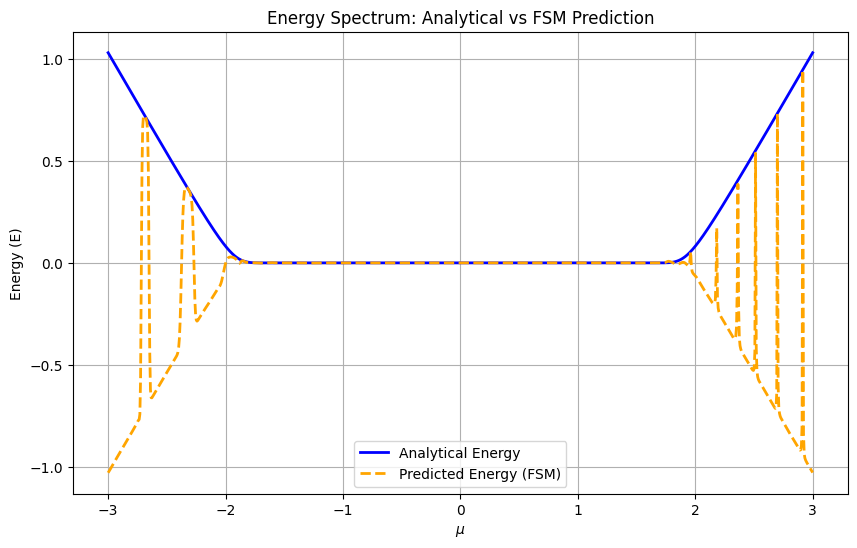

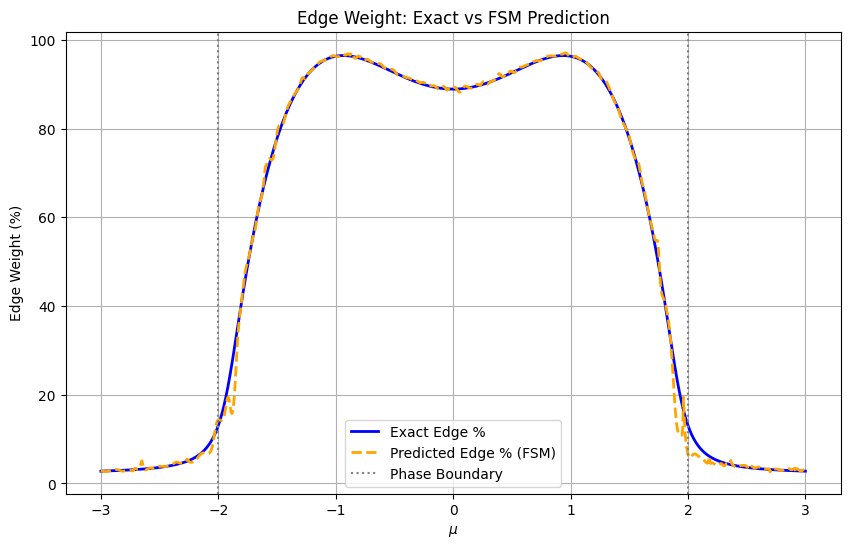

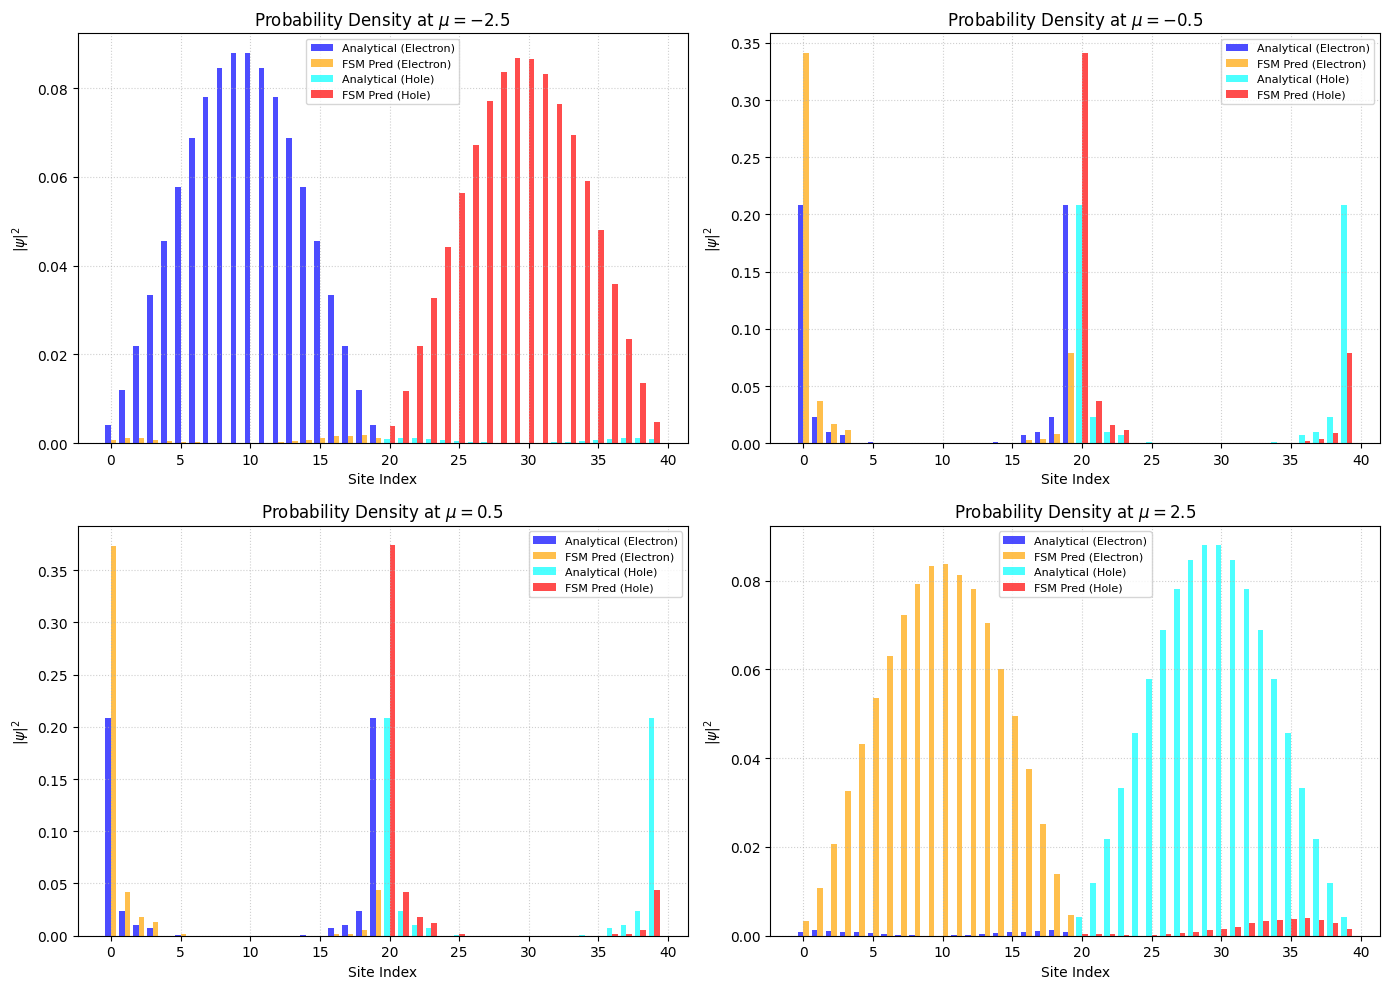

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- Folded Spectrum Model Plotting Suite ---
print("Generating plots for Folded Spectrum PINN...")

if 'model_fsm' not in globals() or 'X_tensor' not in globals():
    print("Error: FSM model or test data not found. Please run the training cells first.")
else:
    model_fsm.eval()
    X_full = X_tensor.to(device)
    E_full_exact = E_tensor.cpu().numpy().flatten()
    Psi_full_exact = Psi_tensor.cpu().numpy()
    mu_arr = X_full.cpu().numpy().flatten()

    with torch.no_grad():
        Psi_full_pred_fsm = model_fsm(X_full)
        # Enforce L2 norm just in case
        norms_fsm = torch.norm(Psi_full_pred_fsm, dim=1, keepdim=True)
        Psi_full_pred_fsm = Psi_full_pred_fsm / norms_fsm

        # Reconstruct Hamiltonian for the batch to get Rayleigh quotient (Energy)
        H_batch = H_base.unsqueeze(0) + X_full.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
        H_psi = torch.bmm(H_batch, Psi_full_pred_fsm.unsqueeze(-1)).squeeze(-1)
        E_full_pred_fsm = torch.sum(Psi_full_pred_fsm * H_psi, dim=1).cpu().numpy()

        Psi_full_pred_fsm = Psi_full_pred_fsm.cpu().numpy()

    # 1. Energy Distribution Comparison
    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, E_full_exact, label="Analytical Energy", color='blue', linewidth=2)
    plt.plot(mu_arr, E_full_pred_fsm, label="Predicted Energy (FSM)", color='orange', linestyle='--', linewidth=2)
    plt.title('Energy Spectrum: Analytical vs FSM Prediction')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Energy (E)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Edge Weight Comparison
    def calc_edge_prob(psi_arr):
        prob = np.abs(psi_arr)**2
        return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
                prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

    edge_exact = calc_edge_prob(Psi_full_exact)
    edge_pred_fsm = calc_edge_prob(Psi_full_pred_fsm)

    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, edge_exact, label="Exact Edge %", color='blue', linewidth=2)
    plt.plot(mu_arr, edge_pred_fsm, label="Predicted Edge % (FSM)", color='orange', linestyle='--', linewidth=2)
    plt.title('Edge Weight: Exact vs FSM Prediction')
    plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
    plt.axvline(2.0, color='gray', linestyle=':')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Edge Weight (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Probability Densities Comparison (Bar Charts)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    mu_samples = [-2.5, -0.5, 0.5, 2.5]

    for i, mu_val in enumerate(mu_samples):
        ax = axes.flatten()[i]
        idx = np.argmin(np.abs(mu_arr - mu_val))
        prob_exact = np.abs(Psi_full_exact[idx])**2
        prob_pred_fsm = np.abs(Psi_full_pred_fsm[idx])**2

        # Electron components
        ax.bar(np.arange(N) - 0.2, prob_exact[:N], width=0.4, label='Analytical (Electron)', color='blue', alpha=0.7)
        ax.bar(np.arange(N) + 0.2, prob_pred_fsm[:N], width=0.4, label='FSM Pred (Electron)', color='orange', alpha=0.7)

        # Hole components
        ax.bar(np.arange(N, 2*N) - 0.2, prob_exact[N:], width=0.4, label='Analytical (Hole)', color='cyan', alpha=0.7)
        ax.bar(np.arange(N, 2*N) + 0.2, prob_pred_fsm[N:], width=0.4, label='FSM Pred (Hole)', color='red', alpha=0.7)

        ax.set_title(fr'Probability Density at $\mu = {mu_val}$')
        ax.set_xlabel('Site Index')
        ax.set_ylabel(r'$|\psi|^2$')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

Pin !

In [ ]:
def train_pinned_spectrum(model_name, model, epochs=3000):
    print(f"\n--- Training {model_name} (FSM + Annealed Softplus Pinning) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()

        # 1. Anneal the pinning weight over time
        # Start at 1.0, decay to 0.01 by epoch 2000 to allow fine-tuning at the end
        if epoch < 2000:
            pin_weight = 1.0 - 0.99 * (epoch / 2000.0)
        else:
            pin_weight = 0.01

        for mu_batch, _, _ in train_loader:
            mu_batch = mu_batch.to(device)
            optimizer.zero_grad()

            # Forward pass: predict normalized wavefunction
            psi_pred = model(mu_batch)

            # Reconstruct Hamiltonian for the batch
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # FOLDED SPECTRUM LOSS: Minimize ||H * psi||^2
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            loss_fsm = torch.mean(H_psi**2)

            # Rayleigh Quotient for expected energy
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)

            # PINNING CONSTRAINT (Symmetry Breaking)
            # 2. Use a Smooth Penalty (Softplus) instead of ReLU
            # beta=10 keeps the curve sharp but differentiable near 0
            loss_pin = torch.mean(torch.nn.functional.softplus(-E_rayleigh, beta=10.0))

            # PH-symmetry constraint
            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + E_rayleigh * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            # Total loss: dynamically weighted pinning
            loss = loss_fsm + 0.1 * loss_ph + pin_weight * loss_pin

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | FSM: {loss_fsm.item():.6f} | Pin: {loss_pin.item():.6f} | PH: {loss_ph.item():.6f} | PinWt: {pin_weight:.3f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# Train the pinned model
seed_everything(42)
model_pinned = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
model_pinned = train_pinned_spectrum("Pinned FSM PINN", model_pinned, epochs=3000)

# Validation on probe points
print("\n=== Investigating Pinned FSM Model Convergence ===\n")
sample_mus = [-2.5, -0.5, 0.5, 2.5]

model_pinned.eval()
with torch.no_grad():
    for mu in sample_mus:
        print(f"--- Analysis for mu = {mu} ---")
        mu_tensor = torch.tensor([[mu]], dtype=torch.float32).to(device)
        psi_pred_tensor = model_pinned(mu_tensor)
        psi_pred = psi_pred_tensor.cpu().numpy().flatten()
        psi_pred = psi_pred / np.linalg.norm(psi_pred)

        H = build_hamiltonian(mu, N=N)
        evals, evecs = np.linalg.eigh(H)

        # Compute E_pred via Rayleigh quotient
        rayleigh_q = psi_pred.T @ H @ psi_pred
        e_pred = rayleigh_q

        diffs = np.abs(evals - e_pred)
        nearest_indices = np.argsort(diffs)[:5]

        print(f"Rayleigh E_pred: {e_pred:.6f}")
        print(f"5 Nearest Exact Eigenvalues:")
        for i, idx in enumerate(nearest_indices):
             print(f"  {i+1}. {evals[idx]:.6f} (diff: {diffs[idx]:.6f}, index: {idx})")

        res = np.linalg.norm(H @ psi_pred - e_pred * psi_pred)
        print(f"Residual ||H psi - E_pred psi||: {res:.6f}\n")


--- Training Pinned FSM PINN (FSM + Annealed Softplus Pinning) ---
Epoch 0500 | FSM: 0.008855 | Pin: 0.004251 | PH: 0.002570 | PinWt: 0.752
Epoch 1000 | FSM: 0.016733 | Pin: 0.000406 | PH: 0.003218 | PinWt: 0.505
Epoch 1500 | FSM: 0.007667 | Pin: 0.006939 | PH: 0.002893 | PinWt: 0.258
Epoch 2000 | FSM: 0.008862 | Pin: 0.033640 | PH: 0.000160 | PinWt: 0.010
Epoch 2500 | FSM: 0.005341 | Pin: 0.037452 | PH: 0.000703 | PinWt: 0.010
Epoch 3000 | FSM: 0.000347 | Pin: 0.053624 | PH: 0.000110 | PinWt: 0.010
Pinned FSM PINN Training complete in 174.54s.

=== Investigating Pinned FSM Model Convergence ===

--- Analysis for mu = -2.5 ---
Rayleigh E_pred: 0.537439
5 Nearest Exact Eigenvalues:
  1. 0.537911 (diff: 0.000472, index: 20)
  2. 0.643458 (diff: 0.106019, index: 21)
  3. 0.799653 (diff: 0.262214, index: 22)
  4. 0.991896 (diff: 0.454458, index: 23)
  5. 1.210956 (diff: 0.673517, index: 24)
Residual ||H psi - E_pred psi||: 0.039288

--- Analysis for mu = -0.5 ---
Rayleigh E_pred: 0.000268

Generating plots for Pinned FSM PINN...


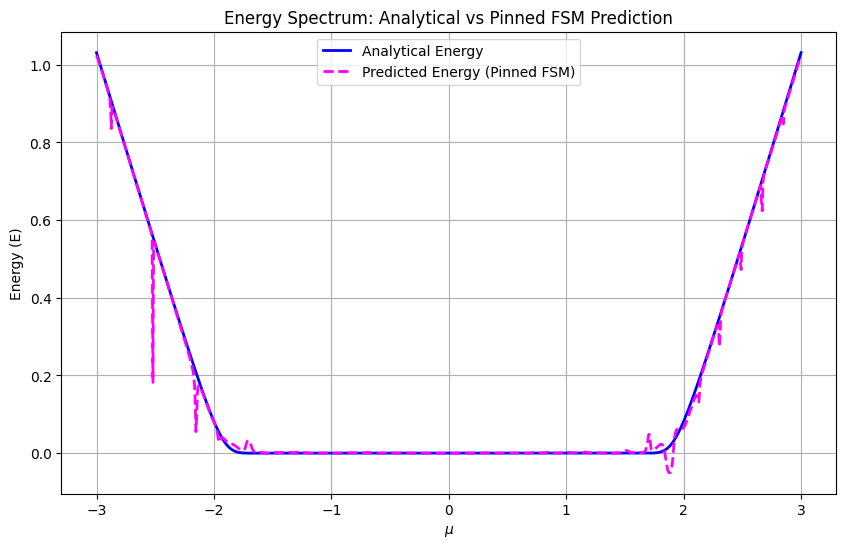

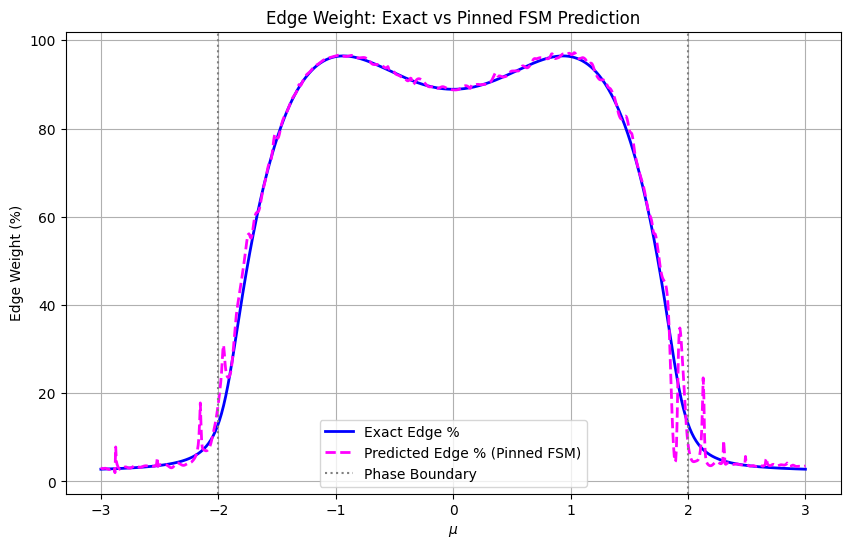

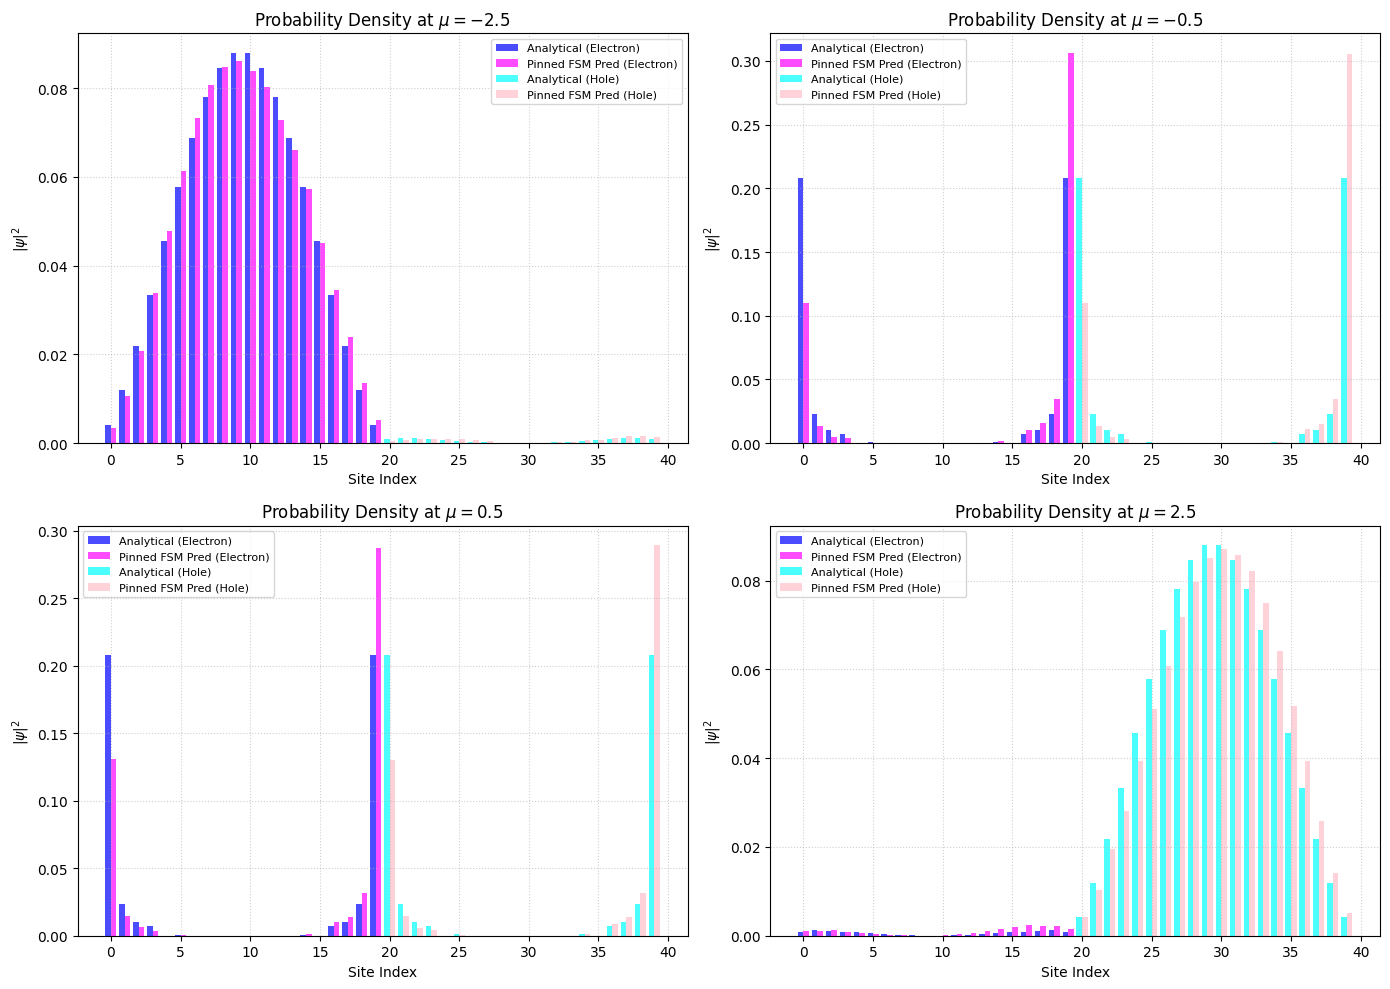

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- Pinned Model Plotting Suite ---
print("Generating plots for Pinned FSM PINN...")

if 'model_pinned' not in globals() or 'X_tensor' not in globals():
    print("Error: Pinned model or test data not found. Please run the training cells first.")
else:
    model_pinned.eval()
    X_full = X_tensor.to(device)
    E_full_exact = E_tensor.cpu().numpy().flatten()
    Psi_full_exact = Psi_tensor.cpu().numpy()
    mu_arr = X_full.cpu().numpy().flatten()

    with torch.no_grad():
        Psi_full_pred_pin = model_pinned(X_full)
        # Enforce L2 norm just in case
        norms_pin = torch.norm(Psi_full_pred_pin, dim=1, keepdim=True)
        Psi_full_pred_pin = Psi_full_pred_pin / norms_pin

        # Reconstruct Hamiltonian for the batch to get Rayleigh quotient (Energy)
        H_batch = H_base.unsqueeze(0) + X_full.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
        H_psi = torch.bmm(H_batch, Psi_full_pred_pin.unsqueeze(-1)).squeeze(-1)
        E_full_pred_pin = torch.sum(Psi_full_pred_pin * H_psi, dim=1).cpu().numpy()

        Psi_full_pred_pin = Psi_full_pred_pin.cpu().numpy()

    # 1. Energy Distribution Comparison
    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, E_full_exact, label="Analytical Energy", color='blue', linewidth=2)
    plt.plot(mu_arr, E_full_pred_pin, label="Predicted Energy (Pinned FSM)", color='magenta', linestyle='--', linewidth=2)
    plt.title('Energy Spectrum: Analytical vs Pinned FSM Prediction')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Energy (E)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Edge Weight Comparison
    def calc_edge_prob(psi_arr):
        prob = np.abs(psi_arr)**2
        return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
                prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

    edge_exact = calc_edge_prob(Psi_full_exact)
    edge_pred_pin = calc_edge_prob(Psi_full_pred_pin)

    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, edge_exact, label="Exact Edge %", color='blue', linewidth=2)
    plt.plot(mu_arr, edge_pred_pin, label="Predicted Edge % (Pinned FSM)", color='magenta', linestyle='--', linewidth=2)
    plt.title('Edge Weight: Exact vs Pinned FSM Prediction')
    plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
    plt.axvline(2.0, color='gray', linestyle=':')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Edge Weight (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Probability Densities Comparison (Bar Charts)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    mu_samples = [-2.5, -0.5, 0.5, 2.5]

    for i, mu_val in enumerate(mu_samples):
        ax = axes.flatten()[i]
        idx = np.argmin(np.abs(mu_arr - mu_val))
        prob_exact = np.abs(Psi_full_exact[idx])**2
        prob_pred_pin = np.abs(Psi_full_pred_pin[idx])**2

        # Electron components
        ax.bar(np.arange(N) - 0.2, prob_exact[:N], width=0.4, label='Analytical (Electron)', color='blue', alpha=0.7)
        ax.bar(np.arange(N) + 0.2, prob_pred_pin[:N], width=0.4, label='Pinned FSM Pred (Electron)', color='magenta', alpha=0.7)

        # Hole components
        ax.bar(np.arange(N, 2*N) - 0.2, prob_exact[N:], width=0.4, label='Analytical (Hole)', color='cyan', alpha=0.7)
        ax.bar(np.arange(N, 2*N) + 0.2, prob_pred_pin[N:], width=0.4, label='Pinned FSM Pred (Hole)', color='pink', alpha=0.7)

        ax.set_title(fr'Probability Density at $\mu = {mu_val}$')
        ax.set_xlabel('Site Index')
        ax.set_ylabel(r'$|\psi|^2$')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


### Importance Sampling around Phase Boundaries
Focusing dataset density around $\mu 	 \in [-2.2, -1.8]$ and $\mu \in [1.8, 2.2]$ to help the network resolve the topological transitions.

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

print("=== Generating Ultra-Dense Unsupervised Dataset ===")
# 1. Base uniform grid (5000 points)
mu_uniform = np.linspace(-3, 3, 5000)

# 2. Ultra-dense grids around the transitions (2500 points each)
mu_trans_left = np.linspace(-2.2, -1.8, 2500)
mu_trans_right = np.linspace(1.8, 2.2, 2500)

# Combine and sort for sequential gauge fixing
mu_train_dense = np.concatenate([mu_uniform, mu_trans_left, mu_trans_right])
mu_train_dense = np.sort(mu_train_dense)

dataset_mu_dense = []
dataset_E_dense = []
dataset_psi_dense = []
last_psi = None

for mu in mu_train_dense:
    H = build_hamiltonian(mu, N=N)
    evals, evecs = np.linalg.eigh(H)

    # Always pick the lowest positive energy state (index N)
    best_idx = N
    E = evals[best_idx]
    psi = evecs[:, best_idx]

    # Gauge fixing
    if last_psi is not None:
        if np.dot(psi, last_psi) < 0:
            psi = -psi
    last_psi = psi

    dataset_mu_dense.append([mu])
    dataset_E_dense.append([E])
    dataset_psi_dense.append(psi)

X_tensor_dense = torch.tensor(np.array(dataset_mu_dense), dtype=torch.float32)
E_tensor_dense = torch.tensor(np.array(dataset_E_dense), dtype=torch.float32)
Psi_tensor_dense = torch.tensor(np.array(dataset_psi_dense), dtype=torch.float32)

indices = np.random.permutation(len(X_tensor_dense))
train_idx, val_idx = indices[:-500], indices[-500:]

train_dataset_dense = TensorDataset(X_tensor_dense[train_idx], E_tensor_dense[train_idx], Psi_tensor_dense[train_idx])
val_dataset_dense = TensorDataset(X_tensor_dense[val_idx], E_tensor_dense[val_idx], Psi_tensor_dense[val_idx])

# Overwrite the global train_loader so the training function uses the new dense dataset
# Increased batch size to 256 to handle 10,000 points efficiently
train_loader = DataLoader(train_dataset_dense, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset_dense, batch_size=256, shuffle=False)

print(f"Ultra-Dense dataset created with {len(mu_train_dense)} points.")

=== Generating Ultra-Dense Unsupervised Dataset ===
Ultra-Dense dataset created with 10000 points.


In [ ]:
# Retrain the model with the dense dataset
seed_everything(42)
model_pinned_dense = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
model_pinned_dense = train_pinned_spectrum("Pinned FSM PINN (Dense Sampling)", model_pinned_dense, epochs=3000)


--- Training Pinned FSM PINN (Dense Sampling) (FSM + Annealed Softplus Pinning) ---
Epoch 0500 | FSM: 0.008024 | Pin: 0.002480 | PH: 0.002306 | PinWt: 0.752
Epoch 1000 | FSM: 0.011633 | Pin: 0.000814 | PH: 0.000260 | PinWt: 0.505
Epoch 1500 | FSM: 0.005200 | Pin: 0.006060 | PH: 0.001581 | PinWt: 0.258
Epoch 2000 | FSM: 0.006698 | Pin: 0.030602 | PH: 0.000374 | PinWt: 0.010
Epoch 2500 | FSM: 0.004152 | Pin: 0.035579 | PH: 0.000271 | PinWt: 0.010
Epoch 3000 | FSM: 0.000274 | Pin: 0.048438 | PH: 0.000082 | PinWt: 0.010
Pinned FSM PINN (Dense Sampling) Training complete in 175.40s.


Generating plots for Dense Pinned FSM...


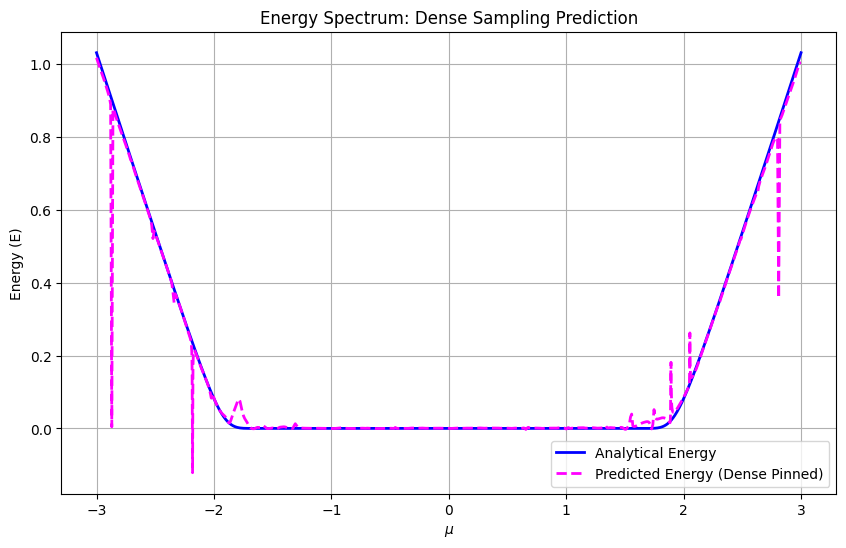

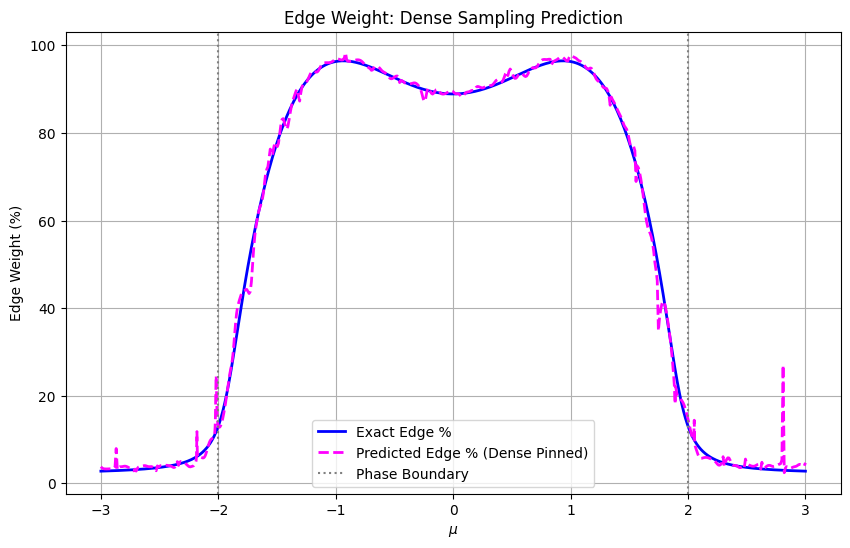

In [ ]:
import matplotlib.pyplot as plt

print("Generating plots for Dense Pinned FSM...")
model_pinned_dense.eval()

# We'll evaluate on the exact same full uniform grid to see if the spikes disappeared
X_full = X_tensor_dense.to(device)
mu_arr_dense = X_full.cpu().numpy().flatten()
E_full_exact_dense = E_tensor_dense.cpu().numpy().flatten()
Psi_full_exact_dense = Psi_tensor_dense.cpu().numpy()

with torch.no_grad():
    Psi_full_pred_dense = model_pinned_dense(X_full)
    norms_dense = torch.norm(Psi_full_pred_dense, dim=1, keepdim=True)
    Psi_full_pred_dense = Psi_full_pred_dense / norms_dense

    # Rayleigh quotient
    H_batch = H_base.unsqueeze(0) + X_full.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
    H_psi = torch.bmm(H_batch, Psi_full_pred_dense.unsqueeze(-1)).squeeze(-1)
    E_full_pred_dense = torch.sum(Psi_full_pred_dense * H_psi, dim=1).cpu().numpy()
    Psi_full_pred_dense = Psi_full_pred_dense.cpu().numpy()

# 1. Energy Distribution Comparison
plt.figure(figsize=(10, 6))
plt.plot(mu_arr_dense, E_full_exact_dense, label="Analytical Energy", color='blue', linewidth=2)
plt.plot(mu_arr_dense, E_full_pred_dense, label="Predicted Energy (Dense Pinned)", color='magenta', linestyle='--', linewidth=2)
plt.title('Energy Spectrum: Dense Sampling Prediction')
plt.xlabel(r'$\mu$')
plt.ylabel('Energy (E)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Edge Weight Comparison
def calc_edge_prob(psi_arr):
    prob = np.abs(psi_arr)**2
    return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
            prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

edge_exact_dense = calc_edge_prob(Psi_full_exact_dense)
edge_pred_dense = calc_edge_prob(Psi_full_pred_dense)

plt.figure(figsize=(10, 6))
plt.plot(mu_arr_dense, edge_exact_dense, label="Exact Edge %", color='blue', linewidth=2)
plt.plot(mu_arr_dense, edge_pred_dense, label="Predicted Edge % (Dense Pinned)", color='magenta', linestyle='--', linewidth=2)
plt.title('Edge Weight: Dense Sampling Prediction')
plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
plt.axvline(2.0, color='gray', linestyle=':')
plt.xlabel(r'$\mu$')
plt.ylabel('Edge Weight (%)')
plt.legend()
plt.grid(True)
plt.show()

### Residual-Based Adaptive Refinement (RAR)
Instead of manually defining an ultra-dense grid around the phase transitions, we let the network decide where it needs more data. We start with a sparse uniform grid and periodically sample points from a massive pool that have the highest physics loss.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from torch.utils.data import DataLoader, TensorDataset

def train_hybrid_pinned_fsm(model, base_mu, pool_mu, initial_epochs=2000, num_iterations=5, epochs_per_iter=200, points_per_iter=500):
    print(f"\n--- Training with Hybrid RAR (Persistent Uniform Baseline + Adaptive Refinement) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)

    # We'll accumulate only the adaptively sampled hard points here
    adaptive_mu = torch.empty((0, 1), dtype=torch.float32)
    base_size = len(base_mu)
    start_time = time.time()

    total_epochs = initial_epochs + num_iterations * epochs_per_iter
    current_global_epoch = 0

    # Initialize the scheduler once for the entire training process
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

    # ==========================================
    # PHASE 1: Pre-training on Dense Baseline
    # ==========================================
    print(f"\n=== Phase 1: Global Structure Pre-training ({initial_epochs} epochs, Baseline size: {base_size}) ===")

    for epoch in range(1, initial_epochs + 1):
        model.train()
        current_global_epoch += 1

        # Global progress for pinning weight
        pin_weight = max(0.01, 1.0 - 0.99 * (current_global_epoch / total_epochs))

        # PERSISTENT BASELINE: Generate a fresh uniform grid every epoch to prevent overfitting
        fresh_baseline = (torch.rand(base_size) * 6 - 3).unsqueeze(1).float()
        train_loader = DataLoader(TensorDataset(fresh_baseline), batch_size=256, shuffle=True)

        for (mu_batch,) in train_loader:
            mu_batch = mu_batch.to(device)
            optimizer.zero_grad()

            psi_pred = model(mu_batch)
            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # FSM Loss
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            loss_fsm = torch.mean(H_psi**2)

            # Pinning
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
            loss_pin = torch.mean(torch.nn.functional.softplus(-E_rayleigh, beta=10.0))

            # PH Symmetry
            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + E_rayleigh * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            loss = loss_fsm + 0.1 * loss_ph + pin_weight * loss_pin
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        if epoch % 500 == 0:
             print(f"  Epoch {epoch:04d} | FSM: {loss_fsm.item():.6f} | Pin: {loss_pin.item():.6f} | PinWt: {pin_weight:.3f}")

    # ==========================================
    # PHASE 2: Residual-Based Adaptive Refinement
    # ==========================================
    for iteration in range(num_iterations):
        # 1. Adaptive Sampling: Evaluate the pool and pick the hardest points
        model.eval()
        with torch.no_grad():
            pool_loader = DataLoader(TensorDataset(pool_mu), batch_size=512, shuffle=False)
            all_residuals = []

            for (mu_batch,) in pool_loader:
                mu_batch = mu_batch.to(device)
                psi_pred = model(mu_batch)
                H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

                # True eigenvalue residual (variance)
                H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
                E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
                res = torch.sum((H_psi - E_rayleigh * psi_pred)**2, dim=1)

                # Add the pinning penalty to the sampling metric
                pin_penalty = torch.nn.functional.softplus(-E_rayleigh.squeeze(-1), beta=10.0)
                combined_metric = res + pin_penalty

                all_residuals.append(combined_metric)

            all_residuals = torch.cat(all_residuals)

            # Use Importance Sampling (Proportional) to sample points
            probs = all_residuals / torch.sum(all_residuals)
            top_indices = torch.multinomial(probs, points_per_iter, replacement=False)

            # Accumulate ONLY the new adaptive points
            new_points = pool_mu[top_indices.cpu()].cpu()
            adaptive_mu = torch.cat([adaptive_mu, new_points], dim=0)

        print(f"\n=== Phase 2: RAR Iteration {iteration+1}/{num_iterations} (Adaptive points accumulated: {len(adaptive_mu)}) ===")

        # 2. Train on the fresh baseline combined with ALL accumulated adaptive points
        for epoch in range(1, epochs_per_iter + 1):
            model.train()
            current_global_epoch += 1
            pin_weight = max(0.01, 1.0 - 0.99 * (current_global_epoch / total_epochs))

            # PERSISTENT BASELINE: Mix fresh uniform points with our accumulated hard points
            fresh_baseline = (torch.rand(base_size) * 6 - 3).unsqueeze(1).float()
            current_epoch_data = torch.cat([fresh_baseline, adaptive_mu], dim=0)

            train_loader = DataLoader(TensorDataset(current_epoch_data), batch_size=256, shuffle=True)

            for (mu_batch,) in train_loader:
                mu_batch = mu_batch.to(device)
                optimizer.zero_grad()

                psi_pred = model(mu_batch)
                H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

                H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
                loss_fsm = torch.mean(H_psi**2)

                E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
                loss_pin = torch.mean(torch.nn.functional.softplus(-E_rayleigh, beta=10.0))

                Xi_psi = torch.matmul(psi_pred, Xi.T)
                H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
                PH_res = H_Xi_psi + E_rayleigh * Xi_psi
                loss_ph = torch.mean(PH_res**2)

                loss = loss_fsm + 0.1 * loss_ph + pin_weight * loss_pin
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()

            if epoch % 100 == 0:
                 print(f"  Epoch {epoch:04d} | FSM: {loss_fsm.item():.6f} | Pin: {loss_pin.item():.6f} | PinWt: {pin_weight:.3f}")

    print(f"\nHybrid Training complete in {(time.time() - start_time):.2f}s.")

    # Return a final merged dataset for plotting the histogram
    final_dataset = torch.cat([(torch.rand(base_size) * 6 - 3).unsqueeze(1).float(), adaptive_mu], dim=0)
    return model, final_dataset

# 1. Base dense random grid (5,000 points)
mu_base_hybrid = (torch.rand(5000) * 6 - 3).unsqueeze(1).float()

# 2. Massive pool to sample from (50,000 points)
pool_mu_adapt = torch.linspace(-3, 3, 50000).unsqueeze(1).float()

seed_everything(42)
model_adaptive = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
model_adaptive, final_mu_train = train_hybrid_pinned_fsm(
    model_adaptive, mu_base_hybrid, pool_mu_adapt,
    initial_epochs=2000, num_iterations=5, epochs_per_iter=200, points_per_iter=500
)



--- Training with Hybrid RAR (Persistent Uniform Baseline + Adaptive Refinement) ---

=== Phase 1: Global Structure Pre-training (2000 epochs, Baseline size: 5000) ===
  Epoch 0500 | FSM: 0.007774 | Pin: 0.002242 | PinWt: 0.835
  Epoch 1000 | FSM: 0.007291 | Pin: 0.002466 | PinWt: 0.670
  Epoch 1500 | FSM: 0.007711 | Pin: 0.003291 | PinWt: 0.505
  Epoch 2000 | FSM: 0.006176 | Pin: 0.005119 | PinWt: 0.340

=== Phase 2: RAR Iteration 1/5 (Adaptive points accumulated: 500) ===
  Epoch 0100 | FSM: 0.007194 | Pin: 0.004606 | PinWt: 0.307
  Epoch 0200 | FSM: 0.006885 | Pin: 0.005732 | PinWt: 0.274

=== Phase 2: RAR Iteration 2/5 (Adaptive points accumulated: 1000) ===
  Epoch 0100 | FSM: 0.005665 | Pin: 0.007082 | PinWt: 0.241
  Epoch 0200 | FSM: 0.005712 | Pin: 0.007771 | PinWt: 0.208

=== Phase 2: RAR Iteration 3/5 (Adaptive points accumulated: 1500) ===
  Epoch 0100 | FSM: 0.005389 | Pin: 0.010292 | PinWt: 0.175
  Epoch 0200 | FSM: 0.005505 | Pin: 0.011615 | PinWt: 0.142

=== Phase 2: RA

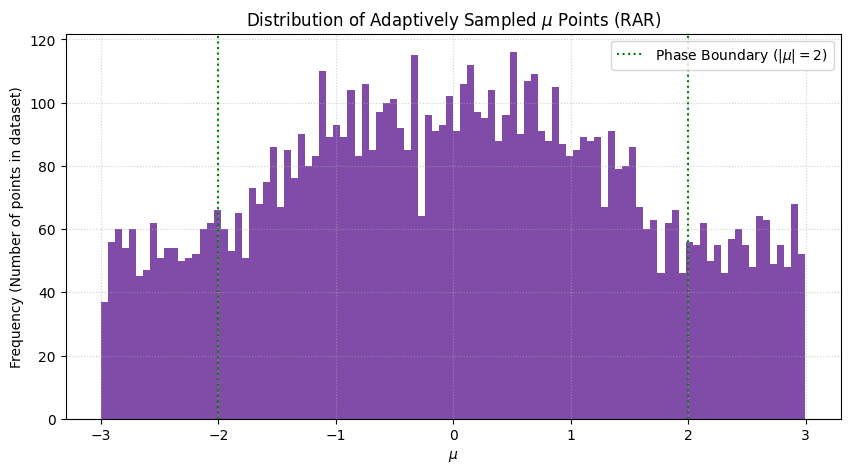

Total final training points: 7500
Notice how the network automatically discovered and clustered points around the phase boundaries (|mu| ~ 2.0)!


In [ ]:
import matplotlib.pyplot as plt

# Plot the histogram of adaptively sampled points
final_mu_np = final_mu_train.numpy().flatten()

plt.figure(figsize=(10, 5))
plt.hist(final_mu_np, bins=100, color='indigo', alpha=0.7)
plt.title(r'Distribution of Adaptively Sampled $\mu$ Points (RAR)')
plt.xlabel(r'$\mu$')
plt.ylabel('Frequency (Number of points in dataset)')
plt.axvline(-2, color='green', linestyle=':', label=r'Phase Boundary ($|\mu|=2$)')
plt.axvline(2, color='green', linestyle=':')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Total final training points: {len(final_mu_np)}")
print("Notice how the network automatically discovered and clustered points around the phase boundaries (|mu| ~ 2.0)!")


Generating plots for Adaptive/Hybrid PINN...


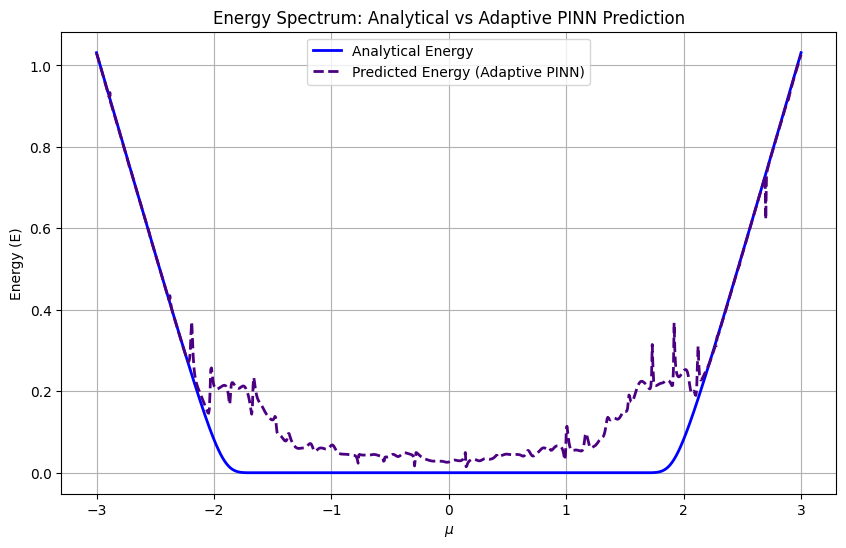

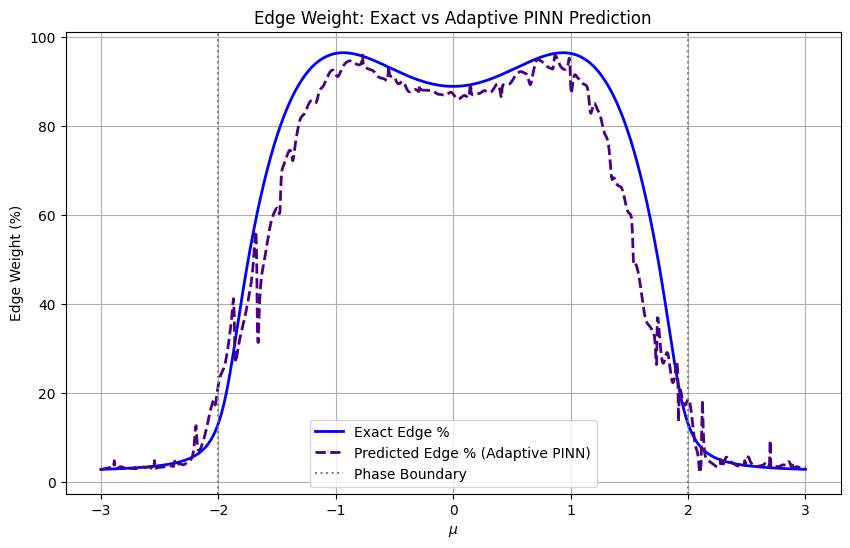

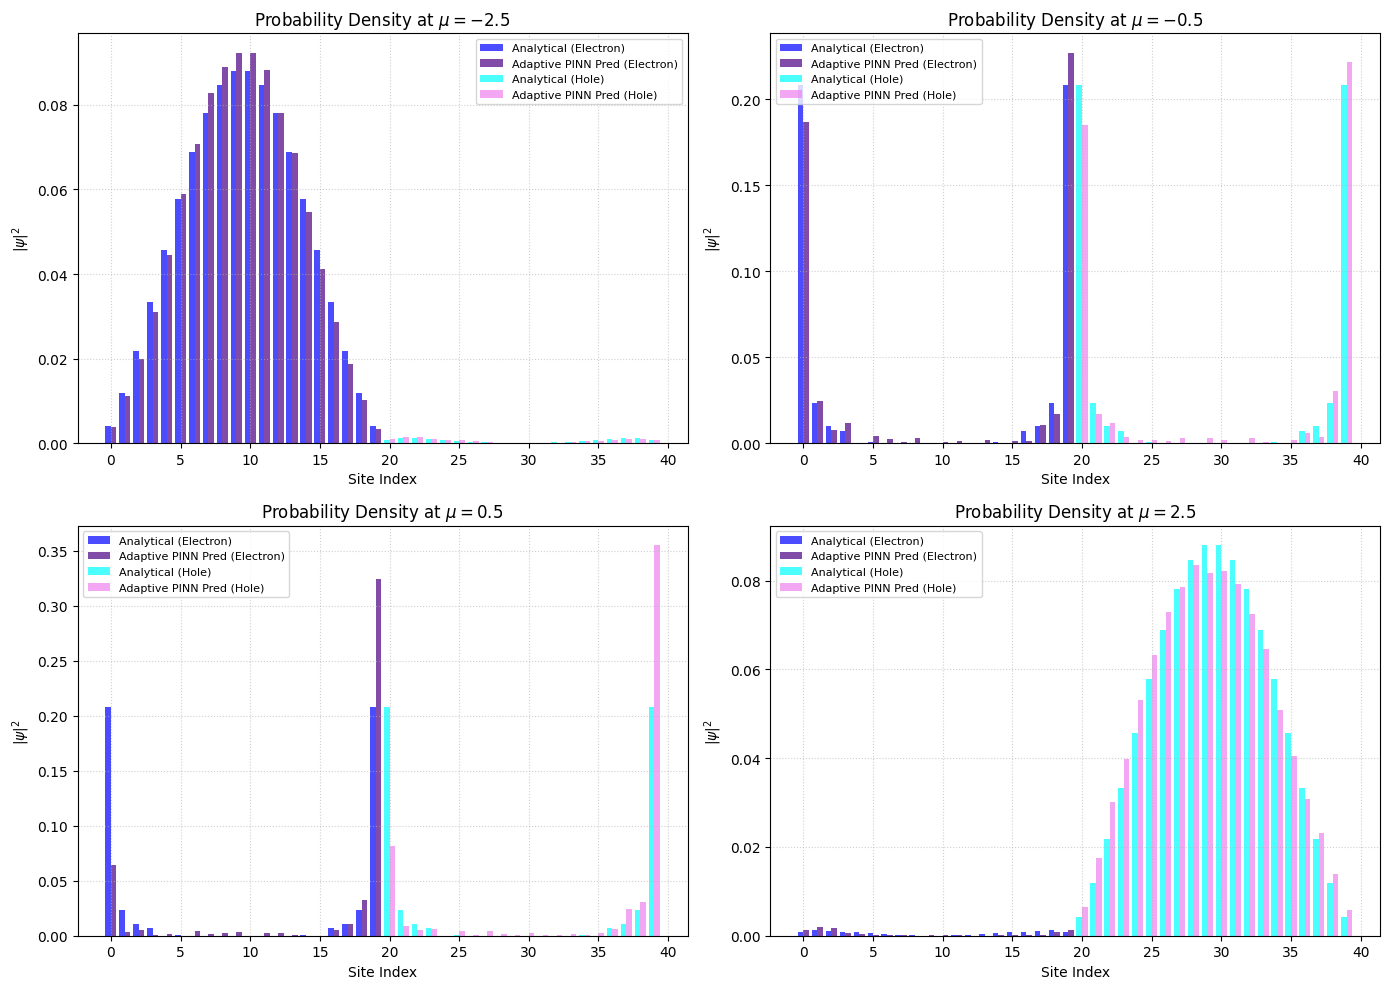

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- Adaptive Model Plotting Suite ---
print("Generating plots for Adaptive/Hybrid PINN...")

if 'model_adaptive' not in globals() or 'X_tensor' not in globals():
    print("Error: Adaptive model or test data not found. Please run the training cells first.")
else:
    model_adaptive.eval()
    X_full = X_tensor.to(device)
    E_full_exact = E_tensor.cpu().numpy().flatten()
    Psi_full_exact = Psi_tensor.cpu().numpy()
    mu_arr = X_full.cpu().numpy().flatten()

    with torch.no_grad():
        Psi_full_pred_adapt = model_adaptive(X_full)
        # Enforce L2 norm
        norms_adapt = torch.norm(Psi_full_pred_adapt, dim=1, keepdim=True)
        Psi_full_pred_adapt = Psi_full_pred_adapt / norms_adapt

        # Reconstruct Hamiltonian for the batch to get Rayleigh quotient (Energy)
        H_batch = H_base.unsqueeze(0) + X_full.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
        H_psi = torch.bmm(H_batch, Psi_full_pred_adapt.unsqueeze(-1)).squeeze(-1)
        E_full_pred_adapt = torch.sum(Psi_full_pred_adapt * H_psi, dim=1).cpu().numpy()

        Psi_full_pred_adapt = Psi_full_pred_adapt.cpu().numpy()

    # 1. Energy Distribution Comparison
    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, E_full_exact, label="Analytical Energy", color='blue', linewidth=2)
    plt.plot(mu_arr, E_full_pred_adapt, label="Predicted Energy (Adaptive PINN)", color='indigo', linestyle='--', linewidth=2)
    plt.title('Energy Spectrum: Analytical vs Adaptive PINN Prediction')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Energy (E)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Edge Weight Comparison
    def calc_edge_prob(psi_arr):
        prob = np.abs(psi_arr)**2
        return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
                prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

    edge_exact = calc_edge_prob(Psi_full_exact)
    edge_pred_adapt = calc_edge_prob(Psi_full_pred_adapt)

    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, edge_exact, label="Exact Edge %", color='blue', linewidth=2)
    plt.plot(mu_arr, edge_pred_adapt, label="Predicted Edge % (Adaptive PINN)", color='indigo', linestyle='--', linewidth=2)
    plt.title('Edge Weight: Exact vs Adaptive PINN Prediction')
    plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
    plt.axvline(2.0, color='gray', linestyle=':')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Edge Weight (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Probability Densities Comparison (Bar Charts)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    mu_samples = [-2.5, -0.5, 0.5, 2.5]

    for i, mu_val in enumerate(mu_samples):
        ax = axes.flatten()[i]
        idx = np.argmin(np.abs(mu_arr - mu_val))
        prob_exact = np.abs(Psi_full_exact[idx])**2
        prob_pred_adapt = np.abs(Psi_full_pred_adapt[idx])**2

        # Electron components
        ax.bar(np.arange(N) - 0.2, prob_exact[:N], width=0.4, label='Analytical (Electron)', color='blue', alpha=0.7)
        ax.bar(np.arange(N) + 0.2, prob_pred_adapt[:N], width=0.4, label='Adaptive PINN Pred (Electron)', color='indigo', alpha=0.7)

        # Hole components
        ax.bar(np.arange(N, 2*N) - 0.2, prob_exact[N:], width=0.4, label='Analytical (Hole)', color='cyan', alpha=0.7)
        ax.bar(np.arange(N, 2*N) + 0.2, prob_pred_adapt[N:], width=0.4, label='Adaptive PINN Pred (Hole)', color='violet', alpha=0.7)

        ax.set_title(fr'Probability Density at $\mu = {mu_val}$')
        ax.set_xlabel('Site Index')
        ax.set_ylabel(r'$|\psi|^2$')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


### Infinite Continuous Random Sampling (Massive Pinned FSM)
Training the network by generating fresh random $\mu$ points directly on the GPU at every step.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time

def train_pinned_spectrum_continuous(model_name, model, epochs=3000, batch_size=4096, batches_per_epoch=20):
    print(f"\n--- Training {model_name} (Continuous Random Sampling + Variance Penalty) ---")
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()

        # Anneal pinning weight over the first 60% of epochs (1800 epochs)
        anneal_duration = int(epochs * 0.6)
        if epoch < anneal_duration:
            pin_weight = 1.0 - 0.99 * (epoch / anneal_duration)
        else:
            pin_weight = 0.01

        epoch_fsm, epoch_var, epoch_pin, epoch_ph = 0.0, 0.0, 0.0, 0.0

        for _ in range(batches_per_epoch):
            # 1. Generate massive random mu batch on the fly on the GPU
            # 50% uniform global, 25% left transition, 25% right transition
            mu_uni = torch.rand(batch_size // 2, 1, device=device) * 6 - 3
            mu_trans_l = (torch.rand(batch_size // 4, 1, device=device) * 0.4) - 2.2
            mu_trans_r = (torch.rand(batch_size // 4, 1, device=device) * 0.4) + 1.8
            mu_batch = torch.cat([mu_uni, mu_trans_l, mu_trans_r], dim=0)

            optimizer.zero_grad()
            psi_pred = model(mu_batch)

            H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

            # FSM Loss
            H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
            loss_fsm = torch.mean(H_psi**2)

            # Rayleigh quotient
            E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)

            # Local Energy Variance Penalty (NEW)
            loss_var = torch.mean((H_psi - E_rayleigh * psi_pred)**2)

            # Softplus Pinning Constraint
            loss_pin = torch.mean(torch.nn.functional.softplus(-E_rayleigh, beta=10.0))

            # Particle-Hole Symmetry Constraint
            Xi_psi = torch.matmul(psi_pred, Xi.T)
            H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
            PH_res = H_Xi_psi + E_rayleigh * Xi_psi
            loss_ph = torch.mean(PH_res**2)

            # Total Dynamic Loss (added loss_var)
            loss = loss_fsm + loss_var + 0.1 * loss_ph + pin_weight * loss_pin
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_fsm += loss_fsm.item()
            epoch_var += loss_var.item()
            epoch_pin += loss_pin.item()
            epoch_ph += loss_ph.item()

        scheduler.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | FSM: {epoch_fsm/batches_per_epoch:.6f} | Var: {epoch_var/batches_per_epoch:.6f} | Pin: {epoch_pin/batches_per_epoch:.6f} | PinWt: {pin_weight:.3f}")

    print(f"{model_name} Training complete in {(time.time() - start_time):.2f}s.")
    return model

# Execute with massive data coverage
seed_everything(42)
model_massive_pin = SirenPINN_ShiftInvert(hidden_features=32, hidden_layers=2)
# Points seen: 3000 epochs * 20 batches * 4096 size = 245.7 million points evaluated
model_massive_pin = train_pinned_spectrum_continuous("Massive Pinned FSM", model_massive_pin, epochs=3000, batch_size=4096, batches_per_epoch=20)



--- Training Massive Pinned FSM (Continuous Random Sampling + Variance Penalty) ---
Epoch 0500 | FSM: 0.006058 | Var: 0.001255 | Pin: 0.002625 | PinWt: 0.725
Epoch 1000 | FSM: 0.005287 | Var: 0.001106 | Pin: 0.003969 | PinWt: 0.450
Epoch 1500 | FSM: 0.003616 | Var: 0.000664 | Pin: 0.010611 | PinWt: 0.175
Epoch 2000 | FSM: 0.001871 | Var: 0.000085 | Pin: 0.039645 | PinWt: 0.010
Epoch 2500 | FSM: 0.001771 | Var: 0.000038 | Pin: 0.041609 | PinWt: 0.010
Epoch 3000 | FSM: 0.001794 | Var: 0.000028 | Pin: 0.041911 | PinWt: 0.010
Massive Pinned FSM Training complete in 234.43s.


Generating plots for Massive Pinned FSM...


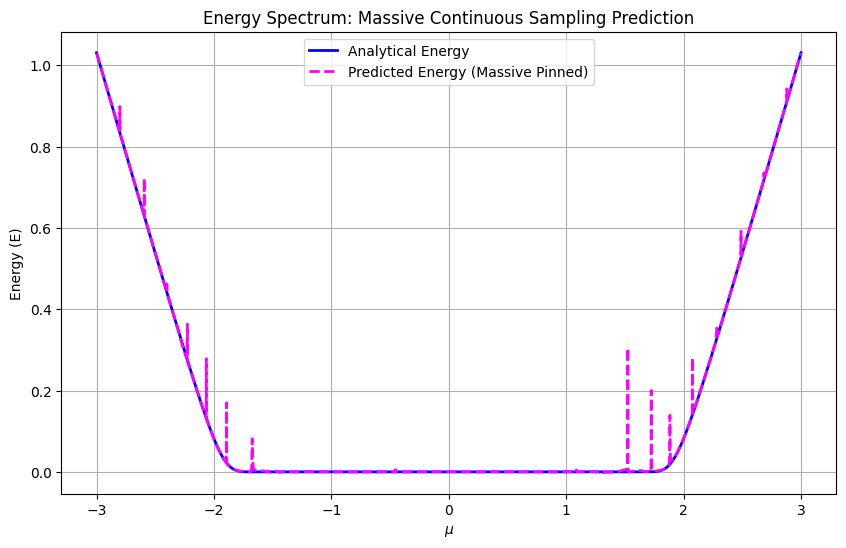

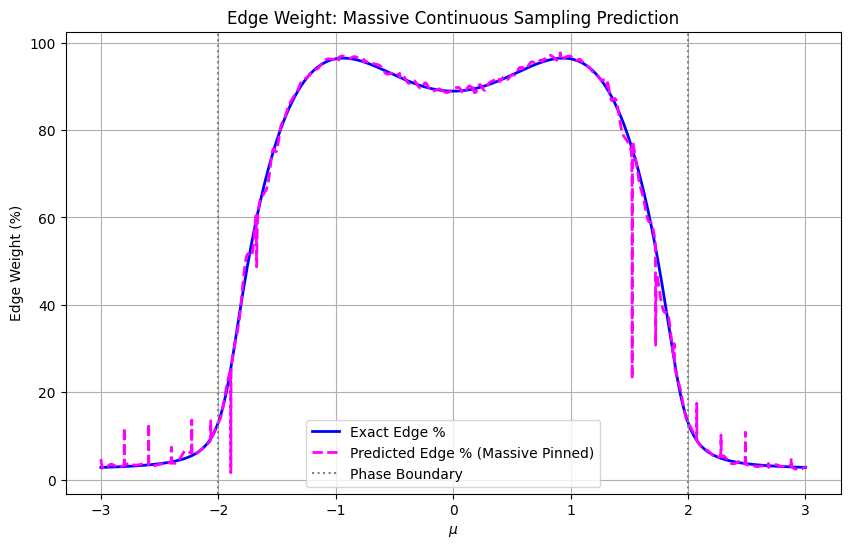

In [ ]:
import matplotlib.pyplot as plt

print("Generating plots for Massive Pinned FSM...")
model_massive_pin.eval()

# Validate against the previously created dense exact grid (10,000 points)
X_full = X_tensor_dense.to(device)
mu_arr_massive = X_full.cpu().numpy().flatten()
E_full_exact_massive = E_tensor_dense.cpu().numpy().flatten()
Psi_full_exact_massive = Psi_tensor_dense.cpu().numpy()

with torch.no_grad():
    Psi_full_pred_massive = model_massive_pin(X_full)
    norms_massive = torch.norm(Psi_full_pred_massive, dim=1, keepdim=True)
    Psi_full_pred_massive = Psi_full_pred_massive / norms_massive

    # Rayleigh quotient for predicted energy
    H_batch = H_base.unsqueeze(0) + X_full.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
    H_psi = torch.bmm(H_batch, Psi_full_pred_massive.unsqueeze(-1)).squeeze(-1)
    E_full_pred_massive = torch.sum(Psi_full_pred_massive * H_psi, dim=1).cpu().numpy()
    Psi_full_pred_massive = Psi_full_pred_massive.cpu().numpy()

# 1. Energy Distribution Comparison
plt.figure(figsize=(10, 6))
plt.plot(mu_arr_massive, E_full_exact_massive, label="Analytical Energy", color='blue', linewidth=2)
plt.plot(mu_arr_massive, E_full_pred_massive, label="Predicted Energy (Massive Pinned)", color='magenta', linestyle='--', linewidth=2)
plt.title('Energy Spectrum: Massive Continuous Sampling Prediction')
plt.xlabel(r'$\mu$')
plt.ylabel('Energy (E)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Edge Weight Comparison
def calc_edge_prob(psi_arr):
    prob = np.abs(psi_arr)**2
    return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
            prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

edge_exact_massive = calc_edge_prob(Psi_full_exact_massive)
edge_pred_massive = calc_edge_prob(Psi_full_pred_massive)

plt.figure(figsize=(10, 6))
plt.plot(mu_arr_massive, edge_exact_massive, label="Exact Edge %", color='blue', linewidth=2)
plt.plot(mu_arr_massive, edge_pred_massive, label="Predicted Edge % (Massive Pinned)", color='magenta', linestyle='--', linewidth=2)
plt.title('Edge Weight: Massive Continuous Sampling Prediction')
plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
plt.axvline(2.0, color='gray', linestyle=':')
plt.xlabel(r'$\mu$')
plt.ylabel('Edge Weight (%)')
plt.legend()
plt.grid(True)
plt.show()

## Unification

In [8]:
import sys
import sympy
import sympy.printing.str
import sympy.core
import sympy.core.symbol

# Explicitly attach the printing and core modules to sympy
setattr(sympy, 'printing', sys.modules['sympy.printing'])
setattr(sympy, 'core', sys.modules['sympy.core'])
sympy.printing.StrPrinter = sympy.printing.str.StrPrinter


In [ ]:
class SirenPINN_ShiftInvert(nn.Module):
    def __init__(self, in_features=1, hidden_features=32, hidden_layers=2):
        super().__init__()
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, is_first=True, omega_0=30.0))
        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*self.net)

        self.psi_head = nn.Linear(hidden_features, 40)

        bound = np.sqrt(6 / hidden_features) / 2.0
        with torch.no_grad():
            self.psi_head.weight.uniform_(-bound, bound)

    def forward(self, x):
        features = self.net(x)
        Psi_pred = self.psi_head(features)
        # Explicit L2 norm constraint on Psi
        Psi_pred = Psi_pred / torch.norm(Psi_pred, dim=1, keepdim=True)
        return Psi_pred


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
import copy

# ==========================================
# 0. Dependencies and Constants Setup
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N = 20

H_base = torch.zeros((2*N, 2*N), dtype=torch.float32, device=device)
t_hop = 1.0
delta_pair = 0.5
for i in range(N-1):
    H_base[i, i+1] = H_base[i+1, i] = -t_hop
    H_base[N+i, N+i+1] = H_base[N+i+1, N+i] = +t_hop
    H_base[i, N+i+1] = +delta_pair
    H_base[N+i+1, i] = +delta_pair
    H_base[i+1, N+i] = -delta_pair
    H_base[N+i, i+1] = -delta_pair

H_mu_diag = torch.zeros((2*N,), dtype=torch.float32, device=device)
H_mu_diag[:N] = -1.0
H_mu_diag[N:] = 1.0
H_mu_diag = torch.diag(H_mu_diag)

Xi = torch.zeros((40, 40), dtype=torch.float32, device=device)
Xi[:20, 20:] = torch.eye(20, device=device)
Xi[20:, :20] = torch.eye(20, device=device)

# ==========================================
# 1. Loss Function Definitions
# ==========================================
class BaseLoss:
    def __call__(self, model, mu_batch, H_base, H_mu_diag, Xi):
        raise NotImplementedError

class PinnedFSMLoss(BaseLoss):
    def __init__(self, current_epoch=0, total_epochs=3000, anneal_duration=2000):
        self.current_epoch = current_epoch
        self.total_epochs = total_epochs
        self.anneal_duration = anneal_duration

    def __call__(self, model, mu_batch, H_base, H_mu_diag, Xi):
        if self.current_epoch < self.anneal_duration:
            pin_weight = 1.0 - 0.99 * (self.current_epoch / self.anneal_duration)
        else:
            pin_weight = 0.01

        psi_pred = model(mu_batch)
        H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

        H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
        loss_fsm = torch.mean(H_psi**2)

        E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
        loss_pin = torch.mean(torch.nn.functional.softplus(-E_rayleigh, beta=10.0))
        loss_var = torch.mean((H_psi - E_rayleigh * psi_pred)**2)

        Xi_psi = torch.matmul(psi_pred, Xi.T)
        H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
        PH_res = H_Xi_psi + E_rayleigh * Xi_psi
        loss_ph = torch.mean(PH_res**2)

        total_loss = loss_fsm + loss_var + 0.1 * loss_ph + pin_weight * loss_pin

        return total_loss, {
            'fsm': loss_fsm.item(),
            'var': loss_var.item(),
            'pin': loss_pin.item(),
            'ph': loss_ph.item(),
            'pin_wt': pin_weight
        }

# ==========================================
# 2. Unified Trainer Class (with L-BFGS & Closure Support)
# ==========================================
class UnifiedTrainer:
    def __init__(self, model, loss_fn, optimizer_class=optim.AdamW, optimizer_kwargs=None,
                 scheduler_class=optim.lr_scheduler.CosineAnnealingLR, scheduler_kwargs=None,
                 device='cuda'):
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)
        self.loss_fn = loss_fn
        self.history = {} # Track metrics over epochs

        if optimizer_kwargs is None:
            optimizer_kwargs = {'lr': 8e-4, 'weight_decay': 1e-6}
        self.optimizer = optimizer_class(self.model.parameters(), **optimizer_kwargs)

        if scheduler_kwargs is None:
            scheduler_kwargs = {'T_max': 3000}
        self.scheduler = scheduler_class(self.optimizer, **scheduler_kwargs) if scheduler_class else None

    def train(self, data_loader, H_base, H_mu_diag, Xi, epochs=3000, print_freq=500, val_loader=None, patience=None):
        print(f"\n--- Starting Unified Training ({self.loss_fn.__class__.__name__}) ---")
        start_time = time.time()

        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0

        for epoch in range(1, epochs + 1):
            self.model.train()
            if hasattr(self.loss_fn, 'current_epoch'):
                self.loss_fn.current_epoch = epoch

            epoch_metrics = {}
            num_batches = 0
            train_loss_total = 0.0

            for batch in data_loader:
                mu_batch = batch[0].to(self.device)

                if isinstance(self.optimizer, optim.LBFGS):
                    def closure():
                        self.optimizer.zero_grad()
                        c_loss, _ = self.loss_fn(self.model, mu_batch, H_base, H_mu_diag, Xi)
                        c_loss.backward()
                        return c_loss

                    self.optimizer.step(closure)

                    # Evaluate once more for logging metrics after step
                    with torch.no_grad():
                        loss, metrics = self.loss_fn(self.model, mu_batch, H_base, H_mu_diag, Xi)
                else:
                    self.optimizer.zero_grad()
                    loss, metrics = self.loss_fn(self.model, mu_batch, H_base, H_mu_diag, Xi)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()

                train_loss_total += loss.item()
                for k, v in metrics.items():
                    epoch_metrics[f'train_{k}'] = epoch_metrics.get(f'train_{k}', 0.0) + v
                num_batches += 1

            if self.scheduler:
                self.scheduler.step()

            # Save training averages to history
            for k, v in epoch_metrics.items():
                if k not in self.history:
                    self.history[k] = []
                self.history[k].append(v / num_batches)
            if 'train_loss' not in self.history: self.history['train_loss'] = []
            self.history['train_loss'].append(train_loss_total / num_batches)

            # Validation loop & Checkpointing
            val_loss_avg = None
            if val_loader is not None:
                self.model.eval()
                val_metrics = {}
                val_batches = 0
                val_loss_total = 0.0
                with torch.no_grad():
                     for batch in val_loader:
                         mu_batch = batch[0].to(self.device)
                         v_loss, metrics = self.loss_fn(self.model, mu_batch, H_base, H_mu_diag, Xi)
                         val_loss_total += v_loss.item()
                         for k, v in metrics.items():
                              val_metrics[f'val_{k}'] = val_metrics.get(f'val_{k}', 0.0) + v
                         val_batches += 1

                val_loss_avg = val_loss_total / val_batches
                for k, v in val_metrics.items():
                    if k not in self.history:
                        self.history[k] = []
                    self.history[k].append(v / val_batches)
                if 'val_loss' not in self.history: self.history['val_loss'] = []
                self.history['val_loss'].append(val_loss_avg)

                # Checkpoint best model
                if val_loss_avg < best_val_loss:
                    best_val_loss = val_loss_avg
                    best_model_state = copy.deepcopy(self.model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1

            if epoch % print_freq == 0:
                metrics_str = " | ".join([f"{k.replace('train_', '')}: {v/num_batches:.6f}" for k, v in epoch_metrics.items() if not k.endswith('pin_wt')])
                if val_loader:
                     val_str = " | ".join([f"{k}: {v/val_batches:.6f}" for k, v in val_metrics.items() if not k.endswith('pin_wt')])
                     metrics_str += f" || {val_str} | val_loss: {val_loss_avg:.6f}"
                if 'train_pin_wt' in epoch_metrics:
                    metrics_str += f" | pin_wt: {epoch_metrics['train_pin_wt']/num_batches:.3f}"
                print(f"Epoch {epoch:04d} | {metrics_str}")

            if patience is not None and patience_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch}. No improvement for {patience} epochs.")
                break

        print(f"Training complete in {((time.time() - start_time)):.2f}s.")
        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)
            best_epoch = epoch - patience_counter if patience_counter > 0 else epoch
            print(f"Loaded best model state from validation (Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}).")
        return self.model

In [10]:
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, IterableDataset

class UnifiedDataGenerator:
    def __init__(self, device='cpu', N=20):
        self.device = device
        self.N = N

    def sample_mu(self, batch_size):
        """
        Generates a batch of mu values with oversampling in specific regions.
        Distribution breakdown:
        - 25% Uniform Global [-3, 3]
        - 25% Left Transition [-2.2, -1.8]
        - 25% Right Transition [1.8, 2.2]
        - 25% RHS [2.0, 3.0]
        """
        n_uni = batch_size // 4
        n_left = batch_size // 4
        n_right = batch_size // 4
        n_rhs = batch_size - (n_uni + n_left + n_right) # Ensure exact sum

        mu_uni = (torch.rand(n_uni, 1, device=self.device) * 6.0) - 3.0
        mu_left = (torch.rand(n_left, 1, device=self.device) * 0.4) - 2.2
        mu_right = (torch.rand(n_right, 1, device=self.device) * 0.4) + 1.8
        mu_rhs = (torch.rand(n_rhs, 1, device=self.device) * 1.0) + 2.0

        mu_batch = torch.cat([mu_uni, mu_left, mu_right, mu_rhs], dim=0)
        # Shuffle the batch to mix the regions
        mu_batch = mu_batch[torch.randperm(batch_size, device=self.device)]
        return mu_batch

    def infinite_sampler(self, batch_size):
        """
        A Python generator that yields an infinite stream of mu batches.
        Ideal for continuous unsupervised PINN training directly on the GPU.
        """
        while True:
            yield self.sample_mu(batch_size)

    def get_dataloader(self, total_samples, batch_size, supervised=False):
        """
        Creates a static PyTorch DataLoader for a fixed number of samples.
        If supervised=True, it will calculate exact Eigenstates using Numpy.
        """
        print(f"Generating {total_samples} samples with oversampling...")
        mu_tensor = self.sample_mu(total_samples)

        if not supervised:
            # Unsupervised dataset (only mu)
            dataset = TensorDataset(mu_tensor.cpu())
            return DataLoader(dataset, batch_size=batch_size, shuffle=True)

        else:
            # Supervised dataset (mu, E, Psi)
            print("Calculating exact labels (E, Psi) for supervised dataset. This may take a moment...")
            dataset_E = []
            dataset_psi = []

            # Sort for gauge fixing continuity
            mu_np = mu_tensor.cpu().numpy().flatten()
            sort_idx = np.argsort(mu_np)
            mu_sorted = mu_np[sort_idx]

            last_psi = None

            for mu in mu_sorted:
                # Make sure build_hamiltonian is defined in the global scope
                H = build_hamiltonian(mu, N=self.N)
                evals, evecs = np.linalg.eigh(H)

                E = evals[self.N]
                psi = evecs[:, self.N]

                # Gauge fixing
                if last_psi is not None:
                    if np.dot(psi, last_psi) < 0:
                        psi = -psi
                last_psi = psi

                dataset_E.append([E])
                dataset_psi.append(psi)

            # Un-sort to restore random order, then build tensors
            unsort_idx = np.argsort(sort_idx)

            E_tensor = torch.tensor(np.array(dataset_E)[unsort_idx], dtype=torch.float32)
            Psi_tensor = torch.tensor(np.array(dataset_psi)[unsort_idx], dtype=torch.float32)

            dataset = TensorDataset(mu_tensor.cpu(), E_tensor, Psi_tensor)
            return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --- Example Usage ---
data_gen = UnifiedDataGenerator(device=device, N=N)

# 1. Infinite Sampler Example (yields batches directly on GPU)
infinite_batches = data_gen.infinite_sampler(batch_size=1024)
sample_batch = next(infinite_batches)
print(f"Infinite batch shape: {sample_batch.shape}, device: {sample_batch.device}")

# 2. Static DataLoader Example (Unsupervised)
unsup_loader = data_gen.get_dataloader(total_samples=10000, batch_size=256, supervised=False)

# 3. Static DataLoader Example (Supervised, requires build_hamiltonian function)
sup_loader = data_gen.get_dataloader(total_samples=2000, batch_size=64, supervised=True)


Infinite batch shape: torch.Size([1024, 1]), device: cuda:0
Generating 10000 samples with oversampling...
Generating 2000 samples with oversampling...
Calculating exact labels (E, Psi) for supervised dataset. This may take a moment...


### Sampling Distribution Check
Let's visualize the output of our new custom data generator to ensure it heavily samples `+/- 2` and `2 to 3`.

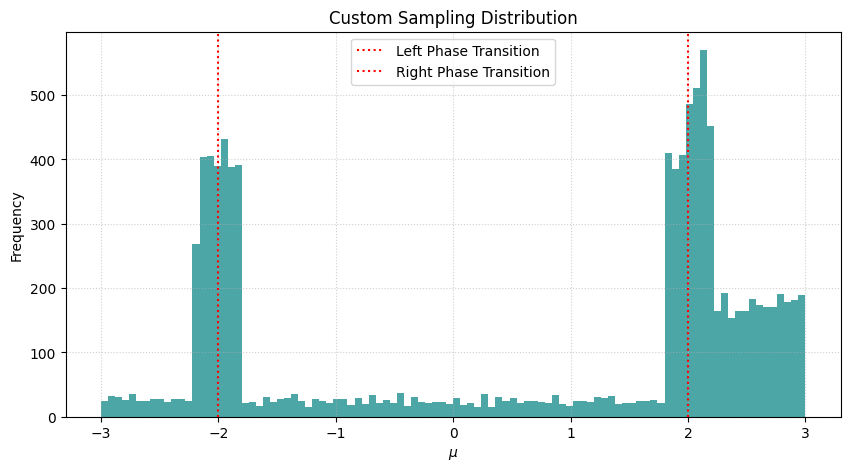

In [11]:
import matplotlib.pyplot as plt

# Visualize the sampling distribution
sample_mus = data_gen.sample_mu(10000).cpu().numpy().flatten()

plt.figure(figsize=(10, 5))
plt.hist(sample_mus, bins=100, color='teal', alpha=0.7)
plt.title('Custom Sampling Distribution')
plt.xlabel(r'$\mu$')
plt.ylabel('Frequency')
plt.axvline(-2, color='red', linestyle=':', label='Left Phase Transition')
plt.axvline(2, color='red', linestyle=':', label='Right Phase Transition')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


Generating plots for the Unified Trainer Pinned FSM...


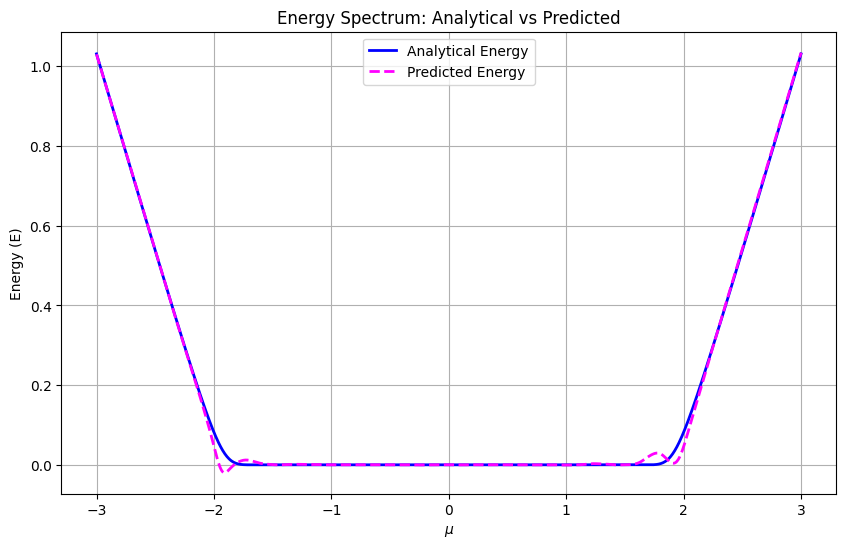

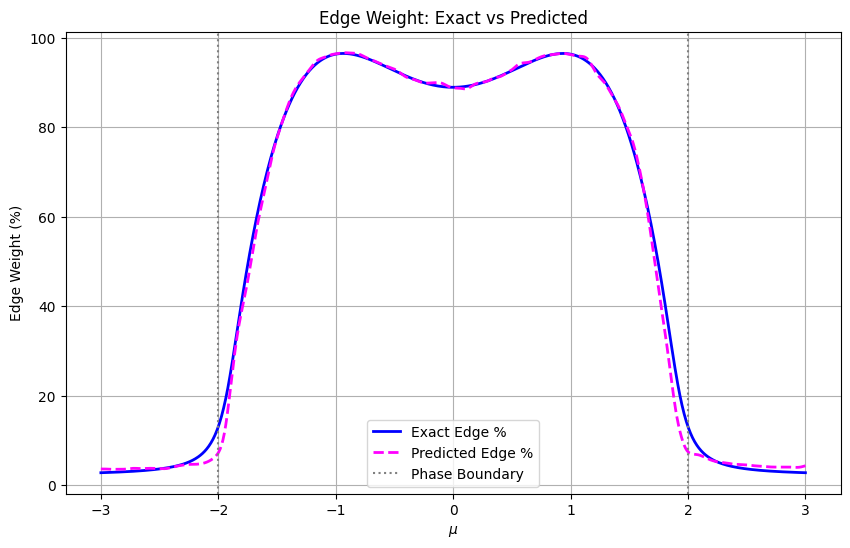

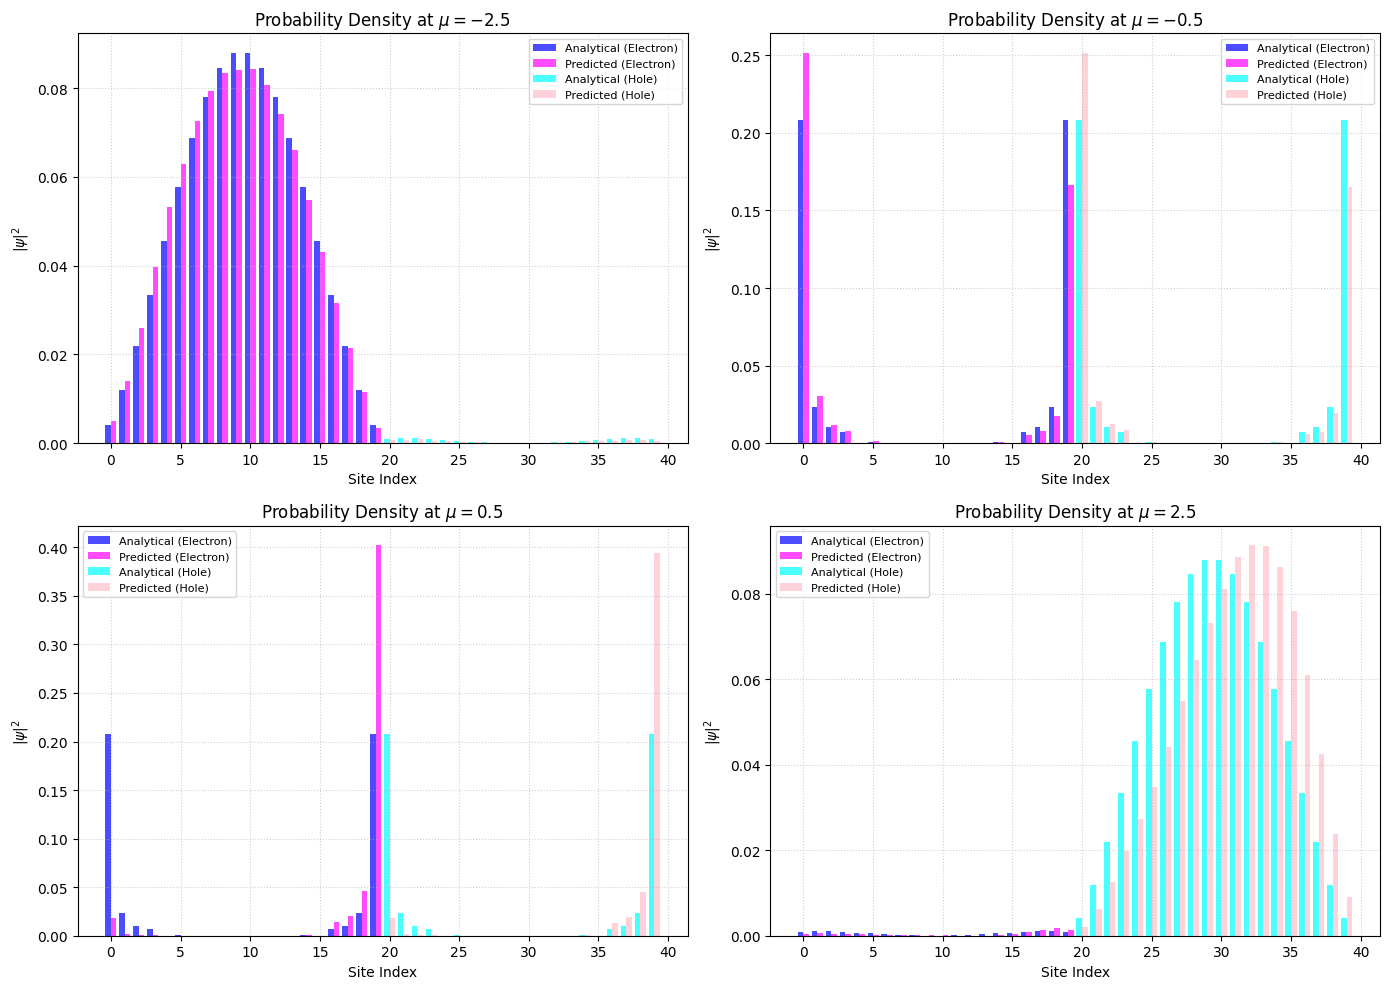

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

N = 20  # Explicitly reset N to 20 (number of sites) since it was overwritten in the previous cell

# --- Evaluation Plotting Suite ---
print("Generating plots for the Unified Trainer Pinned FSM...")

if 'model_pinned' not in globals() or 'X_tensor' not in globals():
    print("Error: Model or test data not found. Please run the training and data generation cells first.")
else:
    model_pinned.eval()
    X_full = X_tensor.to(device)
    E_full_exact = E_tensor.cpu().numpy().flatten()
    Psi_full_exact = Psi_tensor.cpu().numpy()
    mu_arr = X_full.cpu().numpy().flatten()

    with torch.no_grad():
        Psi_full_pred = model_pinned(X_full)
        # Enforce L2 norm
        norms = torch.norm(Psi_full_pred, dim=1, keepdim=True)
        Psi_full_pred = Psi_full_pred / norms

        # Reconstruct Hamiltonian for the batch to get Rayleigh quotient (Energy)
        H_batch = H_base.unsqueeze(0) + X_full.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
        H_psi = torch.bmm(H_batch, Psi_full_pred.unsqueeze(-1)).squeeze(-1)
        E_full_pred = torch.sum(Psi_full_pred * H_psi, dim=1).cpu().numpy()

        Psi_full_pred = Psi_full_pred.cpu().numpy()

    # 1. Energy Distribution Comparison
    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, E_full_exact, label="Analytical Energy", color='blue', linewidth=2)
    plt.plot(mu_arr, E_full_pred, label="Predicted Energy", color='magenta', linestyle='--', linewidth=2)
    plt.title('Energy Spectrum: Analytical vs Predicted')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Energy (E)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Edge Weight Comparison
    def calc_edge_prob(psi_arr):
        prob = np.abs(psi_arr)**2
        return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
                prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

    edge_exact = calc_edge_prob(Psi_full_exact)
    edge_pred = calc_edge_prob(Psi_full_pred)

    plt.figure(figsize=(10, 6))
    plt.plot(mu_arr, edge_exact, label="Exact Edge %", color='blue', linewidth=2)
    plt.plot(mu_arr, edge_pred, label="Predicted Edge %", color='magenta', linestyle='--', linewidth=2)
    plt.title('Edge Weight: Exact vs Predicted')
    plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
    plt.axvline(2.0, color='gray', linestyle=':')
    plt.xlabel(r'$\mu$')
    plt.ylabel('Edge Weight (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Probability Densities Comparison (Bar Charts)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    mu_samples = [-2.5, -0.5, 0.5, 2.5]

    for i, mu_val in enumerate(mu_samples):
        ax = axes.flatten()[i]
        idx = np.argmin(np.abs(mu_arr - mu_val))
        prob_exact = np.abs(Psi_full_exact[idx])**2
        prob_pred = np.abs(Psi_full_pred[idx])**2

        # Electron components
        ax.bar(np.arange(N) - 0.2, prob_exact[:N], width=0.4, label='Analytical (Electron)', color='blue', alpha=0.7)
        ax.bar(np.arange(N) + 0.2, prob_pred[:N], width=0.4, label='Predicted (Electron)', color='magenta', alpha=0.7)

        # Hole components
        ax.bar(np.arange(N, 2*N) - 0.2, prob_exact[N:], width=0.4, label='Analytical (Hole)', color='cyan', alpha=0.7)
        ax.bar(np.arange(N, 2*N) + 0.2, prob_pred[N:], width=0.4, label='Predicted (Hole)', color='pink', alpha=0.7)

        ax.set_title(fr'Probability Density at $\mu = {mu_val}$')
        ax.set_xlabel('Site Index')
        ax.set_ylabel(r'$|\psi|^2$')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


In [ ]:
class ShiftInvertLoss(BaseLoss):
    def __init__(self, sigma=0.0):
        self.sigma = sigma
        self.I_base = None

    def __call__(self, model, mu_batch, H_base, H_mu_diag, Xi):
        device = mu_batch.device
        if self.I_base is None:
            self.I_base = torch.eye(40, dtype=torch.float32, device=device)

        psi_pred = model(mu_batch)
        H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

        H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
        E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)

        H_shifted = H_batch - self.sigma * self.I_base.unsqueeze(0)
        H_shifted_psi = torch.bmm(H_shifted, psi_pred.unsqueeze(-1)).squeeze(-1)

        v_target = (E_rayleigh - self.sigma) * psi_pred
        loss_shift_invert = torch.mean((H_shifted_psi - v_target)**2)

        Xi_psi = torch.matmul(psi_pred, Xi.T)
        H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
        PH_res = H_Xi_psi + E_rayleigh * Xi_psi
        loss_ph = torch.mean(PH_res**2)

        return loss_shift_invert + loss_ph, {'shift_invert': loss_shift_invert.item(), 'ph': loss_ph.item()}

class InversePowerIterationLoss(BaseLoss):
    def __init__(self, sigma=1e-3, epsilon=1e-5, noise_std=0.05):
        self.sigma = sigma
        self.epsilon = epsilon
        self.noise_std = noise_std
        self.I_base = None

    def __call__(self, model, mu_batch, H_base, H_mu_diag, Xi):
        device = mu_batch.device
        if self.I_base is None:
            self.I_base = torch.eye(40, dtype=torch.float32, device=device)

        psi_pred = model(mu_batch)
        psi_prev = psi_pred.detach()

        if self.noise_std > 0:
            psi_noisy = psi_prev + self.noise_std * torch.randn_like(psi_prev)
            psi_noisy = psi_noisy / torch.norm(psi_noisy, dim=1, keepdim=True)
        else:
            psi_noisy = psi_prev

        H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
        H_shifted = H_batch - self.sigma * self.I_base.unsqueeze(0)
        H_shifted_reg = H_shifted + self.epsilon * self.I_base.unsqueeze(0)

        H_shifted_reg_64 = H_shifted_reg.to(torch.float64)
        psi_noisy_64 = psi_noisy.to(torch.float64)

        v_64 = torch.linalg.solve(H_shifted_reg_64, psi_noisy_64)
        v = v_64.to(torch.float32)

        v_norm = torch.norm(v, dim=1, keepdim=True)
        target = v / v_norm

        dot_product = torch.sum(psi_pred * target, dim=1, keepdim=True)
        target = target * torch.sign(dot_product + 1e-8)

        loss_ipi = torch.mean((psi_pred - target)**2)

        H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
        E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
        Xi_psi = torch.matmul(psi_pred, Xi.T)
        H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
        PH_res = H_Xi_psi + E_rayleigh * Xi_psi
        loss_ph = torch.mean(PH_res**2)

        return loss_ipi + 0.1 * loss_ph, {'ipi': loss_ipi.item(), 'ph': loss_ph.item()}

class FoldedSpectrumLoss(BaseLoss):
    def __call__(self, model, mu_batch, H_base, H_mu_diag, Xi):
        psi_pred = model(mu_batch)
        H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

        H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
        loss_fsm = torch.mean(H_psi**2)

        E_rayleigh = torch.sum(psi_pred * H_psi, dim=1, keepdim=True)
        Xi_psi = torch.matmul(psi_pred, Xi.T)
        H_Xi_psi = torch.bmm(H_batch, Xi_psi.unsqueeze(-1)).squeeze(-1)
        PH_res = H_Xi_psi + E_rayleigh * Xi_psi
        loss_ph = torch.mean(PH_res**2)

        return loss_fsm + 0.1 * loss_ph, {'fsm': loss_fsm.item(), 'ph': loss_ph.item()}

class HardConstrainedFSMLoss(BaseLoss):
    def __call__(self, model, mu_batch, H_base, H_mu_diag, Xi):
        psi_pred = model(mu_batch)
        H_batch = H_base.unsqueeze(0) + mu_batch.unsqueeze(-1) * H_mu_diag.unsqueeze(0)

        # With hard-coded E=0, the physics residual is simply H_psi
        H_psi = torch.bmm(H_batch, psi_pred.unsqueeze(-1)).squeeze(-1)
        loss_fsm = torch.mean(H_psi**2)

        # PHS and Normalization are handled structurally in SirenPINN_HardConstrained.
        # So we only need to return the FSM loss.
        return loss_fsm, {'fsm': loss_fsm.item()}


In [ ]:
import time
import torch
import torch.optim as optim

print("=== Training FSM with L-BFGS and UnifiedTrainer ===")
# 1. Generate full-batch dataset
data_gen_lbfgs = UnifiedDataGenerator(device=device, N=N)
total_samples = 10000

# For L-BFGS, we use the entire dataset as a single batch
lbfgs_loader = data_gen_lbfgs.get_dataloader(total_samples=total_samples, batch_size=total_samples, supervised=False)

# 2. Initialize Model and Loss
seed_everything(42)
model_fsm_lbfgs = SirenPINN_HardConstrained(hidden_features=32, hidden_layers=2, N=N).to(device)
loss_fn_fsm = HardConstrainedFSMLoss()

# 3. Setup L-BFGS parameters for UnifiedTrainer
lbfgs_kwargs = {
    'lr': 0.1,
    'max_iter': 20,                  # Inner iterations per step
    'max_eval': 25,                  # Max function evaluations per step
    'tolerance_grad': 1e-7,
    'tolerance_change': 1e-9,
    'history_size': 100,             # Number of past gradients to store for Hessian approximation
    'line_search_fn': "strong_wolfe" # Helps stabilize training
}

# Use the refactored UnifiedTrainer
trainer_lbfgs = UnifiedTrainer(
    model=model_fsm_lbfgs,
    loss_fn=loss_fn_fsm,
    optimizer_class=optim.LBFGS,
    optimizer_kwargs=lbfgs_kwargs,
    scheduler_class=None, # L-BFGS typically doesn't use the standard step scheduler here
    device=device
)

# 4. Train!
epochs = 50
trainer_lbfgs.train(
    data_loader=lbfgs_loader,
    H_base=H_base,
    H_mu_diag=H_mu_diag,
    Xi=Xi,
    epochs=epochs,
    print_freq=5
)

=== Training FSM with L-BFGS and UnifiedTrainer ===
Generating 10000 samples with oversampling...

--- Starting Unified Training (FoldedSpectrumLoss) ---


ValueError: not enough values to unpack (expected 3, got 1)

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Generating eval suite plots for L-BFGS FSM Model...")

# Generate a fresh, ordered test set using the data generator
test_loader = data_gen_lbfgs.get_dataloader(total_samples=1500, batch_size=1500, supervised=True)
mu_batch, E_batch, Psi_batch = next(iter(test_loader))

# Sort by mu for clean line plotting
mu_arr = mu_batch.cpu().numpy().flatten()
sort_idx = np.argsort(mu_arr)
mu_arr = mu_arr[sort_idx]
E_full_exact = E_batch.cpu().numpy().flatten()[sort_idx]
Psi_full_exact = Psi_batch.cpu().numpy()[sort_idx]
X_full = mu_batch.to(device)[sort_idx]

model_fsm_lbfgs.eval()
with torch.no_grad():
    Psi_full_pred = model_fsm_lbfgs(X_full)
    norms = torch.norm(Psi_full_pred, dim=1, keepdim=True)
    Psi_full_pred = Psi_full_pred / norms

    # Reconstruct Hamiltonian for the batch to get Rayleigh quotient (Energy)
    H_batch = H_base.unsqueeze(0) + X_full.unsqueeze(-1) * H_mu_diag.unsqueeze(0)
    H_psi = torch.bmm(H_batch, Psi_full_pred.unsqueeze(-1)).squeeze(-1)
    E_full_pred = torch.sum(Psi_full_pred * H_psi, dim=1).cpu().numpy()
    Psi_full_pred = Psi_full_pred.cpu().numpy()

# 1. Energy Distribution Comparison
plt.figure(figsize=(10, 6))
plt.plot(mu_arr, E_full_exact, label="Analytical Energy", color='blue', linewidth=2)
plt.plot(mu_arr, E_full_pred, label="Predicted Energy (L-BFGS FSM)", color='orange', linestyle='--', linewidth=2)
plt.title('Energy Spectrum: Analytical vs Predicted')
plt.xlabel(r'$\mu$')
plt.ylabel('Energy (E)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Edge Weight Comparison
def calc_edge_prob(psi_arr):
    prob = np.abs(psi_arr)**2
    return (prob[:, 0] + prob[:, 1] + prob[:, N-2] + prob[:, N-1] +
            prob[:, N] + prob[:, N+1] + prob[:, 2*N-2] + prob[:, 2*N-1]) * 100

edge_exact = calc_edge_prob(Psi_full_exact)
edge_pred = calc_edge_prob(Psi_full_pred)

plt.figure(figsize=(10, 6))
plt.plot(mu_arr, edge_exact, label="Exact Edge %", color='blue', linewidth=2)
plt.plot(mu_arr, edge_pred, label="Predicted Edge %", color='orange', linestyle='--', linewidth=2)
plt.title('Edge Weight: Exact vs Predicted')
plt.axvline(-2.0, color='gray', linestyle=':', label='Phase Boundary')
plt.axvline(2.0, color='gray', linestyle=':')
plt.xlabel(r'$\mu$')
plt.ylabel('Edge Weight (%)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Probability Densities Comparison (Side-by-Side Subplots)
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
mu_samples = [-2.5, -0.5, 0.5, 2.5]

for i, mu_val in enumerate(mu_samples):
    idx = np.argmin(np.abs(mu_arr - mu_val))
    prob_exact = np.abs(Psi_full_exact[idx])**2
    prob_pred = np.abs(Psi_full_pred[idx])**2

    ax_p = axes[i, 0]  # Particle Subplot
    ax_h = axes[i, 1]  # Hole Subplot

    # Particle components (Sites 0 to N-1)
    ax_p.bar(np.arange(N) - 0.2, prob_exact[:N], width=0.4, label='Analytical (Electron)', color='blue', alpha=0.7)
    ax_p.bar(np.arange(N) + 0.2, prob_pred[:N], width=0.4, label='Predicted (Electron)', color='orange', alpha=0.7)
    ax_p.set_title(fr'Particle Density at $\mu \approx {mu_val}$')
    ax_p.set_xlabel('Site Index (0 to 19)')
    ax_p.set_ylabel(r'$|\psi|^2$')
    ax_p.legend(fontsize=9)
    ax_p.grid(True, linestyle=':', alpha=0.6)

    # Hole components (Sites N to 2N-1 mapped back to 0 to N-1 for x-axis)
    ax_h.bar(np.arange(N) - 0.2, prob_exact[N:], width=0.4, label='Analytical (Hole)', color='cyan', alpha=0.7)
    ax_h.bar(np.arange(N) + 0.2, prob_pred[N:], width=0.4, label='Predicted (Hole)', color='red', alpha=0.7)
    ax_h.set_title(fr'Hole Density at $\mu \approx {mu_val}$')
    ax_h.set_xlabel('Site Index (0 to 19)')
    ax_h.set_ylabel(r'$|\psi|^2$')
    ax_h.legend(fontsize=9)
    ax_h.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Generating eval suite plots for L-BFGS FSM Model...


NameError: name 'data_gen_lbfgs' is not defined

## Discrete and Continuous Hard Constraints


In [19]:
import torch
import torch.nn as nn
import numpy as np

class SirenPINN_1DDiscrete(nn.Module):
    def __init__(self, in_features=1, hidden_features=32, hidden_layers=2, N=20, xi=0.2):
        super().__init__()
        self.N = N
        self.xi = xi

        # SIREN Backbone
        layers = [SineLayer(in_features, hidden_features, is_first=True, omega_0=30.0)]
        for _ in range(hidden_layers):
            layers.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*layers)

        # Output two full state vectors (u1, u2) of length N
        self.u_head = nn.Linear(hidden_features, 2 * N)

        # Precompute static lattice spatial envelope
        x_lattice = torch.linspace(0, 1, steps=N)
        envelope = torch.exp(-x_lattice / self.xi) + torch.exp(-(1 - x_lattice) / self.xi)
        self.register_buffer('envelope', envelope)  # Shape: [N]

    def forward(self, x):
        # x is typically a parameter context/dummy tensor [Batch, in_features]
        features = self.net(x)
        u_out = self.u_head(features)  # Shape: [Batch, 2*N]

        u1 = u_out[:, :self.N]
        u2 = u_out[:, self.N:]

        # 1. Hard Pinning: Static spatial mask
        u1_localized = u1 * self.envelope
        u2_localized = u2 * self.envelope

        # 2. Hard Particle-Hole Symmetry (PHS)
        Psi1 = torch.cat([u1_localized, u1_localized], dim=1)  # [Batch, 2N]
        Psi2 = torch.cat([u2_localized, u2_localized], dim=1)  # [Batch, 2N]

        # 3. Hard Normalization & Orthogonality over vector elements (dim=1)
        Psi1 = Psi1 / torch.norm(Psi1, p=2, dim=1, keepdim=True)
        proj = torch.sum(Psi2 * Psi1, dim=1, keepdim=True) * Psi1
        Psi2_orthogonal = Psi2 - proj
        Psi2 = Psi2_orthogonal / torch.norm(Psi2_orthogonal, p=2, dim=1, keepdim=True)

        return Psi1, Psi2


In [28]:
class SirenPINN_1DContinuous(nn.Module):
    def __init__(self, in_features=2, hidden_features=32, hidden_layers=2, xi=0.2):
        super().__init__()
        self.xi = xi

        # Input features = 2 (coordinate x and parameter mu)
        layers = [SineLayer(in_features, hidden_features, is_first=True, omega_0=30.0)]
        for _ in range(hidden_layers):
            layers.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*layers)

        # Output exactly 2 values: u1(x) and u2(x) at point x
        self.u_head = nn.Linear(hidden_features, 2)

    def forward(self, x_coords):
        # x_coords shape: [Spatial_Batch, 2] containing column 0 (x) and column 1 (mu)
        x = x_coords[:, 0:1]

        features = self.net(x_coords)
        u_out = self.u_head(features)  # Shape: [Spatial_Batch, 2]

        u1 = u_out[:, 0:1]
        u2 = u_out[:, 1:2]

        # 1. Hard Pinning: Dynamic spatial envelope
        dynamic_envelope = torch.exp(-x / self.xi) + torch.exp(-(1 - x) / self.xi)
        u1_localized = u1 * dynamic_envelope
        u2_localized = u2 * dynamic_envelope

        # 2. Hard Particle-Hole Symmetry (PHS)
        Psi1 = torch.cat([u1_localized, u1_localized], dim=1)  # [Spatial_Batch, 2]
        Psi2 = torch.cat([u2_localized, u2_localized], dim=1)  # [Spatial_Batch, 2]

        # 3. Hard Normalization & Orthogonality over spatial domain (dim=0)
        eps = 1e-8
        Psi1 = Psi1 / (torch.norm(Psi1, p=2, dim=0, keepdim=True) + eps)
        proj = torch.sum(Psi2 * Psi1, dim=0, keepdim=True) * Psi1
        Psi2_orthogonal = Psi2 - proj
        Psi2 = Psi2_orthogonal / (torch.norm(Psi2_orthogonal, p=2, dim=0, keepdim=True) + eps)

        return Psi1, Psi2


In [13]:
class SirenPINN_2DContinuous(nn.Module):
    def __init__(self, hidden_features=64, hidden_layers=3, xi=0.2):
        super().__init__()
        self.xi = xi

        # Input features = 2 (coordinates x and y)
        layers = [SineLayer(2, hidden_features, is_first=True, omega_0=30.0)]
        for _ in range(hidden_layers):
            layers.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*layers)

        # Output exactly 2 values: u1(x,y) and u2(x,y) at point (x,y)
        self.u_head = nn.Linear(hidden_features, 2)

    def forward(self, coords):
        # coords shape: [Spatial_Batch, 2] containing column 0 (x) and column 1 (y)
        x = coords[:, 0:1]
        y = coords[:, 1:2]

        features = self.net(coords)
        u_out = self.u_head(features)  # Shape: [Spatial_Batch, 2]

        u1 = u_out[:, 0:1]
        u2 = u_out[:, 1:2]

        # 1. Hard Pinning: 2D Envelope decaying from all 4 square boundaries
        env_x = torch.exp(-x / self.xi) + torch.exp(-(1 - x) / self.xi)
        env_y = torch.exp(-y / self.xi) + torch.exp(-(1 - y) / self.xi)
        envelope_2d = env_x * env_y

        u1_localized = u1 * envelope_2d
        u2_localized = u2 * envelope_2d

        # 2. Hard Particle-Hole Symmetry (PHS)
        Psi1 = torch.cat([u1_localized, u1_localized], dim=1)  # [Spatial_Batch, 2]
        Psi2 = torch.cat([u2_localized, u2_localized], dim=1)  # [Spatial_Batch, 2]

        # 3. Hard Normalization & Orthogonality over 2D spatial distribution (dim=0)
        Psi1 = Psi1 / torch.norm(Psi1, p=2, dim=0, keepdim=True)
        proj = torch.sum(Psi2 * Psi1, dim=0, keepdim=True) * Psi1
        Psi2_orthogonal = Psi2 - proj
        Psi2 = Psi2_orthogonal / torch.norm(Psi2_orthogonal, p=2, dim=0, keepdim=True)

        return Psi1, Psi2


In [ ]:
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)

        # Specialized SIREN initialization
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / in_features, 1 / in_features)
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / in_features) / self.omega_0,
                                             np.sqrt(6 / in_features) / self.omega_0)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


In [25]:
import torch
import torch.nn as nn
import numpy as np

# --- 1. MODIFIED ARCHITECTURE FOR SMOOTH GRADIENT FLOW ---
class SirenPINN_1DDiscrete_Unfrozen(nn.Module):
    def __init__(self, in_features=1, hidden_features=64, hidden_layers=2, N=20, xi=0.5): # Start with wider xi
        super().__init__()
        self.N = N
        self.xi = xi

        # LOWER OMEGA_0: Lowered from 30.0 to 5.0 to smooth out initial oscillations
        layers = [SineLayer(in_features, hidden_features, is_first=True, omega_0=5.0)]
        for _ in range(hidden_layers):
            layers.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=2.0))
        self.net = nn.Sequential(*layers)

        self.u_head = nn.Linear(hidden_features, 2 * N)

        # Initialize the two heads completely differently to avoid Gram-Schmidt cancellation
        with torch.no_grad():
            self.u_head.weight[:N, :] = torch.randn(N, hidden_features) * 0.1
            self.u_head.weight[N:, :] = torch.randn(N, hidden_features) * 0.1 + 0.5 # Shift space

    def forward(self, x, current_xi=None):
        if current_xi is None:
            current_xi = self.xi

        features = self.net(x)
        u_out = self.u_head(features)

        u1 = u_out[:, :self.N]
        u2 = u_out[:, self.N:]

        # Dynamic envelope calculation to allow curriculum learning
        x_lattice = torch.linspace(0, 1, steps=self.N).to(x.device)
        envelope = torch.exp(-x_lattice / current_xi) + torch.exp(-(1 - x_lattice) / current_xi)

        u1_localized = u1 * envelope
        u2_localized = u2 * envelope

        Psi1 = torch.cat([u1_localized, u1_localized], dim=1)
        Psi2 = torch.cat([u2_localized, u2_localized], dim=1)

        # Add a larger epsilon (1e-4) during initialization to keep gradients robust
        eps = 1e-4

        Psi1 = Psi1 / (torch.norm(Psi1, p=2, dim=1, keepdim=True) + eps)

        # Soften the orthogonal projection slightly at the beginning to allow both heads to learn
        proj = torch.sum(Psi2 * Psi1, dim=1, keepdim=True) * Psi1
        Psi2_orthogonal = Psi2 - 0.95 * proj # 0.95 allows a tiny leakage so gradients don't die

        Psi2 = Psi2_orthogonal / (torch.norm(Psi2_orthogonal, p=2, dim=1, keepdim=True) + eps)

        return Psi1, Psi2


=== Comparing 1D Discrete vs 1D Continuous PINN Architectures ===
Training both models to fit the exact eigenstate...
Epoch 0200 | Discrete MSE: 0.014644 | Continuous MSE: 0.025000
Epoch 0400 | Discrete MSE: 0.014644 | Continuous MSE: 0.025000
Epoch 0600 | Discrete MSE: 0.014644 | Continuous MSE: 0.025000
Epoch 0800 | Discrete MSE: 0.014644 | Continuous MSE: 0.025000
Epoch 1000 | Discrete MSE: 0.014644 | Continuous MSE: 0.025000


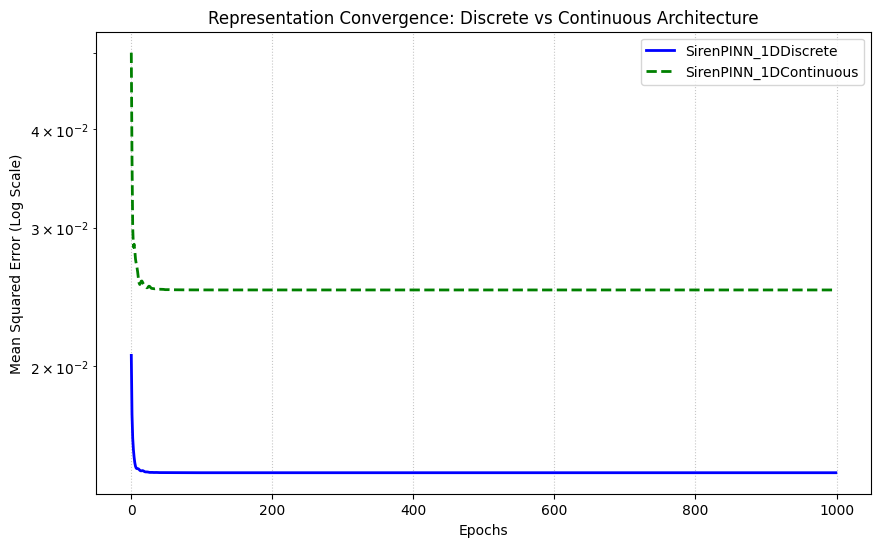

In [29]:
import torch.optim as optim
import matplotlib.pyplot as plt

print("=== Comparing 1D Discrete vs 1D Continuous PINN Architectures ===")

# 1. Setup exact target state (Topological edge state at mu = 0.0)
mu_test = 0.0
H_test = build_hamiltonian(mu_test, N=20)
evals_test, evecs_test = np.linalg.eigh(H_test)
psi_target = torch.tensor(evecs_test[:, 20], dtype=torch.float32, device=device)

# 2. Initialize Models
model_discrete = SirenPINN_1DDiscrete_Unfrozen(in_features=1, hidden_features=32, hidden_layers=2, N=20, xi=0.2).to(device)
model_continuous = SirenPINN_1DContinuous(in_features=2, hidden_features=32, hidden_layers=2, xi=0.2).to(device)

opt_disc = optim.AdamW(model_discrete.parameters(), lr=2e-3)
opt_cont = optim.AdamW(model_continuous.parameters(), lr=2e-3)

# 3. Model Inputs
# Discrete model takes a dummy parameter context (e.g. mu)
x_dummy_disc = torch.tensor([[mu_test]], dtype=torch.float32, device=device) # Shape: [1, 1]

# Continuous model takes spatial grid + mu parameter
x_spatial_base = torch.linspace(0, 1, steps=20, device=device).unsqueeze(1)
mu_tensor_cont = torch.full((20, 1), mu_test, dtype=torch.float32, device=device)
x_spatial_cont = torch.cat([x_spatial_base, mu_tensor_cont], dim=1) # Shape: [20, 2]

epochs = 1000
loss_disc_history = []
loss_cont_history = []

# 4. Training Loop
print("Training both models to fit the exact eigenstate...")
for epoch in range(epochs):
    # --- Discrete Model Forward & Backward ---
    opt_disc.zero_grad()
    Psi1_d, Psi2_d = model_discrete(x_dummy_disc)
    Psi1_d_flat = Psi1_d[0] # Shape [40]

    # Phase alignment (gauge fixing)
    if torch.dot(Psi1_d_flat, psi_target) < 0:
        Psi1_d_flat = -Psi1_d_flat

    loss_d = torch.mean((Psi1_d_flat - psi_target)**2)
    loss_d.backward()
    opt_disc.step()
    loss_disc_history.append(loss_d.item())

    # --- Continuous Model Forward & Backward ---
    opt_cont.zero_grad()
    Psi1_c, Psi2_c = model_continuous(x_spatial_cont)

    # Psi1_c has shape [20, 2]. Transpose to [2, 20] (Electron, Hole) and flatten to [40]
    Psi1_c_flat = Psi1_c.T.flatten()

    # Phase alignment
    if torch.dot(Psi1_c_flat, psi_target) < 0:
        Psi1_c_flat = -Psi1_c_flat

    loss_c = torch.mean((Psi1_c_flat - psi_target)**2)
    loss_c.backward()
    opt_cont.step()
    loss_cont_history.append(loss_c.item())

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1:04d} | Discrete MSE: {loss_d.item():.6f} | Continuous MSE: {loss_c.item():.6f}")

# 5. Plotting Convergence
plt.figure(figsize=(10, 6))
plt.plot(loss_disc_history, label="SirenPINN_1DDiscrete", color="blue", linewidth=2)
plt.plot(loss_cont_history, label="SirenPINN_1DContinuous", color="green", linestyle="--", linewidth=2)
plt.yscale("log")
plt.title("Representation Convergence: Discrete vs Continuous Architecture")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.7)
plt.show()


Generating evaluation plots for Discrete vs Continuous Models...


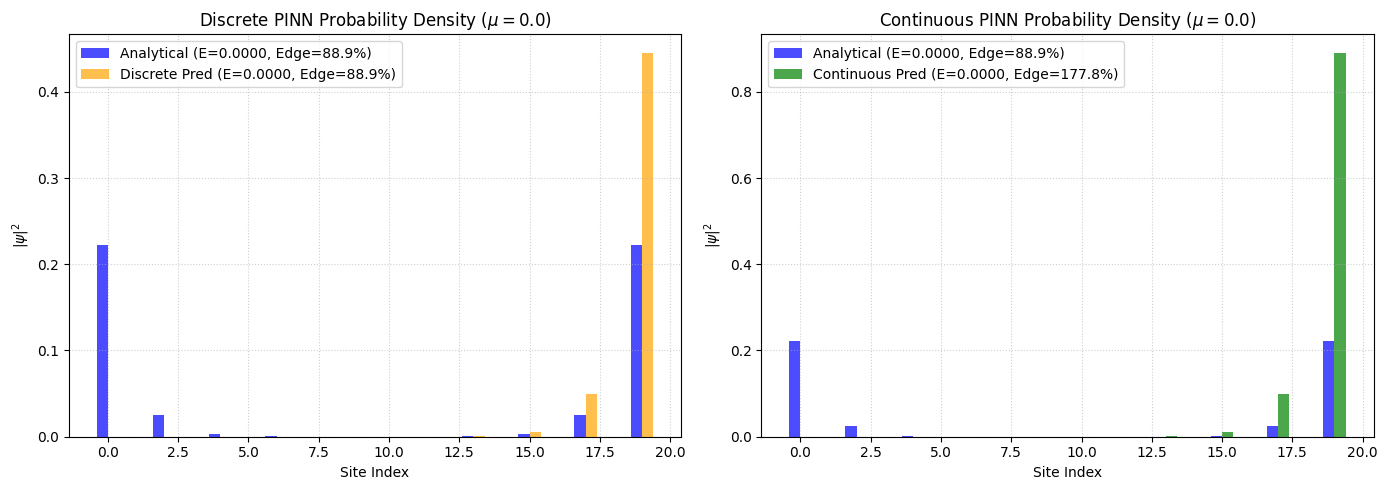

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Generating evaluation plots for Discrete vs Continuous Models...")

model_discrete.eval()
model_continuous.eval()

mu_val = 0.0
H_exact = build_hamiltonian(mu_val, N=20)

# Refresh inputs for evaluation
x_dummy_disc_eval = torch.tensor([[mu_val]], dtype=torch.float32, device=device)
x_spatial_base_eval = torch.linspace(0, 1, steps=20, device=device).unsqueeze(1)
mu_tensor_cont_eval = torch.full((20, 1), mu_val, dtype=torch.float32, device=device)
x_spatial_cont_eval = torch.cat([x_spatial_base_eval, mu_tensor_cont_eval], dim=1)

with torch.no_grad():
    # Discrete prediction
    Psi1_d, _ = model_discrete(x_dummy_disc_eval)
    Psi1_d_flat = Psi1_d[0].cpu().numpy()

    # Continuous prediction
    Psi1_c, _ = model_continuous(x_spatial_cont_eval)
    Psi1_c_flat = Psi1_c.T.flatten().cpu().numpy()

psi_target_np = psi_target.cpu().numpy()

# Calculate probability densities
prob_target = np.abs(psi_target_np)**2
prob_d = np.abs(Psi1_d_flat)**2
prob_c = np.abs(Psi1_c_flat)**2

N = 20

# Calculate Energies (Rayleigh Quotient)
E_target = evals_test[N]
E_d = Psi1_d_flat.T @ H_exact @ Psi1_d_flat
E_c = Psi1_c_flat.T @ H_exact @ Psi1_c_flat

# Calculate Edge Weights
def calc_edge(prob):
    return (prob[0] + prob[1] + prob[N-2] + prob[N-1] +
            prob[N] + prob[N+1] + prob[2*N-2] + prob[2*N-1]) * 100

edge_target = calc_edge(prob_target)
edge_d = calc_edge(prob_d)
edge_c = calc_edge(prob_c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Discrete Model Plot (Electron components)
axes[0].bar(np.arange(N) - 0.2, prob_target[:N], width=0.4, label=f'Analytical (E={E_target:.4f}, Edge={edge_target:.1f}%)', color='blue', alpha=0.7)
axes[0].bar(np.arange(N) + 0.2, prob_d[:N], width=0.4, label=f'Discrete Pred (E={E_d:.4f}, Edge={edge_d:.1f}%)', color='orange', alpha=0.7)
axes[0].set_title(rf'Discrete PINN Probability Density ($\mu={mu_val}$)')
axes[0].set_xlabel('Site Index')
axes[0].set_ylabel(r'$|\psi|^2$')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Continuous Model Plot (Electron components)
axes[1].bar(np.arange(N) - 0.2, prob_target[:N], width=0.4, label=f'Analytical (E={E_target:.4f}, Edge={edge_target:.1f}%)', color='blue', alpha=0.7)
axes[1].bar(np.arange(N) + 0.2, prob_c[:N], width=0.4, label=f'Continuous Pred (E={E_c:.4f}, Edge={edge_c:.1f}%)', color='green', alpha=0.7)
axes[1].set_title(rf'Continuous PINN Probability Density ($\mu={mu_val}$)')
axes[1].set_xlabel('Site Index')
axes[1].set_ylabel(r'$|\psi|^2$')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16876/215027489.py:24: SyntaxWarning: invalid escape sequence '\m'
  print("Training both models across the entire parameter space (\mu in [-3, 3])...")


=== Running Full Parameter Sweep: Discrete vs Continuous ===
Generating 3000 samples with oversampling...
Calculating exact labels (E, Psi) for supervised dataset. This may take a moment...
Training both models across the entire parameter space (\mu in [-3, 3])...
Epoch 0100 | Discrete MSE: 0.014676 | Continuous MSE: 0.022085
Epoch 0200 | Discrete MSE: 0.014646 | Continuous MSE: 0.022071
Epoch 0300 | Discrete MSE: 0.014644 | Continuous MSE: 0.022067
Epoch 0400 | Discrete MSE: 0.014644 | Continuous MSE: 0.022065
Epoch 0500 | Discrete MSE: 0.014684 | Continuous MSE: 0.022065
Sweep training complete in 47.30s


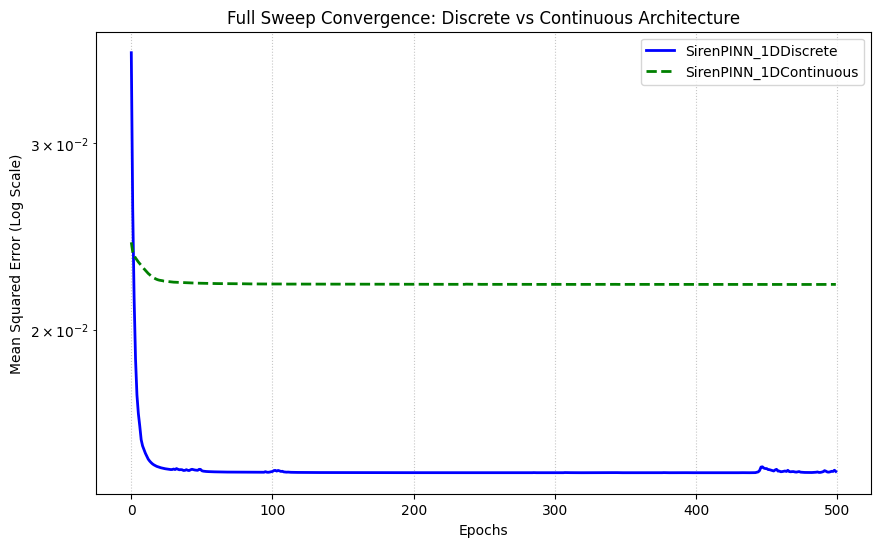

In [34]:
import torch.optim as optim
import matplotlib.pyplot as plt
import time

print("=== Running Full Parameter Sweep: Discrete vs Continuous ===")

# 1. Dataset Generation: We will use the existing `data_gen` and `sup_loader` if available,
# or recreate a batch if needed. Let's create a dedicated loader for this comparison.
data_gen_sweep = UnifiedDataGenerator(device=device, N=20)
# We'll use supervised for exact loss calculation during this sweep
sweep_loader = data_gen_sweep.get_dataloader(total_samples=3000, batch_size=256, supervised=True)

# 2. Initialize fresh Models to compare from scratch
model_disc_sweep = SirenPINN_1DDiscrete_Unfrozen(in_features=1, hidden_features=32, hidden_layers=2, N=20, xi=0.2).to(device)
model_cont_sweep = SirenPINN_1DContinuous(in_features=2, hidden_features=32, hidden_layers=2, xi=0.2).to(device)

opt_disc_sweep = optim.AdamW(model_disc_sweep.parameters(), lr=1e-3)
opt_cont_sweep = optim.AdamW(model_cont_sweep.parameters(), lr=1e-3)

epochs_sweep = 500
loss_disc_history_sweep = []
loss_cont_history_sweep = []

print("Training both models across the entire parameter space (\mu in [-3, 3])...")
start_time = time.time()

for epoch in range(epochs_sweep):
    model_disc_sweep.train()
    model_cont_sweep.train()

    epoch_loss_d = 0.0
    epoch_loss_c = 0.0
    num_batches = 0

    for mu_batch, E_batch, Psi_batch in sweep_loader:
        mu_batch = mu_batch.to(device)
        Psi_batch = Psi_batch.to(device)
        bs = mu_batch.shape[0]

        # --- Discrete Model ---
        opt_disc_sweep.zero_grad()
        Psi1_d, _ = model_disc_sweep(mu_batch)
        # Shape is [Batch, 40]. Calculate MSE.
        # Need phase alignment for batched data
        dot_d = torch.sum(Psi1_d * Psi_batch, dim=1, keepdim=True)
        Psi1_d_aligned = Psi1_d * torch.sign(dot_d + 1e-8)

        loss_d = torch.mean((Psi1_d_aligned - Psi_batch)**2)
        loss_d.backward()
        opt_disc_sweep.step()
        epoch_loss_d += loss_d.item()

        # --- Continuous Model ---
        opt_cont_sweep.zero_grad()

        # Prepare Continuous input: repeat mu for each spatial point
        # We need shape [Batch * 20, 2]
        x_spatial = torch.linspace(0, 1, steps=20, device=device).unsqueeze(1) # [20, 1]
        x_spatial_tiled = x_spatial.repeat(bs, 1) # [Batch * 20, 1]
        mu_tiled = mu_batch.repeat_interleave(20, dim=0) # [Batch * 20, 1]
        x_cont_input = torch.cat([x_spatial_tiled, mu_tiled], dim=1) # [Batch * 20, 2]

        Psi1_c, _ = model_cont_sweep(x_cont_input)
        # Psi1_c is [Batch * 20, 2]. We need to reshape back to [Batch, 40]
        # The output has (electron, hole) for each point.
        Psi1_c_reshaped = Psi1_c.view(bs, 20, 2)
        Psi1_c_flat = torch.cat([Psi1_c_reshaped[:, :, 0], Psi1_c_reshaped[:, :, 1]], dim=1)

        # Phase alignment
        dot_c = torch.sum(Psi1_c_flat * Psi_batch, dim=1, keepdim=True)
        Psi1_c_aligned = Psi1_c_flat * torch.sign(dot_c + 1e-8)

        loss_c = torch.mean((Psi1_c_aligned - Psi_batch)**2)
        loss_c.backward()
        opt_cont_sweep.step()
        epoch_loss_c += loss_c.item()

        num_batches += 1

    loss_disc_history_sweep.append(epoch_loss_d / num_batches)
    loss_cont_history_sweep.append(epoch_loss_c / num_batches)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:04d} | Discrete MSE: {epoch_loss_d/num_batches:.6f} | Continuous MSE: {epoch_loss_c/num_batches:.6f}")

print(f"Sweep training complete in {time.time() - start_time:.2f}s")

# Plot the training comparison
plt.figure(figsize=(10, 6))
plt.plot(loss_disc_history_sweep, label="SirenPINN_1DDiscrete", color="blue", linewidth=2)
plt.plot(loss_cont_history_sweep, label="SirenPINN_1DContinuous", color="green", linestyle="--", linewidth=2)
plt.yscale("log")
plt.title("Full Sweep Convergence: Discrete vs Continuous Architecture")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.7)
plt.show()


<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16876/215027489.py:24: SyntaxWarning: invalid escape sequence '\m'
  print("Training both models across the entire parameter space (\mu in [-3, 3])...")


=== Running Full Parameter Sweep: Discrete vs Continuous ===
Generating 3000 samples with oversampling...
Calculating exact labels (E, Psi) for supervised dataset. This may take a moment...
Training both models across the entire parameter space (\mu in [-3, 3])...
Epoch 0100 | Discrete MSE: 0.014730 | Continuous MSE: 0.022129
Epoch 0200 | Discrete MSE: 0.014652 | Continuous MSE: 0.022096
Epoch 0300 | Discrete MSE: 0.014647 | Continuous MSE: 0.022090
Epoch 0400 | Discrete MSE: 0.014672 | Continuous MSE: 0.022084
Epoch 0500 | Discrete MSE: 0.014646 | Continuous MSE: 0.022082
Sweep training complete in 46.99s


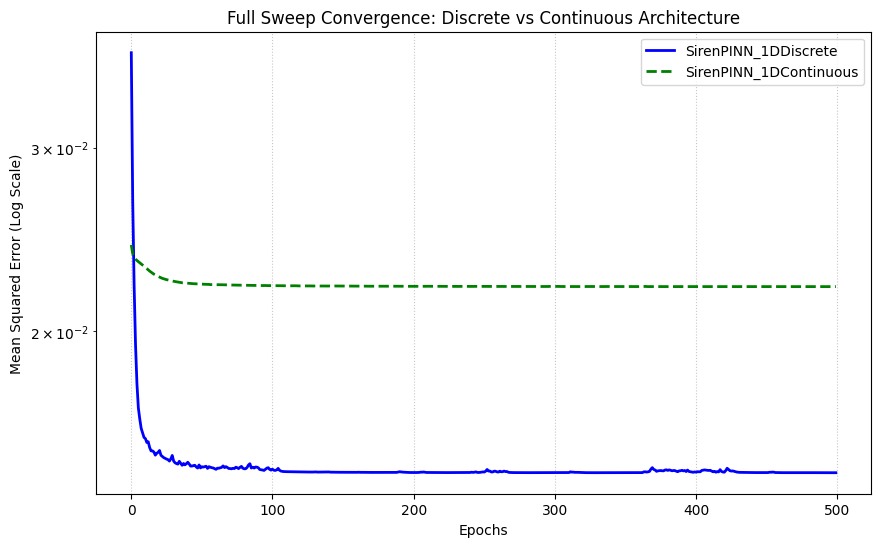

In [33]:
import torch.optim as optim
import matplotlib.pyplot as plt
import time

print("=== Running Full Parameter Sweep: Discrete vs Continuous ===")

# 1. Dataset Generation: We will use the existing `data_gen` and `sup_loader` if available,
# or recreate a batch if needed. Let's create a dedicated loader for this comparison.
data_gen_sweep = UnifiedDataGenerator(device=device, N=20)
# We'll use supervised for exact loss calculation during this sweep
sweep_loader = data_gen_sweep.get_dataloader(total_samples=3000, batch_size=256, supervised=True)

# 2. Initialize fresh Models to compare from scratch
model_disc_sweep = SirenPINN_1DDiscrete_Unfrozen(in_features=1, hidden_features=32, hidden_layers=2, N=20, xi=0.2).to(device)
model_cont_sweep = SirenPINN_1DContinuous(in_features=2, hidden_features=32, hidden_layers=2, xi=0.2).to(device)

opt_disc_sweep = optim.AdamW(model_disc_sweep.parameters(), lr=1e-3)
opt_cont_sweep = optim.AdamW(model_cont_sweep.parameters(), lr=1e-3)

epochs_sweep = 500
loss_disc_history_sweep = []
loss_cont_history_sweep = []

print("Training both models across the entire parameter space (\mu in [-3, 3])...")
start_time = time.time()

for epoch in range(epochs_sweep):
    model_disc_sweep.train()
    model_cont_sweep.train()

    epoch_loss_d = 0.0
    epoch_loss_c = 0.0
    num_batches = 0

    for mu_batch, E_batch, Psi_batch in sweep_loader:
        mu_batch = mu_batch.to(device)
        Psi_batch = Psi_batch.to(device)
        bs = mu_batch.shape[0]

        # --- Discrete Model ---
        opt_disc_sweep.zero_grad()
        Psi1_d, _ = model_disc_sweep(mu_batch)
        # Shape is [Batch, 40]. Calculate MSE.
        # Need phase alignment for batched data
        dot_d = torch.sum(Psi1_d * Psi_batch, dim=1, keepdim=True)
        Psi1_d_aligned = Psi1_d * torch.sign(dot_d + 1e-8)

        loss_d = torch.mean((Psi1_d_aligned - Psi_batch)**2)
        loss_d.backward()
        opt_disc_sweep.step()
        epoch_loss_d += loss_d.item()

        # --- Continuous Model ---
        opt_cont_sweep.zero_grad()

        # Prepare Continuous input: repeat mu for each spatial point
        # We need shape [Batch * 20, 2]
        x_spatial = torch.linspace(0, 1, steps=20, device=device).unsqueeze(1) # [20, 1]
        x_spatial_tiled = x_spatial.repeat(bs, 1) # [Batch * 20, 1]
        mu_tiled = mu_batch.repeat_interleave(20, dim=0) # [Batch * 20, 1]
        x_cont_input = torch.cat([x_spatial_tiled, mu_tiled], dim=1) # [Batch * 20, 2]

        Psi1_c, _ = model_cont_sweep(x_cont_input)
        # Psi1_c is [Batch * 20, 2]. We need to reshape back to [Batch, 40]
        # The output has (electron, hole) for each point.
        Psi1_c_reshaped = Psi1_c.view(bs, 20, 2)
        Psi1_c_flat = torch.cat([Psi1_c_reshaped[:, :, 0], Psi1_c_reshaped[:, :, 1]], dim=1)

        # Phase alignment
        dot_c = torch.sum(Psi1_c_flat * Psi_batch, dim=1, keepdim=True)
        Psi1_c_aligned = Psi1_c_flat * torch.sign(dot_c + 1e-8)

        loss_c = torch.mean((Psi1_c_aligned - Psi_batch)**2)
        loss_c.backward()
        opt_cont_sweep.step()
        epoch_loss_c += loss_c.item()

        num_batches += 1

    loss_disc_history_sweep.append(epoch_loss_d / num_batches)
    loss_cont_history_sweep.append(epoch_loss_c / num_batches)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:04d} | Discrete MSE: {epoch_loss_d/num_batches:.6f} | Continuous MSE: {epoch_loss_c/num_batches:.6f}")

print(f"Sweep training complete in {time.time() - start_time:.2f}s")

# Plot the training comparison
plt.figure(figsize=(10, 6))
plt.plot(loss_disc_history_sweep, label="SirenPINN_1DDiscrete", color="blue", linewidth=2)
plt.plot(loss_cont_history_sweep, label="SirenPINN_1DContinuous", color="green", linestyle="--", linewidth=2)
plt.yscale("log")
plt.title("Full Sweep Convergence: Discrete vs Continuous Architecture")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.7)
plt.show()
